# <center> Sending continuous tones to be looked at with the spectrum analyzer

In [1]:
%matplotlib notebook

# Import the QICK drivers and auxiliary libraries
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Import the QICK drivers and auxiliary libraries
from qick import *
from qick.helpers import gauss
import time

import os
import sys
sys.path.append('../PythonDrivers/')
from setattens_remote import setatten
from setYoko_remote import setyoko
from setSignalCore_remote import setsignalcore
from scipy.optimize import curve_fit
from datetime import datetime
from pylab import rcParams
from tqdm import tqdm

In [2]:
#Figure params
rcParams['figure.figsize'] = 16, 8
rcParams.update({'font.size': 10})

#helper functions
def hist(data=None, plot=True, ran=1.0):
    
    ig = data[0]
    qg = data[1]
    ie = data[2]
    qe = data[3]

    numbins = 200
    
    xg, yg = np.median(ig), np.median(qg)
    xe, ye = np.median(ie), np.median(qe)

    if plot==True:
        fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))
        fig.tight_layout()

        axs[0].scatter(ig, qg, label='g', color='b', marker='*')
        axs[0].scatter(ie, qe, label='e', color='r', marker='*')
        axs[0].scatter(xg, yg, color='k', marker='o')
        axs[0].scatter(xe, ye, color='k', marker='o')
        axs[0].set_xlabel('I (a.u.)')
        axs[0].set_ylabel('Q (a.u.)')
        axs[0].legend(loc='upper right')
        axs[0].set_title('Unrotated')
        axs[0].axis('equal')
    """Compute the rotation angle"""
    theta = -np.arctan2((ye-yg),(xe-xg))
    """Rotate the IQ data"""
    ig_new = ig*np.cos(theta) - qg*np.sin(theta)
    qg_new = ig*np.sin(theta) + qg*np.cos(theta) 
    ie_new = ie*np.cos(theta) - qe*np.sin(theta)
    qe_new = ie*np.sin(theta) + qe*np.cos(theta)
    
    """New means of each blob"""
    xg, yg = np.median(ig_new), np.median(qg_new)
    xe, ye = np.median(ie_new), np.median(qe_new)
    
    #print(xg, xe)
    
    xlims = [xg-ran, xg+ran]
    ylims = [yg-ran, yg+ran]

    if plot==True:
        axs[1].scatter(ig_new, qg_new, label='g', color='b', marker='*')
        axs[1].scatter(ie_new, qe_new, label='e', color='r', marker='*')
        axs[1].scatter(xg, yg, color='k', marker='o')
        axs[1].scatter(xe, ye, color='k', marker='o')    
        axs[1].set_xlabel('I (a.u.)')
        axs[1].legend(loc='lower right')
        axs[1].set_title('Rotated')
        axs[1].axis('equal')

        """X and Y ranges for histogram"""
        
        ng, binsg, pg = axs[2].hist(ig_new, bins=numbins, range = xlims, color='b', label='g', alpha=0.5)
        ne, binse, pe = axs[2].hist(ie_new, bins=numbins, range = xlims, color='r', label='e', alpha=0.5)
        axs[2].set_xlabel('I(a.u.)')       
        
    else:        
        ng, binsg = np.histogram(ig_new, bins=numbins, range = xlims)
        ne, binse = np.histogram(ie_new, bins=numbins, range = xlims)

    """Compute the fidelity using overlap of the histograms"""
    contrast = np.abs(((np.cumsum(ng) - np.cumsum(ne)) / (0.5*ng.sum() + 0.5*ne.sum())))
    tind=contrast.argmax()
    threshold=binsg[tind]
    fid = contrast[tind]
    axs[2].set_title(f"Fidelity = {fid*100:.2f}%")

    x_pts = [xg-ran, xg+ran, numbins]
    return fid, threshold, theta, ig_new, ie_new, x_pts

In [3]:
adc_offset = 230
cavity_ch = 7 # 4
cavity_nqz = 1
cavity_SN = 27782
cavity_LOmod = 33
cavity_RF = 11.08295e9 #11.08311e9 #11.08335e9
cavity_LO = 12.1e9
cavity_IF = (cavity_LO-cavity_RF)/1e6
cavity_atten = 0

qubit_IF = 1000
qubit_LO = 4.362463e9
qubit_LOmod = 34
qubit_ch = 6
qubit_nqz = 1
qubit_SN = 27783
qubit_atten = 0

squeezing_ch = 5 # 7 #
squeezing_nqz = 2 # 1
squeezing_SN = 27712
squeezing_LOmod = 36
squeezing_atten = 0
squeezing_RF = 0

In [4]:
setatten(atten=qubit_atten, serial=qubit_SN) # Qubit
setatten(atten=cavity_atten, serial=cavity_SN) # Cavity
setatten(atten=squeezing_atten, serial=squeezing_SN) # Squeezing

Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27783
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device 1 Serial number: 27783
Device was found to be device 1
Get attenuation: 40.0
Set attenuation: 0.0
Device 2 Serial number: 27712
Device 3 Serial number: 0
Device 4 Serial number: 0

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27782
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device was found to be dev

In [5]:
setsignalcore(module=cavity_LOmod,output=0,power=13,freq=cavity_LO) # Cavity. LO = 12 GHz
setsignalcore(module=qubit_LOmod,output=0,power=7,freq=qubit_LO) # Squeezing. LO = 4.5 GHz

Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_signalcore.py 33 0 13 12100000000.0
There are 6 SC5510A devices found. Accessing device with label 33

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
output          :	True 
power           :	13 (dbm)
rf_mode         :	single_tone 
serialnum       :	268447027 
temperature     :	40.469 (celsius)

 Setting parameters...

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
output          :	False 
power

In [6]:
# Load bitstream with custom overlay
soc = QickSoc()
# Set the loopback DAC channel to be in 1st Nyquist zone mode

In [7]:
soc.set_nyquist(ch=cavity_ch,nqz=cavity_nqz); # Cavity tone: 11.08335e9. IF = 1.08335 GHz
soc.set_nyquist(ch=squeezing_ch,nqz=squeezing_nqz); # Squeezing tone: 6.724926e9. IF = 2.224926 GHz
soc.set_nyquist(ch=qubit_ch,nqz=qubit_nqz); # Qubit tone: 3.362463e9. IF = 3.362463 GHz

# CAVITY TRANSMISSION

In [8]:
threshold=0; pi_gain=8000;
class ResTransmission(AveragerProgram):
    def __init__(self,cfg):
        AveragerProgram.__init__(self,cfg)

    def initialize(self):
        cfg=self.cfg   
        
        r_freq=self.sreg(cfg["res_ch"], "freq")   # Get frequency register for res_ch
        freq=freq2reg(adcfreq(cfg["res_freq"]))   # convert frequency to dac frequency (ensuring it is an available adc frequency)
        
        self.cfg["adc_lengths"]=[self.cfg["readout_length"]]*2          # add length of adc acquisition to config
        self.cfg["adc_freqs"]=[adcfreq(self.cfg["res_freq"])]*2         # add frequency of adc ddc to config
        
        self.add_pulse(ch=self.cfg["res_ch"], name="measure", style=self.cfg["pulse_style"], length=self.cfg["readout_length"])  # add a constant pulse to the pulse library        
        self.pulse(ch=cfg["res_ch"], name="measure", freq=freq, phase=0, gain=cfg["pulse_gain"], t= 0, play=False) # pre-configure readout pulse
        
        self.synci(200)  # give processor some time to configure pulses
    
    def body(self):
        self.trigger_adc(adc1=1, adc2=1,adc_trig_offset=self.cfg["adc_trig_offset"])  # trigger the adc acquisition
        self.pulse(ch=self.cfg["res_ch"], length=self.cfg["readout_length"], play=True) # play readout pulse
        self.sync_all(us2cycles(self.cfg["relax_delay"]))  # sync all channels

In [9]:
adc_offset = 230
cavity_RF = 11.0486e9
cavity_LO = 12.1e9
cavity_IF = (cavity_LO-cavity_RF)/1e6
cavity_atten = 0

qubit_IF = 700 # MHz
qubit_LO = 3.76685e9
qubit_atten = 40
qubit_RF = qubit_LO/1e6 - qubit_IF # MHz

squeezing_atten = 40

setatten(atten=qubit_atten, serial=qubit_SN) # Qubit
setatten(atten=cavity_atten, serial=cavity_SN) # Cavity
setatten(atten=squeezing_atten, serial=squeezing_SN) # Squeezing
setsignalcore(module=cavity_LOmod,output=1,power=13,freq=cavity_LO) # Cavity. LO = 12 GHz
setsignalcore(module=qubit_LOmod,output=1,power=7,freq=qubit_LO) # Squeezing. LO = 4.5 GHz

Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 40 27783
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device 1 Serial number: 27783
Device was found to be device 1
Get attenuation: 0.0
Set attenuation: 40.0
Device 2 Serial number: 27712
Device 3 Serial number: 0
Device 4 Serial number: 0

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27782
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device was found to be de

In [10]:
hw_cfg={"res_ch":cavity_ch,
        "qubit_ch":qubit_ch,
       }
readout_cfg={
    "readout_length":us2cycles(4.6), # [Clock ticks]
    "f_res": cavity_IF, # [MHz]
    "res_phase": 0,
    "adc_trig_offset": adc_offset, # [Clock ticks]
    "res_gain":32000,
    "cavity_RF": cavity_RF/1e6,
    "threshold": np.int(threshold)
    }
qubit_cfg={
    "relax_delay":75,
    "qubit_RF": qubit_RF,
    "f_ge": qubit_IF, # [MHz]
    "sigma":us2cycles(0.140),
    "pi_gain":np.int(pi_gain),
    }

atten_cfg={
    "cavity_atten": cavity_atten,
    "qubit_atten": qubit_atten,
    "squeezing_atten": squeezing_atten,
    "squeezing_RF": squeezing_RF/1e6,
    }
expt_cfg={"center": cavity_IF, "span":5, "expts":300}
expt_cfg["step"] = 2*expt_cfg["span"]/expt_cfg["expts"]
expt_cfg["start"] = expt_cfg["center"]-expt_cfg["span"]
fpts=expt_cfg["start"] + expt_cfg["step"]*np.arange(expt_cfg["expts"])

config={"res_ch":cavity_ch, "relax_delay":20, "pulse_style": "const",
        "pulse_gain":readout_cfg["res_gain"], "reps":750, **atten_cfg, **readout_cfg}
config

{'adc_trig_offset': 230,
 'cavity_RF': 11048.6,
 'cavity_atten': 0,
 'f_res': 1051.4,
 'pulse_gain': 32000,
 'pulse_style': 'const',
 'qubit_atten': 40,
 'readout_length': 1766,
 'relax_delay': 20,
 'reps': 750,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'squeezing_RF': 0.0,
 'squeezing_atten': 40,
 'threshold': 0}

In [11]:
amps=[]
start = time.time()
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
for f in tqdm(fpts):
    config["res_freq"]=f
    prog =ResTransmission(config)
    avgi,avgq=prog.acquire(soc, load_pulses=True)
    amp1=np.abs(avgi[0][0]+1j*avgq[0][0])
    amp = amp1
    amps.append(amp)
print(f'Time: {time.time() - start}')
amps=np.array(amps)

100%|██████████| 300/300 [00:08<00:00, 36.13it/s]

Time: 8.38700270652771


<IPython.core.display.Javascript object>


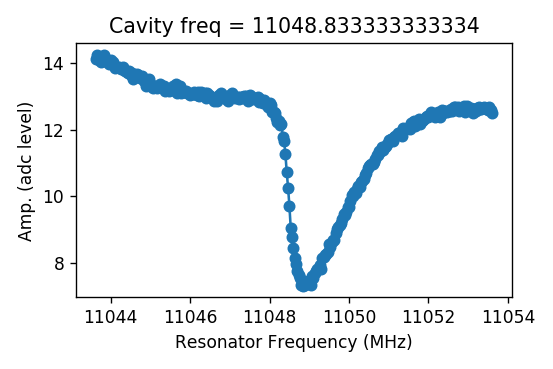

In [12]:
plt.figure(figsize=[4.5,3])
plt.subplot(111,title="Resonator Transmission", xlabel="Resonator Frequency (MHz)", ylabel="Amp. (adc level)")
plt.plot(cavity_LO/1e6-fpts, amps,'-o')

max_freq=cavity_LO/1e6-fpts[np.argmin(amps)]
plt.title("Cavity freq = " + str(max_freq))
plt.tight_layout()

x_pts = cavity_LO/1e6-fpts; y_pts = amps

# dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_halfFlux_thruCav/'
# x_pts.tofile(dataFolder + 'cavTrans_x_'+ dt_string + '.csv', sep=',', format='%10.3f')
# y_pts.tofile(dataFolder + 'cavTrans_y_'+ dt_string + '.csv', sep=',', format='%10.3f')
# plt.savefig(dataFolder + "cavTrans_"   + dt_string + '.pdf', dpi=350)

# CAVITY TRANSMISSION WITH SQUEEZING

In [13]:
class ResTransmissionSqueezing(AveragerProgram):
    def __init__(self,cfg):
        AveragerProgram.__init__(self,cfg)

    def initialize(self):
        cfg=self.cfg   
        
        r_freq=self.sreg(cfg["res_ch"], "freq")   #Get frequency register for res_ch
        freq=freq2reg(adcfreq(cfg["res_freq"]))  # convert frequency to dac frequency (ensuring it is an available adc frequency)
        f_sqz=freq2reg(cfg["f_squeezing"])
        
        cfg["adc_lengths"]=[cfg["readout_length"]]*2          #add length of adc acquisition to config
        cfg["adc_freqs"]=[adcfreq(cfg["res_freq"])]*2   #add frequency of adc ddc to config
        
        # add pulses to the pulse library
        self.add_pulse(ch=cfg["res_ch"], name="measure", style=cfg["pulse_style"], length=cfg["readout_length"])
        self.add_pulse(ch=cfg["squeezing_ch"], name="squeezing", style="flat_top", length=cfg["squeezing_length"], 
                       idata=gauss(mu=cfg["squeezing_sigma"]*16*4/2,si=cfg["squeezing_sigma"]*16,length=4*cfg["squeezing_sigma"]*16,maxv=2**15-1))               
        
        # pre-initialize pulses        
        self.pulse(ch=cfg["res_ch"], name="measure", freq=freq, phase=0, gain=cfg["res_gain"], t= 0, play=False) # pre-configure readout pulse
        self.pulse(ch=cfg["squeezing_ch"], name="squeezing", phase=cfg['squeezing_phase'],
                   freq=f_sqz, gain=cfg["squeezing_gain"], play=False)
        
        self.synci(200)  # give processor some time to configure pulses
    
    def body(self):
        cfg=self.cfg
        self.trigger_adc(adc1=1, adc2=1, adc_trig_offset=cfg["adc_trig_offset"])       # trigger the adc acquisition
        self.pulse(ch=cfg["squeezing_ch"], name="squeezing", play=True)                # play squeezing pulse
        self.pulse(ch=cfg["res_ch"], length=cfg["readout_length"], play=True)          # play readout pulse
        self.sync_all(us2cycles(cfg["relax_delay"]))                                   # sync all channels

In [148]:
adc_offset = 230
cavity_RF = 11.0472e9
cavity_LO = 12.1e9
cavity_IF = (cavity_LO-cavity_RF)/1e6
cavity_atten = 5

qubit_atten = 40
squeezing_atten = 0

qubit_LO = 3.76615e9  # Hz
qubit_IF = 700        # MHz
qubit_RF = qubit_LO/1e6 - qubit_IF # MHz

squeezing_RF = 2*qubit_RF
squeezing_LO = qubit_LO # use the same LO for phase coherence
squeezing_IF = squeezing_RF - squeezing_LO/1e6

setatten(atten=qubit_atten, serial=qubit_SN) # Qubit
setatten(atten=cavity_atten, serial=cavity_SN) # Cavity
setatten(atten=squeezing_atten, serial=squeezing_SN) # Squeezing
setsignalcore(module=cavity_LOmod,output=1,power=13,freq=cavity_LO) # Cavity. LO = 12 GHz
setsignalcore(module=qubit_LOmod,output=1,power=7,freq=qubit_LO) # Squeezing. LO = 4.5 GHz

Microsoft Windows [Version 10.0.19042.1415]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 40 27783
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device 1 Serial number: 27783
Device was found to be device 1
Get attenuation: 0.0
Set attenuation: 40.0
Device 2 Serial number: 27712
Device 3 Serial number: 0
Device 4 Serial number: 0

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>Microsoft Windows [Version 10.0.19042.1415]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 5 27782
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device was found to be de

In [168]:
hw_cfg={"res_ch":cavity_ch, "squeezing_ch":squeezing_ch,}
readout_cfg={
    "readout_length":us2cycles(4.6), # [Clock ticks]
    "f_res": cavity_IF, # [MHz]
    "res_phase": 0,
    "adc_trig_offset": adc_offset, # [Clock ticks]
    "res_gain":32000,
    "cavity_RF": cavity_RF/1e6,
    "relax_delay": 75,
    "pulse_style": "const",
    }
squeezing_cfg={
    "squeezing_length": us2cycles(4.6),
    "squeezing_sigma": 5,
    "squeezing_phase": 0,
    "squeezing_gain": 0*32000,
    "f_squeezing": squeezing_IF,
    }
atten_cfg={
    "cavity_atten": cavity_atten,
    "qubit_atten": qubit_atten,
    "squeezing_atten": squeezing_atten,
    }

expt_cfg={"center": cavity_IF, "span":6, "expts":250}
expt_cfg["step"] = 2*expt_cfg["span"]/expt_cfg["expts"]
expt_cfg["start"] = expt_cfg["center"]-expt_cfg["span"]

fpts=expt_cfg["start"] + expt_cfg["step"]*np.arange(expt_cfg["expts"])

config={"reps":500, **hw_cfg, **atten_cfg, **readout_cfg, **expt_cfg, **squeezing_cfg}
config

{'adc_trig_offset': 230,
 'cavity_RF': 11047.2,
 'cavity_atten': 5,
 'center': 1052.8,
 'expts': 250,
 'f_res': 1052.8,
 'f_squeezing': 2366.15,
 'pulse_style': 'const',
 'qubit_atten': 40,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 500,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'span': 6,
 'squeezing_atten': 0,
 'squeezing_ch': 5,
 'squeezing_gain': 0,
 'squeezing_length': 1766,
 'squeezing_phase': 0,
 'squeezing_sigma': 5,
 'start': 1046.8,
 'step': 0.048}

In [171]:
amps=[]
start = time.time()
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
for f in tqdm(fpts):
    config["res_freq"]=f
    prog = ResTransmissionSqueezing(config)
    avgi,avgq=prog.acquire(soc, load_pulses=True)
    amp1=np.abs(avgi[0][0]+1j*avgq[0][0])
    amp = amp1
    amps.append(amp)
print(f'Time: {time.time() - start}')
amps=np.array(amps)

100%|██████████| 250/250 [00:17<00:00, 14.31it/s]

Time: 17.52855610847473


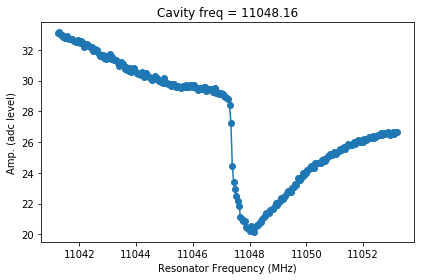

In [172]:
fig = plt.subplots(figsize=[6,4])
ax = plt.subplot(111, xlabel="Resonator Frequency (MHz)", ylabel="Amp. (adc level)")
RF_fpts = cavity_LO/1e6 - fpts
ax.plot(RF_fpts, amps,'-o')

max_freq = cavity_LO/1e6 - fpts[np.argmin(amps)]
ax.set_title("Cavity freq = " + str(max_freq))
plt.tight_layout()

x_pts = RF_fpts; y_pts = amps

# dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_halfFlux_thruCL/'
# x_pts.tofile(dataFolder + 'cavTrans_sqz_0k_x_'+ dt_string + '.csv', sep=',', format='%10.3f')
# y_pts.tofile(dataFolder + 'cavTrans_sqz_0k_y_'+ dt_string + '.csv', sep=',', format='%10.3f')
# plt.savefig(dataFolder + "cavTrans_sqz_0k_"   + dt_string + '.pdf', dpi=350)

### Loop through squeezing gain

In [173]:
hw_cfg={"res_ch":cavity_ch, "squeezing_ch":squeezing_ch,}
readout_cfg={
    "readout_length":us2cycles(4.6), # [Clock ticks]
    "f_res": cavity_IF, # [MHz]
    "res_phase": 0,
    "adc_trig_offset": adc_offset, # [Clock ticks]
    "res_gain":32000,
    "cavity_RF": cavity_RF/1e6,
    "relax_delay": 75,
    "pulse_style": "const",
    }
squeezing_cfg={
    "squeezing_length": us2cycles(4.6),
    "squeezing_sigma": 5,
    "squeezing_phase": 0,
    "squeezing_gain": 32000,
    "f_squeezing": squeezing_IF,
    }
atten_cfg={
    "cavity_atten": cavity_atten,
    "qubit_atten": qubit_atten,
    "squeezing_atten": squeezing_atten,
    }

expt_cfg={"center": cavity_IF, "span":20, "expts":1200}
expt_cfg["step"] = 2*expt_cfg["span"]/expt_cfg["expts"]
expt_cfg["start"] = expt_cfg["center"]-expt_cfg["span"]

fpts=expt_cfg["start"] + expt_cfg["step"]*np.arange(expt_cfg["expts"])
RF_fpts = cavity_LO/1e6 - fpts

config={"reps":300, **hw_cfg, **atten_cfg, **readout_cfg, **expt_cfg, **squeezing_cfg}
config

{'adc_trig_offset': 230,
 'cavity_RF': 11047.2,
 'cavity_atten': 5,
 'center': 1052.8,
 'expts': 1200,
 'f_res': 1052.8,
 'f_squeezing': 2366.15,
 'pulse_style': 'const',
 'qubit_atten': 40,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 300,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'span': 20,
 'squeezing_atten': 0,
 'squeezing_ch': 5,
 'squeezing_gain': 32000,
 'squeezing_length': 1766,
 'squeezing_phase': 0,
 'squeezing_sigma': 5,
 'start': 1032.8,
 'step': 0.03333333333333333}

In [174]:
sqz_gain_pts = np.linspace(0,32e3, 33)
results = np.zeros((len(sqz_gain_pts),len(fpts)))

now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
for jjj, sqz_gain in enumerate(sqz_gain_pts):
    config["squeezing_gain"] = np.int(sqz_gain)
    
    for iii, f in enumerate(fpts):
        config["res_freq"]=f
        prog = ResTransmissionSqueezing(config)
        avgi,avgq=prog.acquire(soc, load_pulses=True)
        amp1=np.abs(avgi[0][0]+1j*avgq[0][0])
        amp = amp1
        results[jjj][iii] = amp
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")    

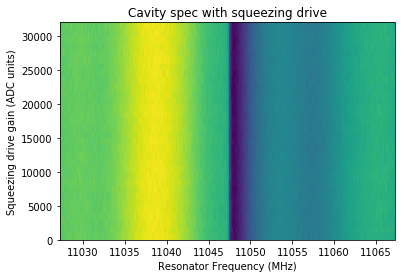

In [175]:
fig, ax = plt.subplots(figsize=(6,4))
ax.pcolormesh(RF_fpts, sqz_gain_pts, results)
ax.set_xlabel("Resonator Frequency (MHz)")
ax.set_ylabel("Squeezing drive gain (ADC units)")
ax.set_title("Cavity spec with squeezing drive")

x_pts = RF_fpts; y_pts = sqz_gain_pts; color_pts = results

# dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_halfFlux_thruCav/'
# x_pts.tofile(dataFolder + 'cavTrans_sqz_sweepGain_freq_'+ dt_string + '.csv', sep=',', format='%10.3f')
# y_pts.tofile(dataFolder + 'cavTrans_sqz_sweepGain_sqzgain_'+ dt_string + '.csv', sep=',', format='%10.3f')
# color_pts.tofile(dataFolder + 'cavTrans_sqz_sweepGain_results_'+ dt_string + '.csv', sep=',', format='%10.3f')
# plt.savefig(dataFolder + "cavTrans_sqz_sweepGain_"   + dt_string + '.pdf', dpi=350)

# PULSED SPEC

In [9]:
class PulseProbeSpectroscopyProgram(RAveragerProgram):
    def initialize(self):
        cfg=self.cfg
        
        self.q_rp=self.ch_page(self.cfg["qubit_ch"])     # get register page for qubit_ch
        self.r_freq=self.sreg(cfg["qubit_ch"], "freq")   # get frequency register for qubit_ch    
        
        f_res=freq2reg(adcfreq(cfg["f_res"]))            # conver f_res to dac register value

        self.cfg["adc_lengths"]=[self.cfg["readout_length"]]*2   #copy over adc acquisition parameters
        self.cfg["adc_freqs"]=[adcfreq(cfg["f_res"])]*2
        
        # add qubit and readout pulses to respective channels
        self.add_pulse(ch=self.cfg["qubit_ch"], name="qubit",style="const", length=self.cfg["probe_length"])
        self.add_pulse(ch=self.cfg["res_ch"], name="measure",style="const", length=self.cfg["readout_length"])
        self.f_start =freq2reg(cfg["start"])  # get start/step frequencies
        self.f_step =freq2reg(cfg["step"])
        
        # pre-initialize pulses
        #self.pulse(ch=cfg["qubit_ch"], name="qubit", phase =0, freq=self.f_start, gain=cfg["qubit_gain"], play=False)
        self.pulse(ch=cfg["qubit_ch"], name="qubit", freq=self.f_start, gain=cfg["qubit_gain"], t=0, phase=0, play=False, stdysel=0, phrst=0, mode=1, outsel=1) # pre-configure readout pulse
        self.pulse(ch=cfg["res_ch"], name="measure", freq=f_res, phase=cfg['res_phase'], gain=cfg["res_gain"], play=False)
    
        self.sync_all(us2cycles(1))
    
    def body(self):
        self.pulse(ch=self.cfg["qubit_ch"], play=True)  #play probe pulse
        self.sync_all(us2cycles(0.05)) # align channels and wait 50ns
        self.trigger_adc(adc1=1, adc2=1, adc_trig_offset=self.cfg["adc_trig_offset"])  #trigger measurement
        self.pulse(ch=self.cfg["res_ch"], play=True) # play measurement pulse
        self.sync_all(us2cycles(self.cfg["relax_delay"]))  # wait for qubit to relax
    
    def update(self):
        self.mathi(self.q_rp, self.r_freq, self.r_freq, '+', self.f_step) # update frequency list index

In [43]:
adc_offset = 230
cavity_RF = 11.0484e9 
cavity_LO = 12.1e9
cavity_IF = (cavity_LO-cavity_RF)/1e6
cavity_atten = 0

qubit_IF = 700 # MHz
qubit_LO = 3.751e9  # Hz
qubit_atten = 40
qubit_RF = qubit_LO/1e6 - qubit_IF # MHz

setatten(atten=qubit_atten, serial=qubit_SN) # Qubit
setatten(atten=cavity_atten, serial=cavity_SN) # Cavity
setatten(atten=squeezing_atten, serial=squeezing_SN) # Squeezing
setsignalcore(module=cavity_LOmod,output=1,power=13,freq=cavity_LO) # Cavity. LO = 12.1 GHz
setsignalcore(module=qubit_LOmod,output=1,power=7,freq=qubit_LO) # Qubit

Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 40 27783
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device 1 Serial number: 27783
Device was found to be device 1
Get attenuation: 0.0
Set attenuation: 40.0
Device 2 Serial number: 27712
Device 3 Serial number: 0
Device 4 Serial number: 0

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27782
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device was found to be de

In [44]:
hw_cfg={"res_ch":cavity_ch,
        "qubit_ch":qubit_ch,
       }
readout_cfg={
    "readout_length":us2cycles(4.6), # [Clock ticks]
    "f_res": cavity_IF, # [MHz]
    "res_phase": 0,
    "adc_trig_offset": adc_offset, # [Clock ticks]
    "res_gain":32000,
    "cavity_RF": cavity_RF/1e6,
    }
qubit_cfg={
    "relax_delay":75,
    "qubit_RF": qubit_RF,
    "f_ge": qubit_IF, # [MHz]
    "qubit_start": qubit_RF-10,
    "qubit_stop": qubit_RF+10,
    "qubit_gain": 20000,}

atten_cfg={
    "cavity_atten": cavity_atten,
    "qubit_atten": qubit_atten,
    "squeezing_atten": squeezing_atten,
    "squeezing_RF": squeezing_RF,
    }
expt_cfg={"reps": 7000,"rounds":1,"probe_length":us2cycles(40)}
expt_cfg["center"]= qubit_IF; expt_cfg["span"] = 15; expt_cfg["expts"]= 301;
expt_cfg["step"] = 2*expt_cfg["span"] / (expt_cfg["expts"]-1)
expt_cfg["start"] = expt_cfg["center"]-expt_cfg["span"]
fpts=expt_cfg["start"] + expt_cfg["step"]*np.arange(expt_cfg["expts"])
qubit_cfg["qubit_start"] = qubit_LO/1e6-fpts[-1:][0] 
qubit_cfg["qubit_stop"] = qubit_LO/1e6-fpts[:1][0]

print(qubit_cfg["qubit_start"], qubit_cfg["qubit_stop"])

config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg,**atten_cfg} #combine configs
config

3036.0 3066.0


{'adc_trig_offset': 230,
 'cavity_RF': 11048.4,
 'cavity_atten': 0,
 'center': 700,
 'expts': 301,
 'f_ge': 700,
 'f_res': 1051.6,
 'probe_length': 15360,
 'qubit_RF': 3051.0,
 'qubit_atten': 40,
 'qubit_ch': 6,
 'qubit_gain': 20000,
 'qubit_start': 3036.0,
 'qubit_stop': 3066.0,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 7000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'rounds': 1,
 'span': 15,
 'squeezing_RF': 0,
 'squeezing_atten': 40,
 'start': 685,
 'step': 0.1}

In [45]:
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
qspec=PulseProbeSpectroscopyProgram(cfg=config)
expt_pts, avgi, avgq = qspec.acquire(soc, load_pulses=True,progress=True, debug=False)

<IPython.core.display.Javascript object>


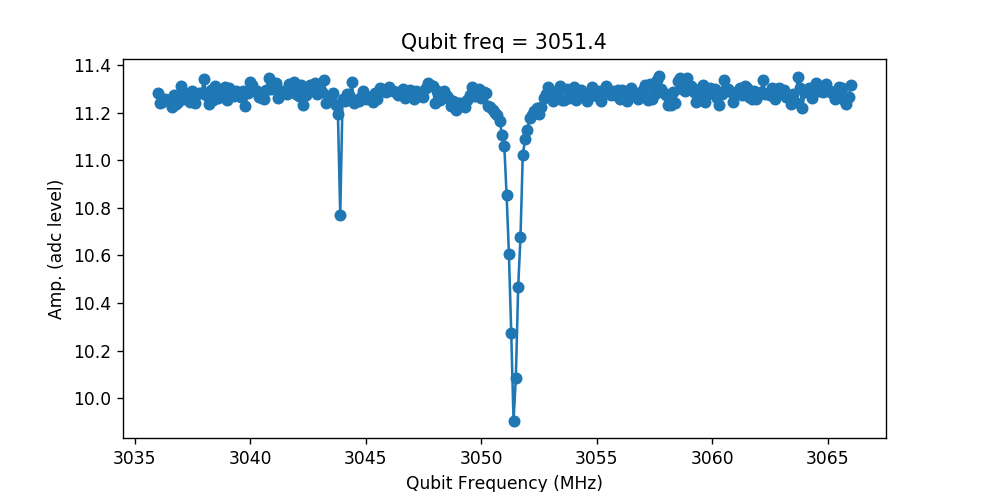

In [46]:
plt.figure(figsize=(8,4))
plt.subplot(111,title="Qubit Spectroscopy", xlabel="Qubit Frequency (MHz)", ylabel="Amp. (adc level)")
amp=np.abs(avgi[0][0]+1j*avgq[0][0])
max_freq=qubit_LO/1e6-expt_pts[np.argmin(amp)]
plt.title("Qubit freq = " + str(max_freq))
plt.plot(qubit_LO/1e6 - expt_pts, amp, '-o')
plt.show()

x_pts = qubit_LO/1e6 - expt_pts; y_pts = amp;

# dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_quarterFlux_thruCav/'
# x_pts.tofile(dataFolder + 'qubitSpec_x_'+ dt_string + '.csv', sep=',', format='%10.3f')
# y_pts.tofile(dataFolder + 'qubitSpec_y_'+ dt_string + '.csv', sep=',', format='%10.3f')
# plt.savefig(dataFolder + "qubitSpec_"   + dt_string + '.pdf', dpi=350)

# AMPLITUDE RABI

In [10]:
class AmplitudeRabiProgram(RAveragerProgram):

    def initialize(self):
        cfg=self.cfg
        
        self.q_rp=self.ch_page(self.cfg["qubit_ch"])     # get register page for qubit_ch
        self.r_gain=self.sreg(cfg["qubit_ch"], "gain")   # get gain register for qubit_ch    
        
        f_res=freq2reg(adcfreq(cfg["f_res"]))            # conver f_res to dac register value
        f_ge=freq2reg(cfg["f_ge"])
        
        self.cfg["adc_lengths"]=[self.cfg["readout_length"]]*2   #copy over adc acquisition parameters
        self.cfg["adc_freqs"]=[adcfreq(cfg["f_res"])]*2
        
        # add qubit and readout pulses to respective channels
        self.add_pulse(ch=self.cfg["qubit_ch"], name="qubit", style="arb", 
                       idata=gauss(mu=cfg["sigma"]*16*4/2,si=cfg["sigma"]*16,length=4*cfg["sigma"]*16,maxv=2**15-1), 
                       qdata=0*gauss(mu=cfg["sigma"]*16*4/2,si=cfg["sigma"]*16,length=4*cfg["sigma"]*16,maxv=2**15-1))
        self.add_pulse(ch=self.cfg["res_ch"], name="measure", style="const", length=self.cfg["readout_length"])
        
        # pre-initialize pulses
        self.pulse(ch=cfg["qubit_ch"], name="qubit", phase =0, freq=f_ge, gain=cfg["start"], play=False)
        self.pulse(ch=cfg["res_ch"], name="measure", freq=f_res, phase=cfg["res_phase"], gain=cfg["res_gain"], play=False)
    
        self.sync_all(us2cycles(500))
    
    def body(self):
        
        self.pulse(ch=self.cfg["qubit_ch"], play=True, phase=deg2reg(90))  #play probe pulse
        self.sync_all(us2cycles(0.05)) # align channels and wait 50ns
        self.trigger_adc(adc1=1, adc2=1, adc_trig_offset=self.cfg["adc_trig_offset"])  #trigger measurement
        self.pulse(ch=self.cfg["res_ch"], name="measure", play=True) # play measurement pulse

        self.sync_all(us2cycles(self.cfg["relax_delay"]))  # wait for qubit to relax
    
    def update(self):
        self.mathi(self.q_rp, self.r_gain, self.r_gain, '+', self.cfg["step"]) # update gain of the Gaussian pi pulse

In [35]:
adc_offset = 230
cavity_RF = 11.0484e9
cavity_LO = 12.1e9
cavity_IF = (cavity_LO-cavity_RF)/1e6
cavity_atten = 0

qubit_IF = 700       # MHz
qubit_LO = 3.7512e9 # Hz
qubit_atten = 0
qubit_RF = qubit_LO/1e6 - qubit_IF # MHz

squeezing_atten = 40

setatten(atten=qubit_atten, serial=qubit_SN) # Qubit
setatten(atten=cavity_atten, serial=cavity_SN) # Cavity
setatten(atten=squeezing_atten, serial=squeezing_SN) # Squeezing
setsignalcore(module=cavity_LOmod,output=1,power=13,freq=cavity_LO) # Cavity. LO = 12.1 GHz
setsignalcore(module=qubit_LOmod,output=1,power=7,freq=qubit_LO) # Qubit

Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27783
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device 1 Serial number: 27783
Device was found to be device 1
Get attenuation: 40.0
Set attenuation: 0.0
Device 2 Serial number: 27712
Device 3 Serial number: 0
Device 4 Serial number: 0

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27782
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device was found to be dev

In [36]:
hw_cfg={"res_ch":cavity_ch,
        "qubit_ch":qubit_ch,
       }
readout_cfg={
    "readout_length":us2cycles(1), # [Clock ticks]
    "f_res": cavity_IF, # [MHz]
    "res_phase": 0,
    "adc_trig_offset": adc_offset, # [Clock ticks]
    "res_gain":32000,
    "cavity_RF": cavity_RF/1e6,
    }
qubit_cfg={
    "relax_delay":75,
    "qubit_RF": qubit_RF,
    "f_ge": qubit_IF, # [MHz]
    "sigma":us2cycles(0.18),
    }
atten_cfg={
    "cavity_atten": cavity_atten,
    "qubit_atten": qubit_atten,
    "squeezing_atten": squeezing_atten,
    "squeezing_RF": squeezing_RF,
    }
expt_cfg={
        "start":0, "step":100, "expts":120, "reps": 2000
       }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg,**atten_cfg} #combine configs
config

{'adc_trig_offset': 230,
 'cavity_RF': 11048.4,
 'cavity_atten': 0,
 'expts': 120,
 'f_ge': 700,
 'f_res': 1051.6,
 'qubit_RF': 3051.2,
 'qubit_atten': 0,
 'qubit_ch': 6,
 'readout_length': 384,
 'relax_delay': 75,
 'reps': 2000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'sigma': 69,
 'squeezing_RF': 0,
 'squeezing_atten': 40,
 'start': 0,
 'step': 100}

In [37]:
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
rabi=AmplitudeRabiProgram(cfg=config)
x_pts, avgi, avgq  = rabi.acquire(soc,threshold=None, load_pulses=True,progress=True, debug=False)

pi_gain = 2537


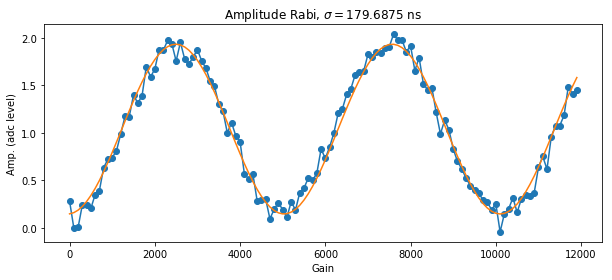

In [38]:
fig, ax = plt.subplots(figsize=[10,4])
ax.set_title(f"Amplitude Rabi, $\sigma={cycles2us(config['sigma'])*1000}$ ns"); ax.set_xlabel("Gain"); ax.set_ylabel("Amp. (adc level)")
y_pts = 1-avgi[0][0]-(1-avgi[0][0][1])
ax.plot(x_pts,y_pts,'o-')

def sinRabi(x, a, T, phi, c):
    return a*np.cos(2*np.pi/T*x + phi) + c

guess = (2, 5e3, 0, 0)
popt,pcov = curve_fit(sinRabi, x_pts, y_pts, p0=guess)
ax.plot(x_pts, sinRabi(x_pts, *popt))
pi_gain = popt[1]/2
print("pi_gain = %.0f" % pi_gain)

# dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_halfFlux_thruCav/'
# x_pts.tofile(dataFolder + 'ampRabi_x_'+ dt_string + '.csv', sep=',', format='%10.3f')
# y_pts.tofile(dataFolder + 'ampRabi_y_'+ dt_string + '.csv', sep=',', format='%10.3f')
# plt.savefig(dataFolder + "ampRabi_"   + dt_string + '.pdf', dpi=350)

# SINGLE SHOT READOUT

In [31]:
threshold = 0
class SingleShotProgram(RAveragerProgram):
    def __init__(self,cfg):
        AveragerProgram.__init__(self,cfg)       
        
    def initialize(self):
        cfg=self.cfg
        
        cfg["start"]=0
        cfg["step"]=cfg["pi_gain"]
        cfg["reps"]=cfg["shots"]
        cfg["expts"]=2
        
        self.q_rp=self.ch_page(self.cfg["qubit_ch"])     # get register page for qubit_ch
        self.r_gain=self.sreg(cfg["qubit_ch"], "gain")   # get frequency register for qubit_ch    
        
        f_res=freq2reg(adcfreq(cfg["f_res"]))            # conver f_res to dac register value
        f_ge=freq2reg(cfg["f_ge"])
        
        self.cfg["adc_lengths"]=[self.cfg["readout_length"]]*2   #copy over adc acquisition parameters
        self.cfg["adc_freqs"]=[adcfreq(cfg["f_res"])]*2
        
        # add qubit and readout pulses to respective channels
        self.add_pulse(ch=self.cfg["qubit_ch"], name="qubit",style="arb", 
                       idata=gauss(mu=cfg["sigma"]*16*4/2,si=cfg["sigma"]*16,length=4*cfg["sigma"]*16,maxv=2**15-1),
                       qdata=0*gauss(mu=cfg["sigma"]*16*4/2,si=cfg["sigma"]*16,length=4*cfg["sigma"]*16,maxv=2**15-1))
        self.add_pulse(ch=self.cfg["res_ch"], name="measure",style="const", length=self.cfg["readout_length"])
               
        # pre-initialize pulses
        self.pulse(ch=cfg["qubit_ch"], name="qubit", phase =0, freq=f_ge, gain=cfg["start"], play=False)
        self.pulse(ch=cfg["res_ch"], name="measure", freq=f_res, phase=cfg["res_phase"], gain=cfg["res_gain"], play=False)
    
        self.sync_all(us2cycles(500))
    
    def body(self):
        
        self.pulse(ch=self.cfg["qubit_ch"], play=True)  #play probe pulse
        self.sync_all(us2cycles(0.05)) # align channels and wait 50ns
        self.trigger_adc(adc1=1, adc2=1, adc_trig_offset=self.cfg["adc_trig_offset"])  #trigger measurement
        self.pulse(ch=self.cfg["res_ch"], name="measure", play=True) # play measurement pulse

        self.sync_all(us2cycles(self.cfg["relax_delay"]))  # wait for qubit to relax
    
    def update(self):
        self.mathi(self.q_rp, self.r_gain, self.r_gain, '+', self.cfg["step"]) # update frequency list index
        
    def acquire(self,soc, load_pulses=True, progress=False, debug=False):
        super().acquire(soc, load_pulses=load_pulses, progress=progress, debug=debug)
        return self.collect_shots()
        
    def collect_shots(self):
        shots_i0=self.di_buf[0].reshape((self.cfg["expts"],self.cfg["reps"]))/self.cfg['readout_length']
        shots_q0=self.dq_buf[0].reshape((self.cfg["expts"],self.cfg["reps"]))/self.cfg['readout_length']
        shots_i1=self.di_buf[1].reshape((self.cfg["expts"],self.cfg["reps"]))/self.cfg['readout_length']
        shots_q1=self.dq_buf[1].reshape((self.cfg["expts"],self.cfg["reps"]))/self.cfg['readout_length']
        return shots_i0,shots_q0,shots_i1,shots_q1
        
    def analyze(self, shots_i, shots_q):
        plt.subplot(111, xlabel='I', ylabel='Q', title='Single Shot Histogram')
        plt.plot(shots_i[0],shots_q[0],'.',label='g')
        plt.plot(shots_i[1],shots_q[1],'.',label='e')
        plt.legend()
        plt.gca().set_aspect('equal', 'datalim')

In [58]:
adc_offset = 230
cavity_RF = 11.0484e9
cavity_LO = 12.1e9
cavity_IF = (cavity_LO-cavity_RF)/1e6
cavity_atten = 0

qubit_IF = 700      # MHz
qubit_LO = 3.7512e9 # Hz
qubit_atten = 0
qubit_RF = qubit_LO/1e6 - qubit_IF # MHz

setatten(atten=qubit_atten, serial=qubit_SN) # Qubit
setatten(atten=cavity_atten, serial=cavity_SN) # Cavity
setatten(atten=squeezing_atten, serial=squeezing_SN) # Squeezing
setsignalcore(module=cavity_LOmod,output=1,power=13,freq=cavity_LO) # Cavity. LO = 12.1 GHz
setsignalcore(module=qubit_LOmod,output=1,power=7,freq=qubit_LO) # Qubit

Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27783
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device 1 Serial number: 27783
Device was found to be device 1
Get attenuation: 0.0
Set attenuation: 0.0
Device 2 Serial number: 27712
Device 3 Serial number: 0
Device 4 Serial number: 0

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27782
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device was found to be devi

In [59]:
hw_cfg={"res_ch":cavity_ch,
        "qubit_ch":qubit_ch,
       }
readout_cfg={
    "readout_length":us2cycles(4.6), # [Clock ticks]
    "f_res": cavity_IF, # [MHz]
    "res_phase": 0,
    "adc_trig_offset": adc_offset, # [Clock ticks]
    "res_gain":32000,
    "cavity_RF": cavity_RF/1e6,
    "threshold": np.int(threshold)
    }
qubit_cfg={
    "relax_delay":75,
    "qubit_RF": qubit_RF,
    "f_ge": qubit_IF, # [MHz]
    "sigma":us2cycles(0.180),
    "pi_gain":np.int(pi_gain),
    }

atten_cfg={
    "cavity_atten": cavity_atten,
    "qubit_atten": qubit_atten,
    "squeezing_atten": squeezing_atten,
    "squeezing_RF": squeezing_RF,
    }
expt_cfg={
        "shots":10000, "res_phase":0
       }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg,**atten_cfg} #combine configs
config

{'adc_trig_offset': 230,
 'cavity_RF': 11048.4,
 'cavity_atten': 0,
 'f_ge': 700,
 'f_res': 1051.6,
 'pi_gain': 2502,
 'qubit_RF': 3051.2,
 'qubit_atten': 0,
 'qubit_ch': 6,
 'readout_length': 1766,
 'relax_delay': 75,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'shots': 10000,
 'sigma': 69,
 'squeezing_RF': 0,
 'squeezing_atten': 40,
 'threshold': -9}

In [60]:
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
ssp=SingleShotProgram(cfg=config)
di0, dq0, di1, dq1 = ssp.acquire(soc, load_pulses=True,progress=True, debug=False)

<IPython.core.display.Javascript object>


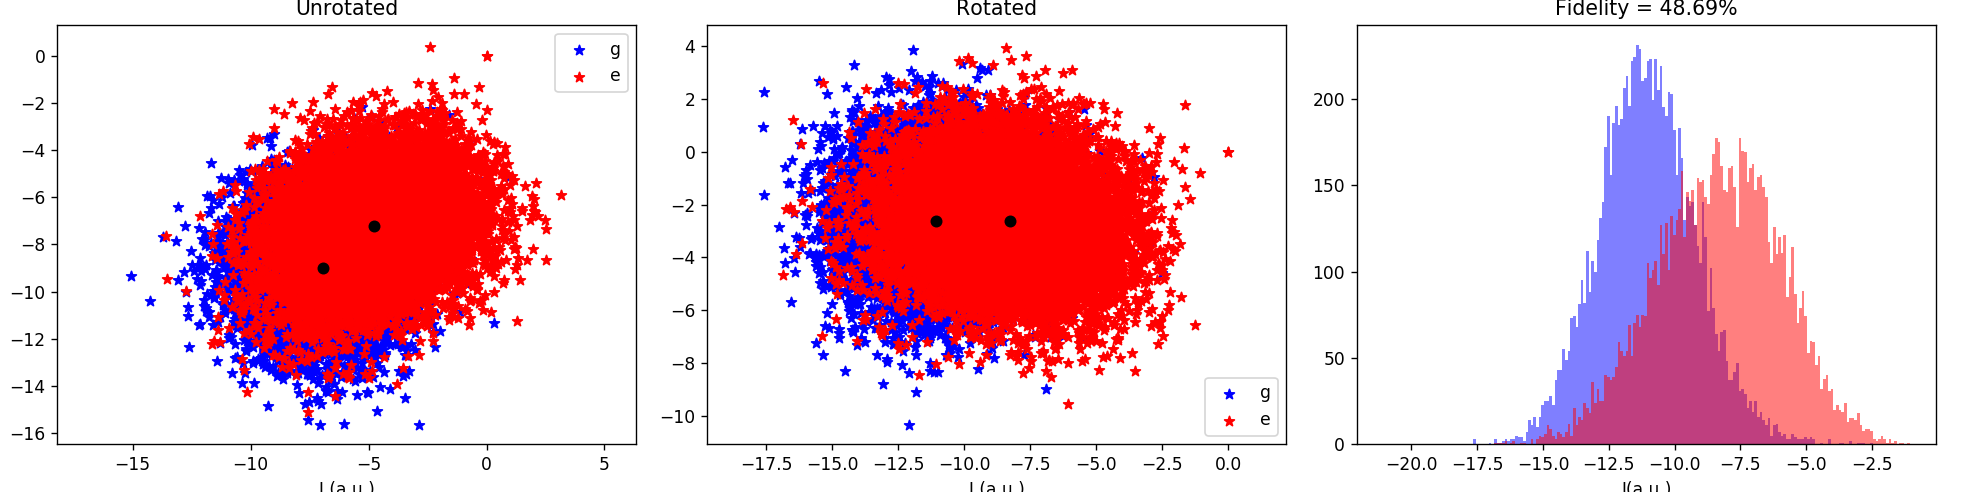

-9.66174500952169
-9


In [61]:
fid, threshold, angle, ig_new, ie_new, x_pts = hist(data=[di0[0], dq0[0], di0[1], dq0[1]],  plot=True, ran=10)
readout_cfg["res_phase"]=deg2reg(-angle*180/np.pi)
readout_cfg["threshold"]=np.int(threshold)
print(threshold)
print(np.int(threshold))

x_pts = np.array(x_pts); ig_new = np.array(ig_new); ie_new = np.array(ie_new)
# dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_halfFlux_thruCav/'
# x_pts.tofile(dataFolder + 'blobRabi_xData_'+ dt_string + '.csv', sep=',', format='%10.3f')
# ig_new.tofile(dataFolder + 'blobRabi_y_g_'+ dt_string + '.csv', sep=',', format='%10.3f')
# ie_new.tofile(dataFolder + 'blobRabi_y_e_'+ dt_string + '.csv', sep=',', format='%10.3f')
# plt.savefig(dataFolder + "blobRabi_"   + dt_string + '.pdf', dpi=350)

### Loop over cavity frequency and readout power

Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27783
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device 1 Serial number: 27783
Device was found to be device 1
Get attenuation: 0.0
Set attenuation: 0.0
Device 2 Serial number: 27712
Device 3 Serial number: 0
Device 4 Serial number: 0

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_signalcore.py 34 1 7 3751300000.0
There are 6 SC5510A devices found. Accessing device with label 34

 Getting par

<IPython.core.display.Javascript object>


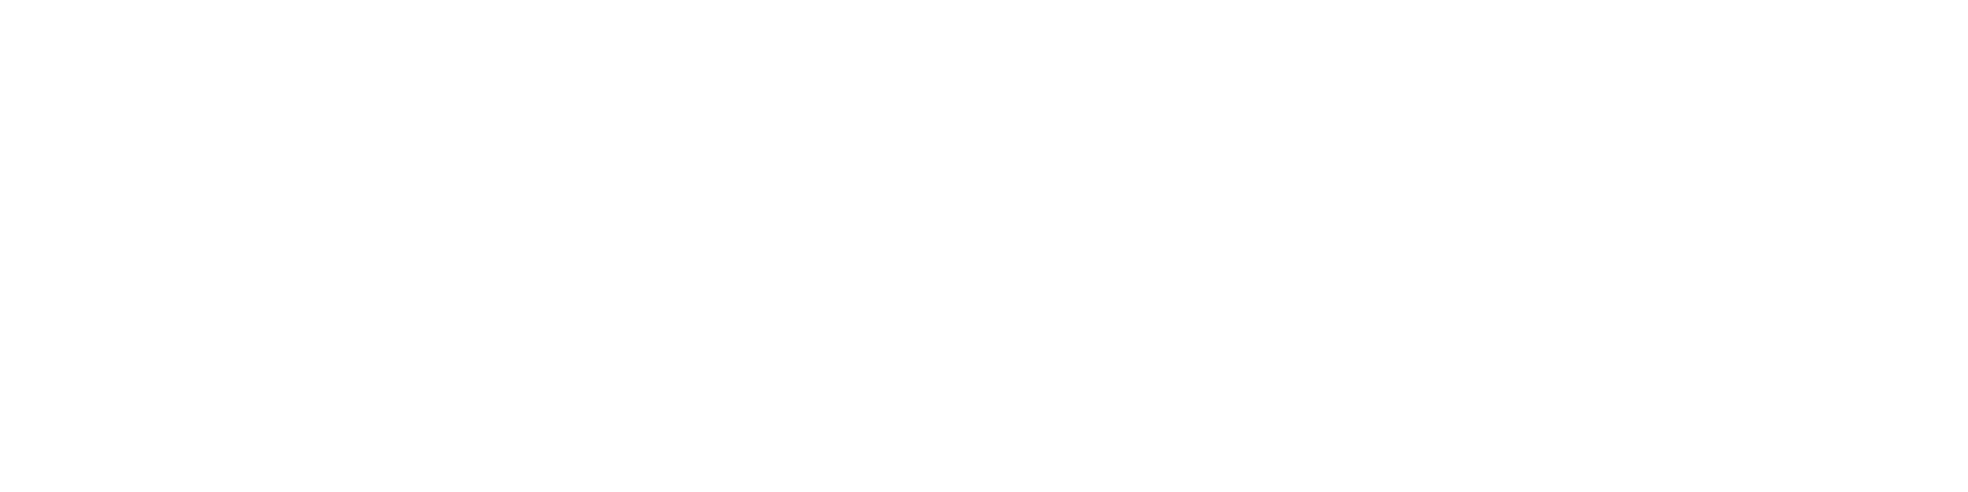

Cavity freq = 11048.20 MHz
Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_signalcore.py 33 1 13 12100000000.0
There are 6 SC5510A devices found. Accessing device with label 33

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
output          :	True 
power           :	13 (dbm)
rf_mode         :	single_tone 
serialnum       :	268447027 
temperature     :	40.469 (celsius)

 Setting parameters...

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
out

<IPython.core.display.Javascript object>


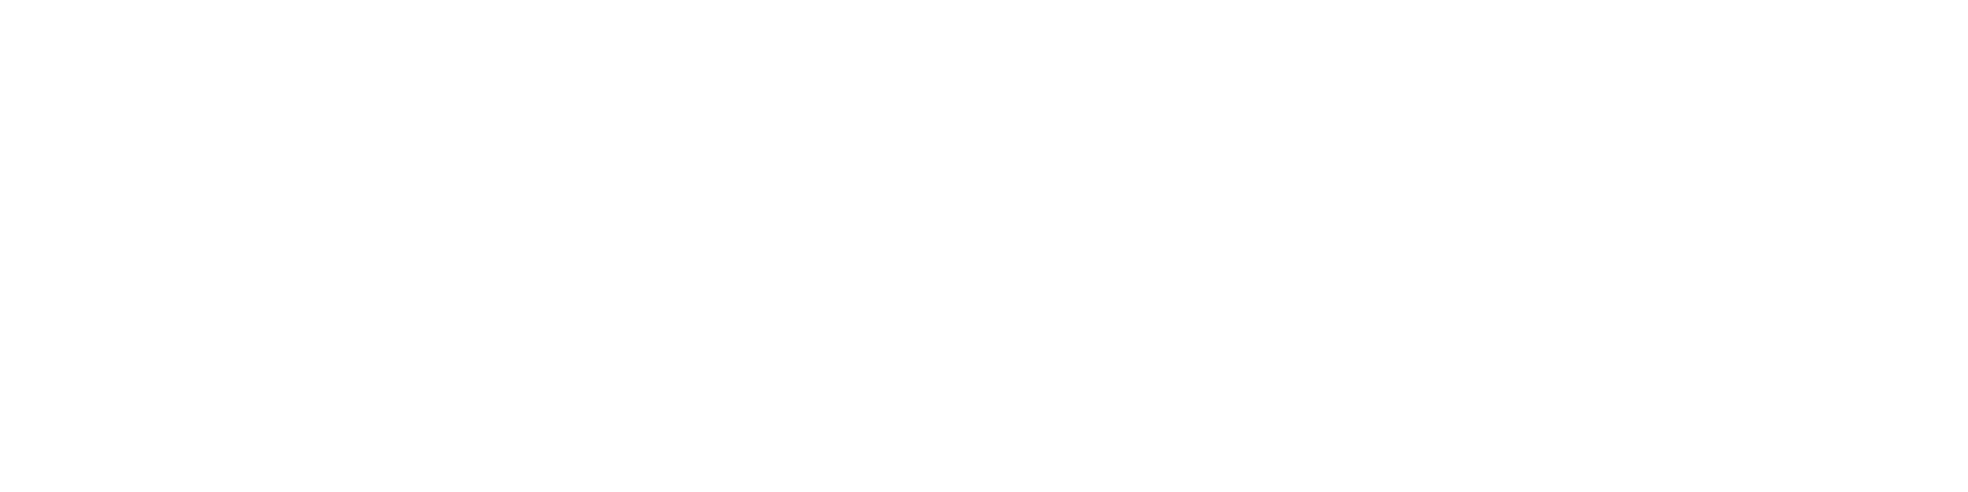

Cavity freq = 11048.40 MHz
Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_signalcore.py 33 1 13 12100000000.0
There are 6 SC5510A devices found. Accessing device with label 33

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
output          :	True 
power           :	13 (dbm)
rf_mode         :	single_tone 
serialnum       :	268447027 
temperature     :	40.438 (celsius)

 Setting parameters...

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
out

<IPython.core.display.Javascript object>


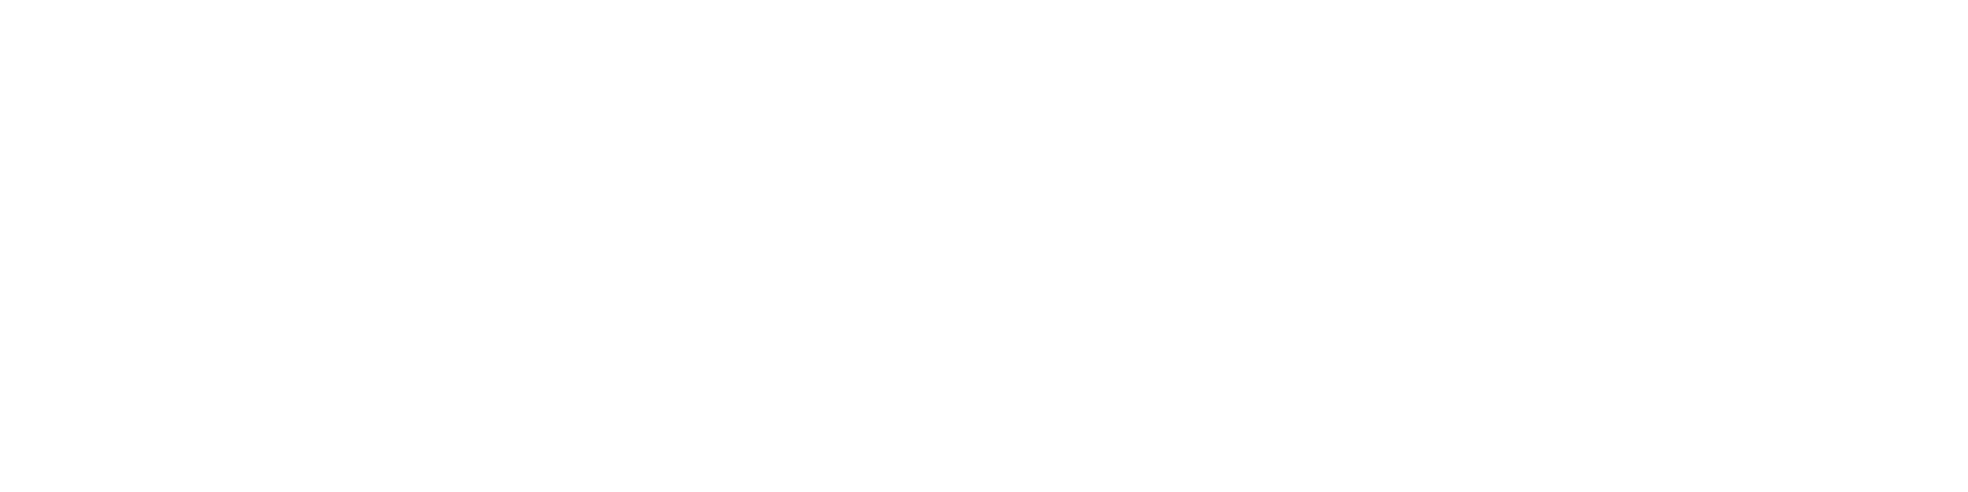

Cavity freq = 11048.60 MHz
Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_signalcore.py 33 1 13 12100000000.0
There are 6 SC5510A devices found. Accessing device with label 33

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
output          :	True 
power           :	13 (dbm)
rf_mode         :	single_tone 
serialnum       :	268447027 
temperature     :	40.438 (celsius)

 Setting parameters...

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
out

<IPython.core.display.Javascript object>


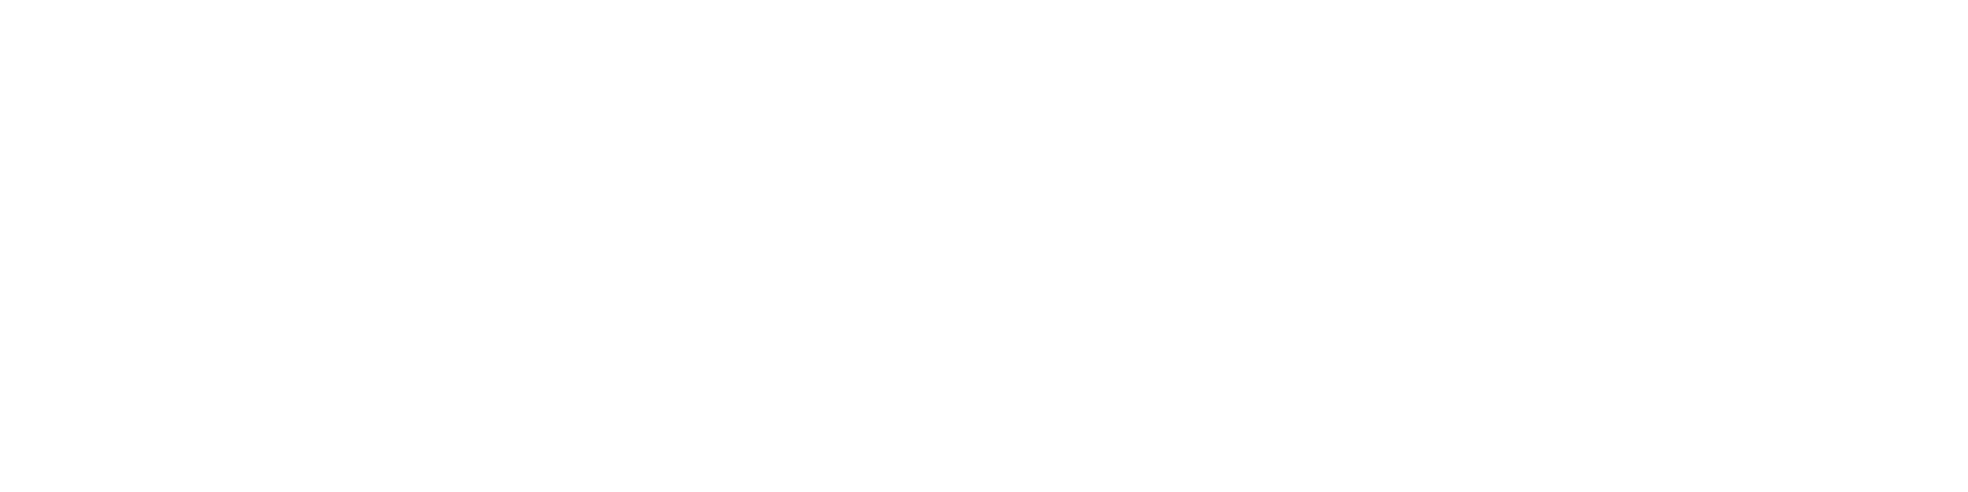

Cavity freq = 11048.80 MHz
Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_signalcore.py 33 1 13 12100000000.0
There are 6 SC5510A devices found. Accessing device with label 33

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
output          :	True 
power           :	13 (dbm)
rf_mode         :	single_tone 
serialnum       :	268447027 
temperature     :	40.438 (celsius)

 Setting parameters...

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
out

<IPython.core.display.Javascript object>


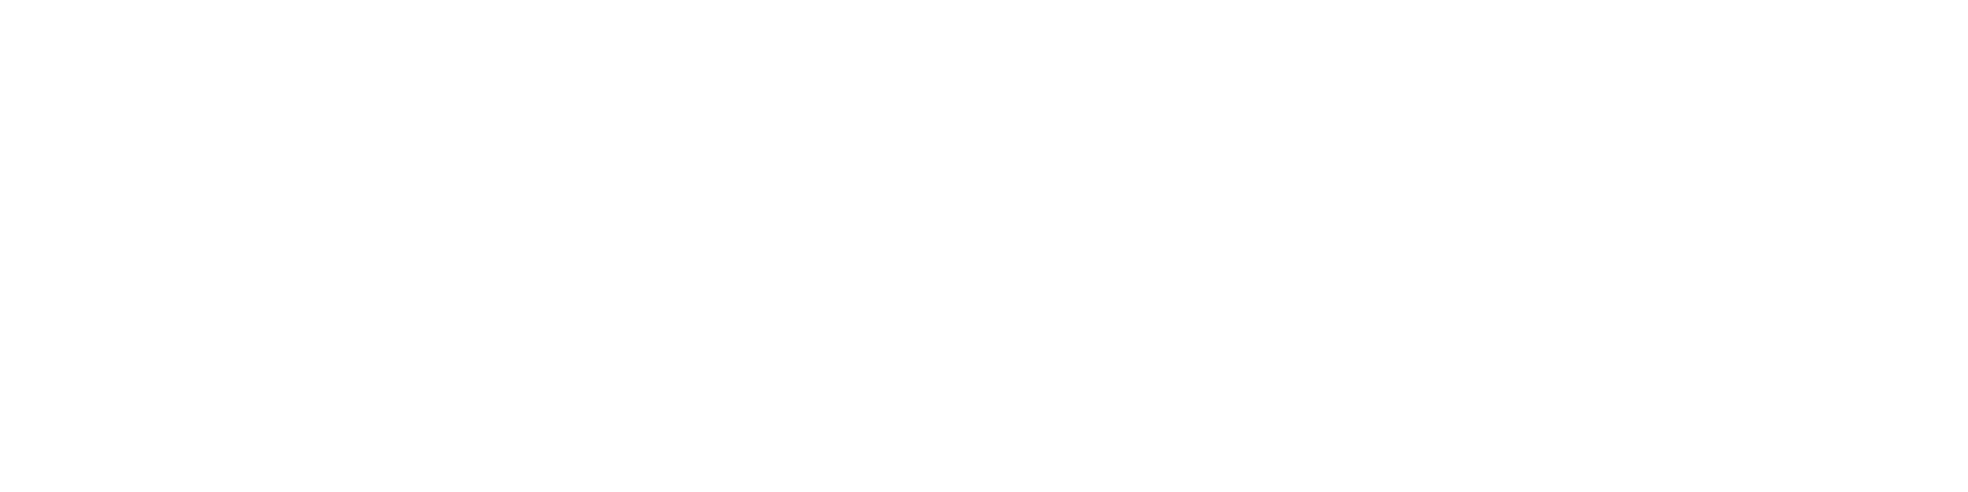

Cavity freq = 11049.00 MHz
Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_signalcore.py 33 1 13 12100000000.0
There are 6 SC5510A devices found. Accessing device with label 33

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
output          :	True 
power           :	13 (dbm)
rf_mode         :	single_tone 
serialnum       :	268447027 
temperature     :	40.5 (celsius)

 Setting parameters...

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
outpu

<IPython.core.display.Javascript object>


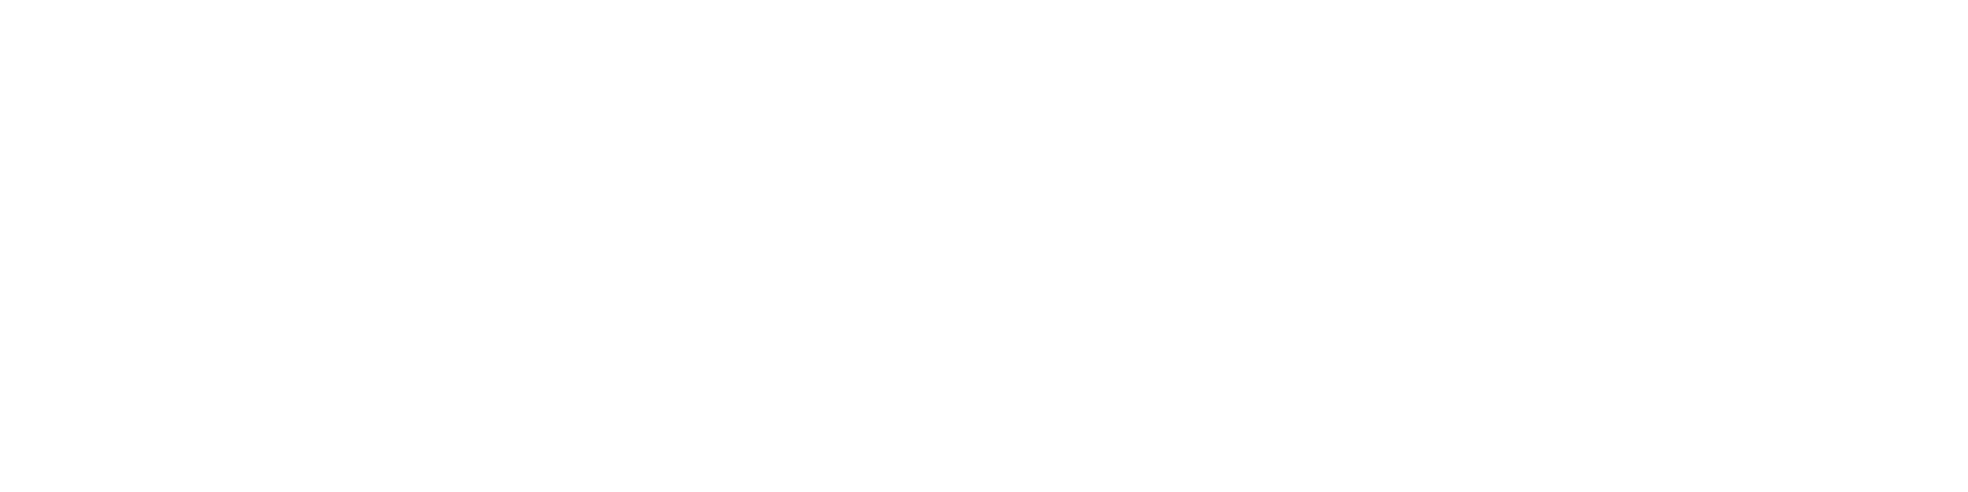

Cavity freq = 11049.20 MHz
Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_signalcore.py 33 1 13 12100000000.0
There are 6 SC5510A devices found. Accessing device with label 33

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
output          :	True 
power           :	13 (dbm)
rf_mode         :	single_tone 
serialnum       :	268447027 
temperature     :	40.406 (celsius)

 Setting parameters...

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
out

<IPython.core.display.Javascript object>


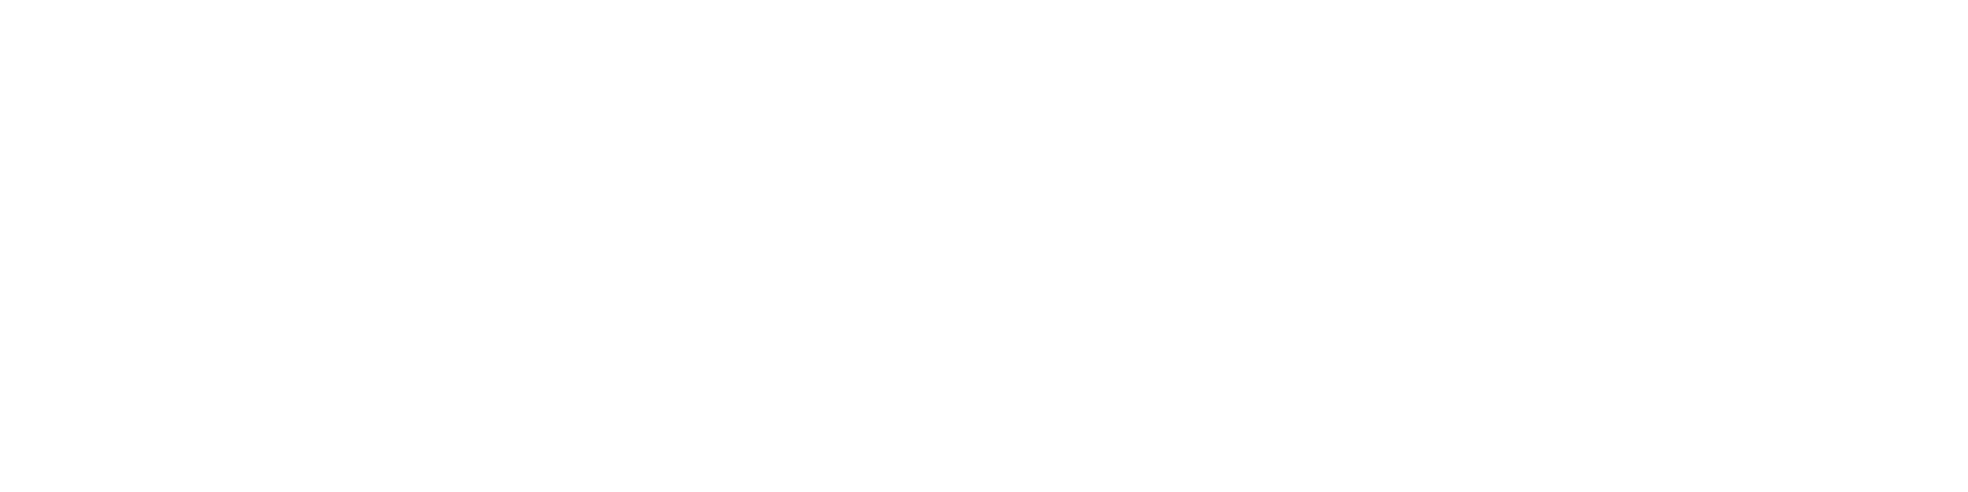

Cavity freq = 11049.40 MHz
Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_signalcore.py 33 1 13 12100000000.0
There are 6 SC5510A devices found. Accessing device with label 33

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
output          :	True 
power           :	13 (dbm)
rf_mode         :	single_tone 
serialnum       :	268447027 
temperature     :	40.469 (celsius)

 Setting parameters...

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
out

<IPython.core.display.Javascript object>


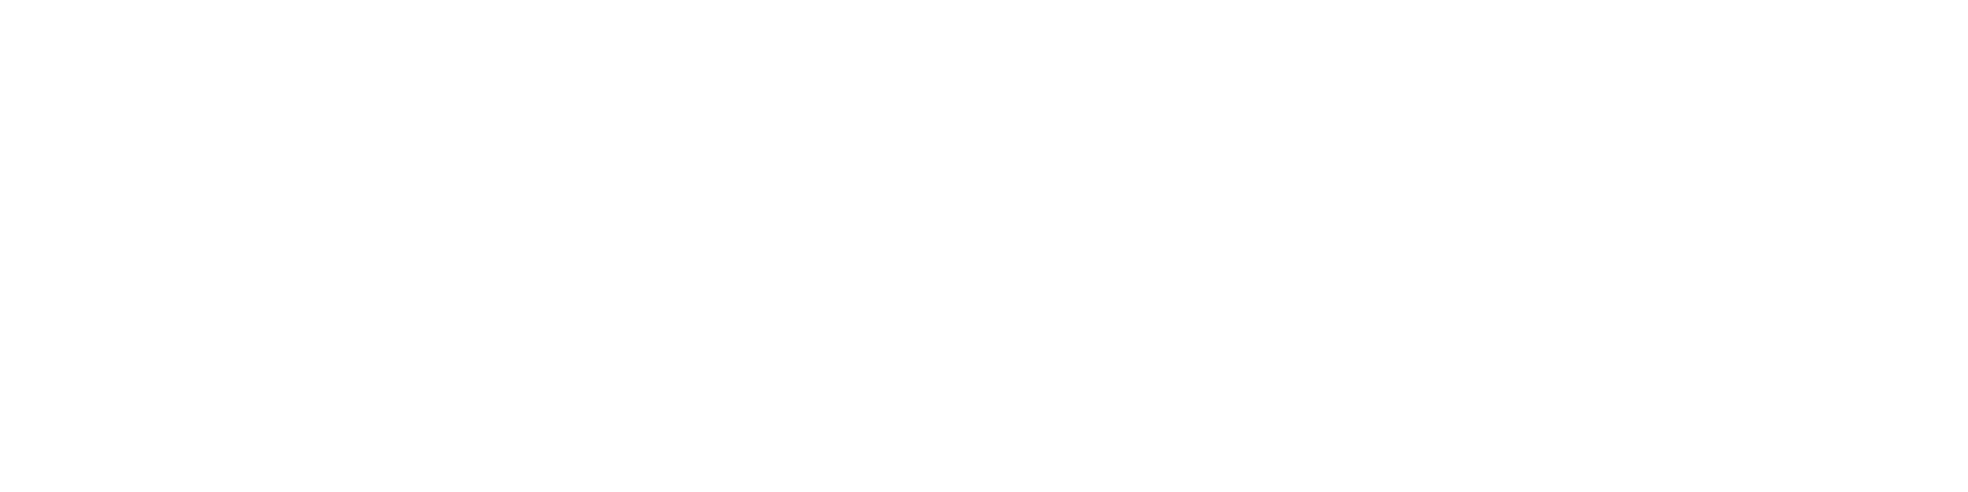

Cavity freq = 11049.60 MHz
Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_signalcore.py 33 1 13 12100000000.0
There are 6 SC5510A devices found. Accessing device with label 33

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
output          :	True 
power           :	13 (dbm)
rf_mode         :	single_tone 
serialnum       :	268447027 
temperature     :	40.5 (celsius)

 Setting parameters...

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
outpu

<IPython.core.display.Javascript object>


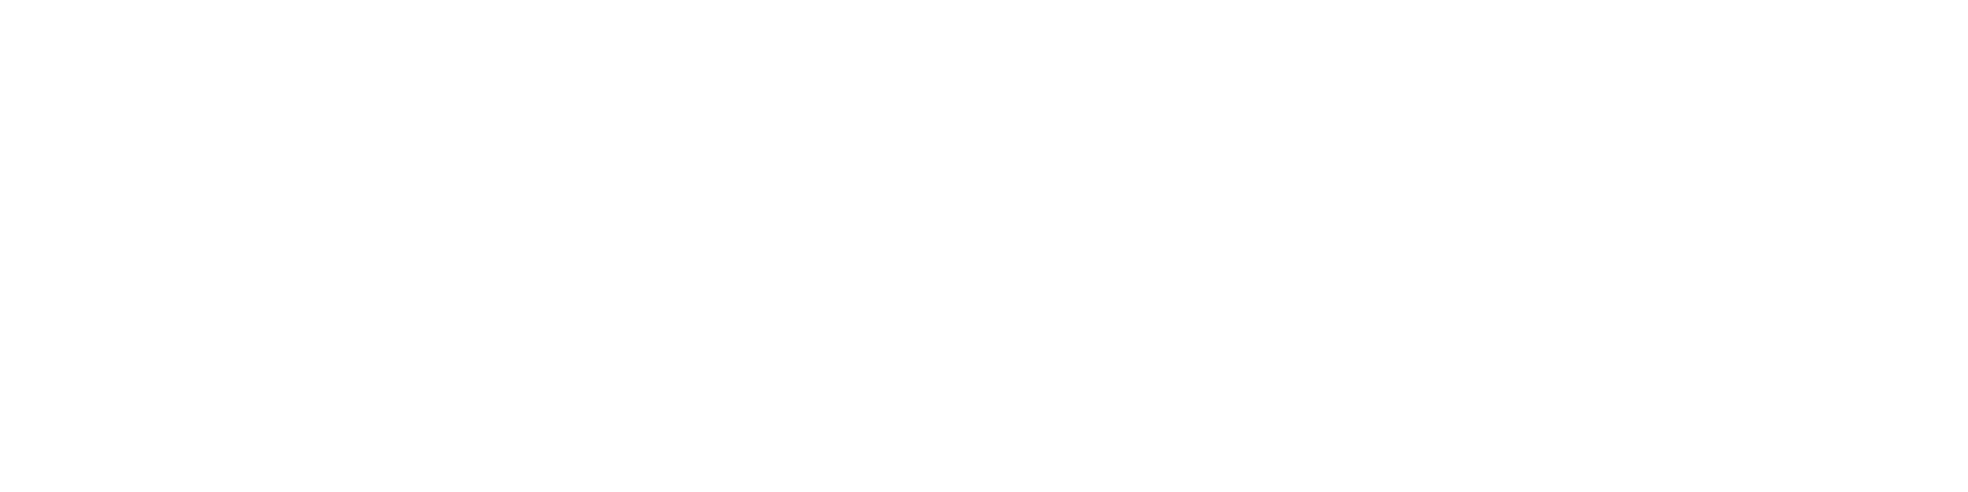

Cavity freq = 11049.80 MHz
Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_signalcore.py 33 1 13 12100000000.0
There are 6 SC5510A devices found. Accessing device with label 33

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
output          :	True 
power           :	13 (dbm)
rf_mode         :	single_tone 
serialnum       :	268447027 
temperature     :	40.562 (celsius)

 Setting parameters...

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
out

<IPython.core.display.Javascript object>


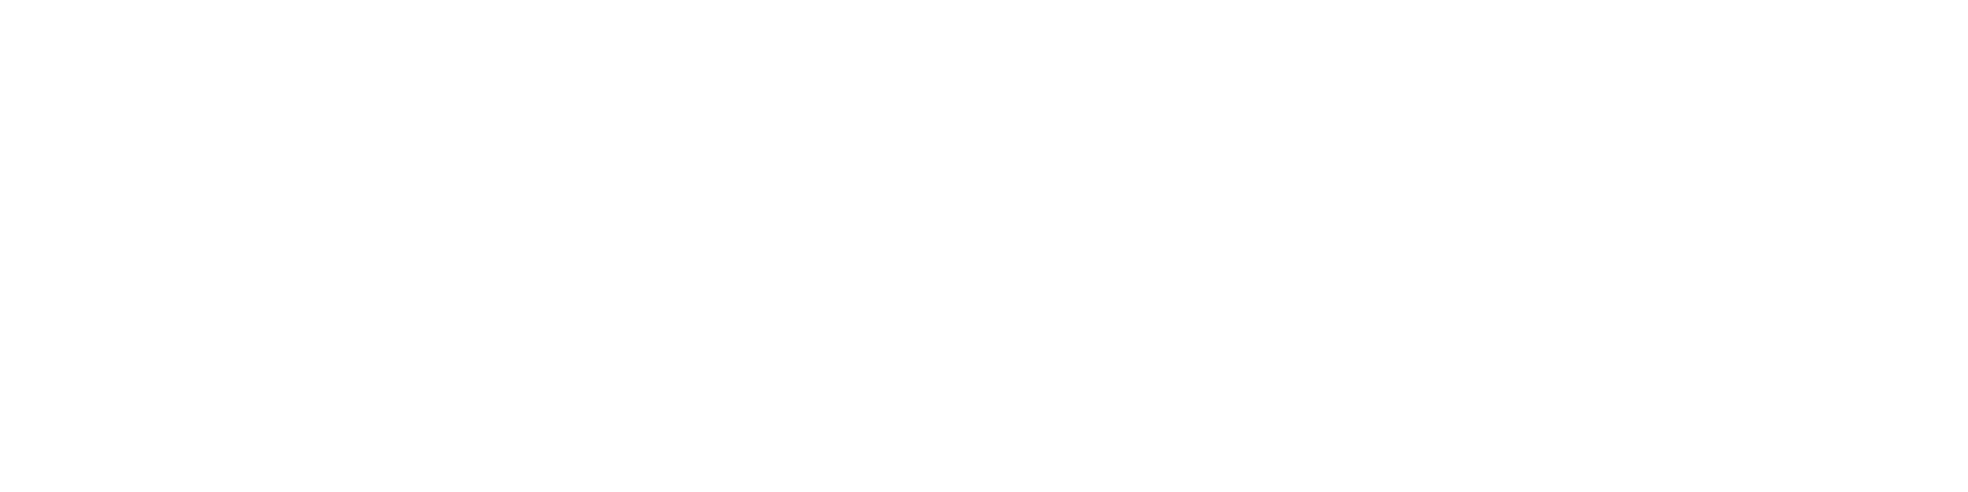

Cavity freq = 11050.00 MHz
Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_signalcore.py 33 1 13 12100000000.0
There are 6 SC5510A devices found. Accessing device with label 33

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
output          :	True 
power           :	13 (dbm)
rf_mode         :	single_tone 
serialnum       :	268447027 
temperature     :	40.469 (celsius)

 Setting parameters...

 Getting parameters...
33:
	parameter      value
--------------------------------------------------------------------------------
IDN             :	None 
clock_reference :	internal 
frequency       :	1.21e+10 (Hz)
out

<IPython.core.display.Javascript object>


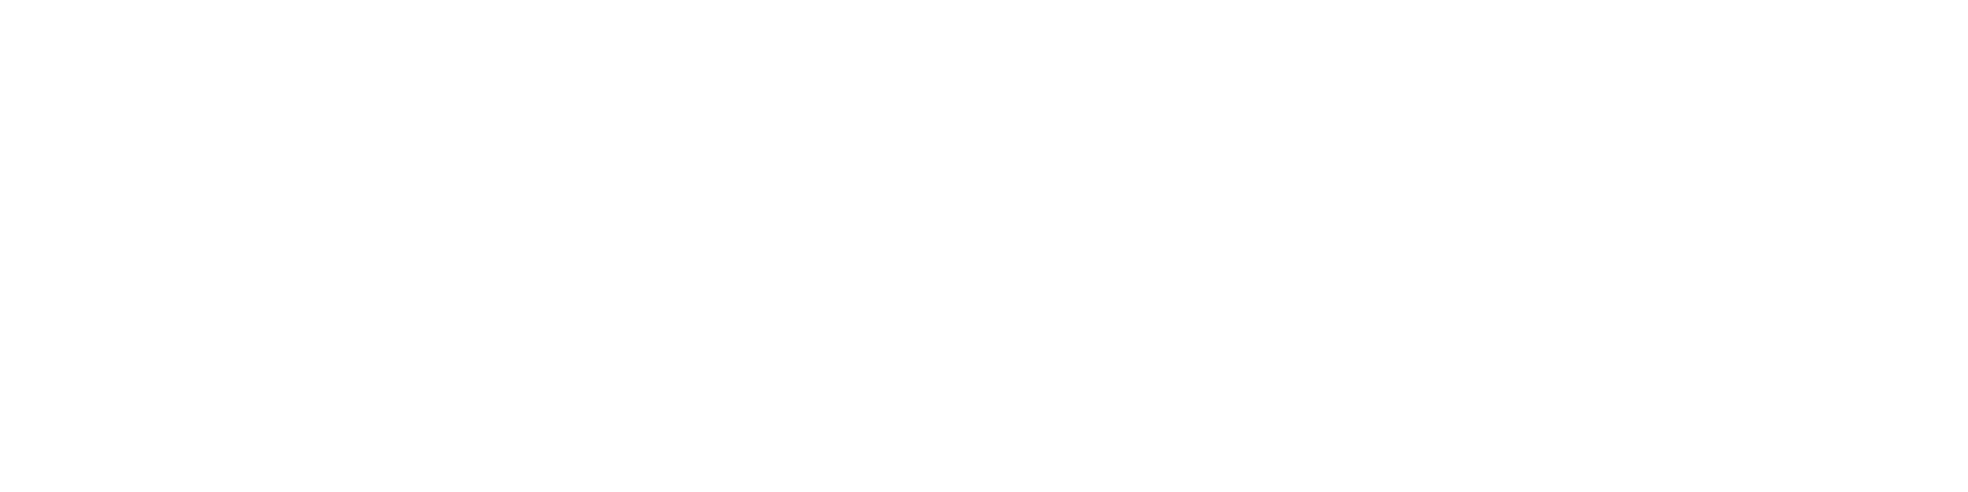

In [33]:
attens = np.linspace(0,6,1)
freqs = np.linspace(11048e6, 11050e6, 11)
fid_array = np.zeros((len(attens),len(freqs)))
thres_array = np.zeros((len(attens),len(freqs)))

adc_offset = 230
qubit_atten = 0
qubit_IF = 700 # MHz
qubit_LO = 3.7513e9 # Hz
qubit_RF = qubit_LO/1e6 - qubit_IF # MHz

setatten(atten=qubit_atten, serial=qubit_SN) # Qubit
setsignalcore(module=qubit_LOmod,output=1,power=7,freq=qubit_LO) # Qubit

now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
for iii, atten in enumerate(attens):
    print("Cavity atten = %.0f" % atten)

    cavity_atten = atten
    setatten(atten=cavity_atten, serial=cavity_SN) # Cavity
    
    for jjj, freq in enumerate(freqs):
        print("Cavity freq = %.2f MHz" % (freq/1e6))
        
        cavity_RF = freq
        cavity_LO = 12.1e9
        cavity_IF = (cavity_LO-cavity_RF)/1e6
        setsignalcore(module=cavity_LOmod,output=1,power=13,freq=cavity_LO) # Cavity. LO = 12.1 GHz
        

        hw_cfg={"res_ch":cavity_ch,
                "qubit_ch":qubit_ch,
               }
        readout_cfg={
            "readout_length":us2cycles(4.6), # [Clock ticks]
            "f_res": cavity_IF, # [MHz]
            "res_phase": 0,
            "adc_trig_offset": adc_offset, # [Clock ticks]
            "res_gain":32000,
            "cavity_RF": cavity_RF/1e6,
            "threshold": np.int(threshold)
            }
        qubit_cfg={
            "relax_delay":25,
            "qubit_RF": qubit_RF,
            "f_ge": qubit_IF, # [MHz]
            "sigma":us2cycles(0.180),
            "pi_gain":np.int(pi_gain),
            }

        atten_cfg={
            "cavity_atten": cavity_atten,
            "qubit_atten": qubit_atten,
            "squeezing_atten": squeezing_atten,
            "squeezing_RF": squeezing_RF,
            }
        expt_cfg={
                "shots":10000, "res_phase":0
               }
        config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg,**atten_cfg} #combine configs
        ssp=SingleShotProgram(cfg=config)
        di0, dq0, di1, dq1 = ssp.acquire(soc, load_pulses=True,progress=True, debug=False)
        
        fid, threshold, angle, ig_new, ie_new, x_pts = hist(data=[di0[0], dq0[0], di0[1], dq0[1]],  plot=True, ran=10)
        plt.close()
        fid_array[iii,jjj] = fid
        thres_array[iii,jjj] = np.int(threshold)

<IPython.core.display.Javascript object>


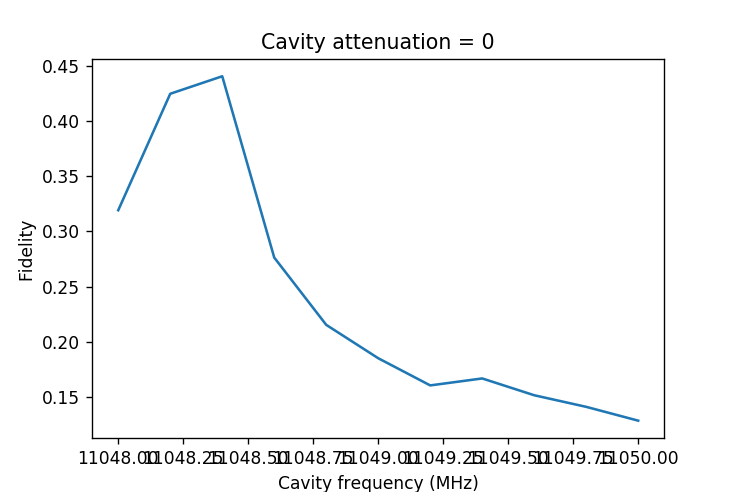

[[0.31923192 0.42462739 0.44047619 0.2764     0.2155     0.1853
  0.1607     0.167      0.1518     0.1413     0.1288    ]]


In [34]:
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(freqs/1e6, fid_array[0])
ax.set_xlabel(r"Cavity frequency (MHz)")
ax.set_ylabel(r"Fidelity")
ax.set_title("Cavity attenuation = %.0f" % attens[0])
print(fid_array)

x_pts = freqs/1e6; y_pts = fid_array[0]

# dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_halfFlux_thruCL/'
# x_pts.tofile(dataFolder + 'optReadout_x_'+ dt_string + '.csv', sep=',', format='%10.3f')
# y_pts.tofile(dataFolder + 'optReadout_y_'+ dt_string + '.csv', sep=',', format='%10.3f')
# plt.savefig(dataFolder + "optReadout_"   + dt_string + '.pdf', dpi=350)

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax.pcolormesh(freqs/1e6, attens, fid_array)
ax.set_xlabel(r"Cavity frequency (MHz)")
ax.set_ylabel(r"Cavity attenuation (dB)")
# plt.savefig("optReadOut_freq_atten_11_afterAddSqz.pdf", dpi=350)
print(fid_array)

# T1

In [39]:
class T1Program(RAveragerProgram):
    def __init__(self,cfg):
        AveragerProgram.__init__(self,cfg)       
        
    def initialize(self):
        cfg=self.cfg
        
        self.q_rp=self.ch_page(self.cfg["qubit_ch"])     # get register page for qubit_ch
        self.r_wait = 3
        self.regwi(self.q_rp, self.r_wait, cfg["start"])
               
        self.cfg["adc_lengths"]=[self.cfg["readout_length"]]*2   #copy over adc acquisition parameters
        self.cfg["adc_freqs"]=[adcfreq(cfg["f_res"])]*2
        
        # add qubit and readout pulses to respective channels
        self.add_pulse(ch=self.cfg["qubit_ch"], name="qubit",style="arb", idata=gauss(mu=cfg["sigma"]*16*4/2,si=cfg["sigma"]*16,length=4*cfg["sigma"]*16,maxv=2**15-1))
        self.add_pulse(ch=self.cfg["res_ch"], name="measure",style="const", length=self.cfg["readout_length"])
               
        # pre-initialize pulses
        self.pulse(ch=cfg["qubit_ch"], name="qubit", phase =0, freq=freq2reg(cfg["f_ge"]), gain=cfg["pi_gain"], play=False)
        self.pulse(ch=cfg["res_ch"], name="measure", freq=freq2reg(adcfreq(cfg["f_res"])), phase=cfg['res_phase'], gain=cfg["res_gain"], play=False)
    
        self.sync_all(us2cycles(500))
    
    def body(self):
        
        self.pulse(ch=self.cfg["qubit_ch"], play=True)  #play probe pulse
        self.sync_all()
        self.sync(self.q_rp,self.r_wait)
        self.trigger_adc(adc1=1, adc2=1, adc_trig_offset=self.cfg["adc_trig_offset"])  #trigger measurement
        self.pulse(ch=self.cfg["res_ch"], name="measure", play=True) # play measurement pulse

        self.sync_all(us2cycles(self.cfg["relax_delay"]))  # wait for qubit to relax
    
    def update(self):
        self.mathi(self.q_rp, self.r_wait, self.r_wait, '+', us2cycles(self.cfg["step"])) # update frequency list index
countIdx=0

In [63]:
adc_offset = 230
cavity_RF = 11.0484e9
cavity_LO = 12.1e9
cavity_IF = (cavity_LO-cavity_RF)/1e6
cavity_atten = 0

qubit_IF = 700      # MHz
qubit_LO = 3.7512e9 # Hz
qubit_atten = 0
qubit_RF = qubit_LO/1e6 - qubit_IF # MHz

squeezing_atten = 40

setatten(atten=qubit_atten, serial=qubit_SN) # Qubit
setatten(atten=cavity_atten, serial=cavity_SN) # Cavity
setatten(atten=squeezing_atten, serial=squeezing_SN) # Squeezing
setsignalcore(module=cavity_LOmod,output=1,power=13,freq=cavity_LO) # Cavity. LO = 12.1 GHz
setsignalcore(module=qubit_LOmod,output=1,power=7,freq=qubit_LO) # Qubit

Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27783
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device 1 Serial number: 27783
Device was found to be device 1
Get attenuation: 0.0
Set attenuation: 0.0
Device 2 Serial number: 27712
Device 3 Serial number: 0
Device 4 Serial number: 0

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27782
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device was found to be devi

In [40]:
hw_cfg={"res_ch":cavity_ch,
        "qubit_ch":qubit_ch,
       }
readout_cfg={
    "readout_length":us2cycles(4.6), # [Clock ticks] #4.6
    "f_res": cavity_IF, # [MHz]
    "res_phase": 0,
    "adc_trig_offset": adc_offset, # [Clock ticks]
    "res_gain":32000,
    "cavity_RF": cavity_RF/1e6,
    "threshold": np.int(threshold),
    }
qubit_cfg={
    "relax_delay":25,
    "qubit_RF": qubit_RF,
    "f_ge": qubit_IF, # [MHz]
    "sigma":us2cycles(0.180),
    "pi_gain":np.int(pi_gain),
    }

atten_cfg={
    "cavity_atten": cavity_atten,
    "qubit_atten": qubit_atten,
    "squeezing_atten": squeezing_atten,
    "squeezing_RF": squeezing_RF,
    }
expt_cfg={ "start":0, "step":1, "expts":110, "reps": 1000,}
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg,**atten_cfg} #combine configs
config

{'adc_trig_offset': 230,
 'cavity_RF': 11048.4,
 'cavity_atten': 0,
 'expts': 110,
 'f_ge': 700,
 'f_res': 1051.6,
 'pi_gain': 2536,
 'qubit_RF': 3051.2,
 'qubit_atten': 0,
 'qubit_ch': 6,
 'readout_length': 1766,
 'relax_delay': 25,
 'reps': 1000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'sigma': 69,
 'squeezing_RF': 0,
 'squeezing_atten': 40,
 'start': 0,
 'step': 1,
 'threshold': 0}

In [41]:
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
t1p=T1Program(cfg=config)
x_pts, avgi, avgq = t1p.acquire(soc, threshold=None, load_pulses=True, progress=True, debug=False)
countIdx = countIdx+1

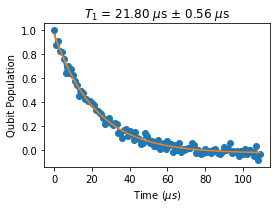

In [42]:
% matplotlib inline
y_pts = avgi[0][0]-np.mean(avgi[0][0][expt_cfg["expts"]-50:expt_cfg["expts"]-1])
multiplier = 1/y_pts[0]
y_pts = y_pts*multiplier

fig = plt.subplots(figsize=(4,3))
ax = plt.subplot(111, title="T1 Experiment", xlabel=f"Time ($\mu s$)", ylabel="Qubit Population")
ax.plot(x_pts, y_pts,'o-');

def T1expo(x, a, T1, c):
    return a*np.exp(-x/T1) + c

popt,pcov = curve_fit(T1expo, x_pts, y_pts); perr = np.sqrt(np.diag(pcov))
ax.plot(x_pts, T1expo(x_pts, *popt))
plt.tight_layout()
T_1 = popt[1]; T_1_sigma = perr[1]
ax.set_title("$T_1$ = %.2f $\mu$s $\pm$ %.2f $\mu$s" % (T_1, T_1_sigma))

dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_quarterFlux_thruCav/'
x_pts.tofile(dataFolder + 'T1_x_'+ dt_string + '.csv', sep=',', format='%10.3f')
y_pts.tofile(dataFolder + 'T1_y_'+ dt_string + '.csv', sep=',', format='%10.3f')
plt.savefig(dataFolder + "T1_"   + dt_string + '.pdf', dpi=350)

# T2 RAMSEY

In [68]:
class RamseyProgram(RAveragerProgram):
    def __init__(self,cfg):
        AveragerProgram.__init__(self,cfg)       
        
    def initialize(self):
        cfg=self.cfg
        
        self.q_rp=self.ch_page(self.cfg["qubit_ch"])     # get register page for qubit_ch
        self.r_wait = 3
        self.r_phase2 = 4
        self.r_phase=self.sreg(cfg["qubit_ch"], "phase")
        self.regwi(self.q_rp, self.r_wait, cfg["start"])
        self.regwi(self.q_rp, self.r_phase2, 0)
        
        f_res=freq2reg(adcfreq(cfg["f_res"]))            # conver f_res to dac register value
        f_ge=freq2reg(cfg["f_ge"])
        
        self.cfg["adc_lengths"]=[self.cfg["readout_length"]]*2   #copy over adc acquisition parameters
        self.cfg["adc_freqs"]=[adcfreq(cfg["f_res"])]*2
        
        # add qubit and readout pulses to respective channels
        self.add_pulse(ch=self.cfg["qubit_ch"], name="qubit", style="arb", idata=gauss(mu=cfg["sigma"]*16*4/2,si=cfg["sigma"]*16, length=4*cfg["sigma"]*16, maxv=2**15-1))
        self.add_pulse(ch=self.cfg["res_ch"], name="measure", style="const", length=self.cfg["readout_length"])
               
        # pre-initialize pulses
        self.pulse(ch=cfg["qubit_ch"], name="qubit", phase=0, freq=f_ge, gain=cfg["pi2_gain"], play=False)
        self.pulse(ch=cfg["res_ch"], name="measure", freq=f_res, phase=cfg['res_phase'], gain=cfg["res_gain"], play=False)
    
        self.sync_all(us2cycles(0.2))
    
    def body(self):
        
        self.pulse(ch=self.cfg["qubit_ch"],phase=0, play=True)  #play probe pulse
        self.mathi(self.q_rp, self.r_phase, self.r_phase2,"+",0)
        self.sync_all()
        self.sync(self.q_rp,self.r_wait)
        self.pulse(ch=self.cfg["qubit_ch"], play=True)  #play probe pulse
        self.sync_all(us2cycles(0.05))
        self.trigger_adc(adc1=1, adc2=1, adc_trig_offset=self.cfg["adc_trig_offset"])  #trigger measurement
        self.pulse(ch=self.cfg["res_ch"], name="measure", play=True) # play measurement pulse
        self.sync_all(us2cycles(self.cfg["relax_delay"]))  # wait for qubit to relax
    
    def update(self):
        self.mathi(self.q_rp, self.r_wait, self.r_wait, '+', self.cfg["step"]) # update the time between two π/2 pulses
        self.mathi(self.q_rp, self.r_phase2, self.r_phase2, '+', self.cfg["phase_step"]) # advance the phase of the LO for the second π/2 pulse

In [132]:
adc_offset = 230

cavity_RF = 11.0484e9
cavity_LO = 12.1e9
cavity_IF = (cavity_LO-cavity_RF)/1e6
cavity_atten = 0

qubit_IF = 700                 # MHz
qubit_LO = 3.7512e9           # Hz
qubit_atten = 0
qubit_RF = qubit_LO/1e6 - qubit_IF # MHz

squeezing_atten = 40

setatten(atten=qubit_atten, serial=qubit_SN) # Qubit
setatten(atten=cavity_atten, serial=cavity_SN) # Cavity
setatten(atten=squeezing_atten, serial=squeezing_SN) # Squeezing
setsignalcore(module=cavity_LOmod,output=1,power=13,freq=cavity_LO) # Cavity. LO = 12.1 GHz
setsignalcore(module=qubit_LOmod,output=1,power=7,freq=qubit_LO) # Qubit

Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27783
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device 1 Serial number: 27783
Device was found to be device 1
Get attenuation: 0.0
Set attenuation: 0.0
Device 2 Serial number: 27712
Device 3 Serial number: 0
Device 4 Serial number: 0

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 5 27782
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device was found to be devi

In [133]:
hw_cfg={"res_ch":cavity_ch,
        "qubit_ch":qubit_ch,
       }
readout_cfg={
    "readout_length":us2cycles(4.6), # [Clock ticks]
    "f_res": cavity_IF, # [MHz]
    "res_phase": 0,
    "adc_trig_offset": adc_offset, # [Clock ticks]
    "res_gain":32000,
    "cavity_RF": cavity_RF/1e6,
    "threshold": np.int(threshold),
    }
qubit_cfg={
    "relax_delay":75,
    "qubit_RF": qubit_RF,
    "f_ge": qubit_IF, # [MHz]
    "sigma":us2cycles(0.180),
    "pi_gain":np.int(pi_gain),
    "pi2_gain":np.int(pi_gain/2)
    }

atten_cfg={
    "cavity_atten": cavity_atten,
    "qubit_atten": qubit_atten,
    "squeezing_atten": squeezing_atten,
    "squeezing_RF": squeezing_RF,
    }
expt_cfg={"start":us2cycles(0.0), "step": 8, #us2cycles(0.025), 
          "phase_step": deg2reg(2*360/100), "expts":700,
          "reps": 3000, "rounds": 1
       }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg,**atten_cfg} #combine configs
config

{'adc_trig_offset': 230,
 'cavity_RF': 11046.8,
 'cavity_atten': 5,
 'expts': 700,
 'f_ge': 700,
 'f_res': 1053.2,
 'phase_step': 85899345,
 'pi2_gain': 4120,
 'pi_gain': 8240,
 'qubit_RF': 3051.3,
 'qubit_atten': 0,
 'qubit_ch': 6,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 3000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'rounds': 1,
 'sigma': 69,
 'squeezing_RF': 0,
 'squeezing_atten': 40,
 'start': 0,
 'step': 8,
 'threshold': -15}

In [134]:
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
t2p=RamseyProgram(cfg=config)
x_pts, avgi, avgq= t2p.acquire(soc, threshold=None, load_pulses=True,progress=True, debug=False)

Delta_f = 1.34 MHz
[ -2.17028178   4.41150705   0.74588705  -1.15449772 -12.39878001]


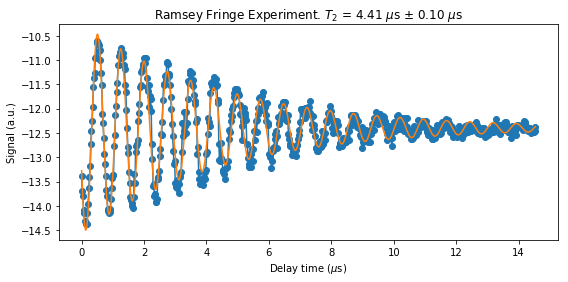

In [135]:
x = cycles2us(x_pts); y_pts = avgi[0][0][0:-1]
x = x[0:-1]

fig = plt.subplots(figsize=(8,4))
ax = plt.subplot(111, title="Ramsey Fringe Experiment", xlabel="Delay time ($\mu$s)", ylabel="Signal (a.u.)")
ax.plot(x,y_pts,'o-')

def T2Ramsey(x, a, T2, T, phi, c):
    return a*np.exp(-x/T2)*np.cos(2*np.pi*x/T + phi) + c

guess = (1, 5, 1, 0, -4.2)
popt,pcov = curve_fit(T2Ramsey, x, y_pts, p0=guess); perr = np.sqrt(np.diag(pcov))
T_2 = popt[1]; T_2_sigma = perr[1]
ax.plot(x, T2Ramsey(x, *popt))
plt.tight_layout()
ax.set_title("Ramsey Fringe Experiment. $T_2$ = %.2f $\mu$s $\pm$ %.2f $\mu$s" % (T_2, T_2_sigma))

print("Delta_f = %.2f MHz" % (1/popt[2]))
print(popt)

dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_quarterFlux_thruCav/'
x_pts.tofile(dataFolder + 'T2R_x_'+ dt_string + '.csv', sep=',', format='%10.3f')
y_pts.tofile(dataFolder + 'T2R_y_'+ dt_string + '.csv', sep=',', format='%10.3f')
plt.savefig(dataFolder + "T2R_"   + dt_string + '.pdf', dpi=350)

### Test scheduling of squeezing and Rabi pulses

In [172]:
# for cat-chevron
class LoopbackProgramSqz(AveragerProgram):
    def __init__(self,cfg):
        AveragerProgram.__init__(self,cfg)

    def initialize(self):
        cfg=self.cfg
        
        f_ge=freq2reg(cfg["f_ge"])
        f_sqz=freq2reg(cfg["f_squeezing"])

        cfg["adc_lengths"]=[cfg["readout_length"]]*2     # add length of adc acquisition to config
        cfg["adc_freqs"]=[adcfreq(cfg["f_ge"])]*2        # add frequency of adc ddc to config
        
        # add pulses to respective channels
        self.add_pulse(ch=cfg["qubit_ch"], name="qubit",style="flat_top", length=cfg["qubit_length"],
                       idata=gauss(mu=cfg["qubit_sigma"]*16*4/2,si=cfg["qubit_sigma"]*16,length=4*cfg["qubit_sigma"]*16,maxv=2**15-1))
        self.add_pulse(ch=cfg["squeezing_ch"], name="squeezing", style="flat_top", length=cfg["squeezing_length"], 
                       idata=gauss(mu=cfg["squeezing_sigma"]*16*4/2,si=cfg["squeezing_sigma"]*16,length=4*cfg["squeezing_sigma"]*16,maxv=2**15-1)) 
        
        # pre-initialize pulses
        self.pulse(ch=cfg["qubit_ch"], name="qubit", phase=cfg["qubit_phase"], freq=f_ge, gain=cfg["qubit_gain"], play=False)
        self.pulse(ch=cfg["squeezing_ch"], name="squeezing", phase=cfg['squeezing_phase'],
                   freq=f_sqz, gain=cfg["squeezing_gain"], play=False)
               
        self.synci(200)
    
    def body(self):
        cfg=self.cfg
        
        self.trigger_adc(adc1=1, adc2=1,adc_trig_offset=self.cfg["adc_trig_offset"])  # trigger the adc acquisition
        self.pulse(ch=cfg["squeezing_ch"], name="squeezing", play=True)               # play squeezing pulse
        self.wait_ch(ch=cfg["qubit_ch"], wait_t=cfg["squeezing2Rabi_wait"])           # wait before Rabi 
        self.pulse(ch=cfg["qubit_ch"], name="qubit", play=True)                       # play Rabi pulse
#         self.sync_all(us2cycles(0))
        self.sync_all(us2cycles(cfg["relax_delay"]))                                  # sync all channels

In [95]:
squeezing2Rabi_wait = us2cycles(0.02) # delay from finishing ramping up squeezing to starting Rabi
squeezing_sigma = us2cycles(0.16)
qubit_length = us2cycles(0.1)
qubit_sigma = us2cycles(0.04)

config={"adc_trig_offset": 150,
        "relax_delay":0,
        "pulse_style": "flat_top",
        "reps":1,
        "soft_avgs":100,
        "readout_length":500, 
        
        "f_ge":1000, # IF in MHz
        "qubit_ch":4,
        "qubit_sigma": qubit_sigma,
        "qubit_length":qubit_length,
        "qubit_phase":0,
        "qubit_gain":30000,
        
        "f_squeezing":1000, # IF in MHz
        "squeezing_ch":5,
        "squeezing_sigma": squeezing_sigma,
        "squeezing2Rabi_wait": 2*squeezing_sigma + squeezing2Rabi_wait,
        "squeezing_length": qubit_length + squeezing2Rabi_wait + 4*qubit_sigma, # sqz is 30ns longer than qubit bc qubit starts 30ns after sqz
        "squeezing_phase": 0,
        "squeezing_gain": 30000,
       }

In [96]:
prog = LoopbackProgramSqz(config)
iq0, iq1 = prog.acquire_decimated(soc, load_pulses=True, progress=True, debug=False)

<IPython.core.display.Javascript object>


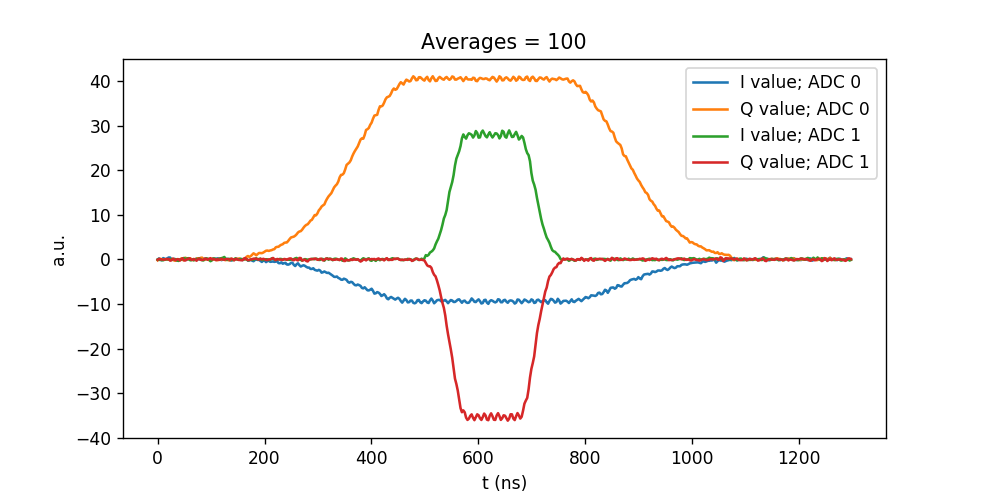

In [64]:
# Plot results.
plt.figure(figsize=(8,4))
t = np.linspace(0,499,500)*2.6
plt.plot(t, iq0[0], label="I value; ADC 0")
plt.plot(t, iq0[1], label="Q value; ADC 0")
plt.plot(t, iq1[0], label="I value; ADC 1")
plt.plot(t, iq1[1], label="Q value; ADC 1")
plt.ylabel("a.u.")
plt.xlabel("t (ns)")
plt.title("Averages = " + str(config["soft_avgs"]))
plt.legend()
# plt.savefig("images_early/Send_recieve_pulse_Rabi_sqz_5.pdf", dpi=350)

### continuous loopback to check stark freq

In [48]:
class LoopbackContinuous(AveragerProgram):
    def __init__(self,cfg):
        AveragerProgram.__init__(self,cfg)

    def initialize(self):
        cfg=self.cfg   
        
        r_freq_qubit=self.sreg(cfg["qubit_ch"], "freq")   # Get frequency register for qubit_ch
        
        qubit_freq=freq2reg(adcfreq(cfg["qubit_freq"]))  # convert frequency to dac frequency (ensuring it is an available adc frequency)
        stark_freq=freq2reg(cfg["stark_freq"])
        
        cfg["adc_lengths"]=[cfg["readout_length"]]*2         #add length of adc acquisition to config
        cfg["adc_freqs"]=[adcfreq(cfg["qubit_freq"])]*2   #add frequency of adc ddc to config
        
        self.add_pulse(ch=cfg["qubit_ch"], name="qubit", style=cfg["pulse_style"],length=cfg["length"])  #add a constant pulse to the pulse library
        self.add_pulse(ch=cfg["stark_ch"], name="stark", style=cfg["pulse_style"],length=cfg["length"])  #add a constant pulse to the pulse library
        
        self.pulse(ch=cfg["qubit_ch"], name="qubit", freq=qubit_freq, gain=cfg["qubit_gain"], 
                   t=0, phase=cfg["qubit_phase"], play=True, stdysel=0, phrst=0, mode=1, outsel=1) # pre-configure readout pulse
        self.pulse(ch=cfg["stark_ch"], name="stark", freq=stark_freq, gain=cfg["stark_gain"], 
                   t=0, phase=cfg["stark_phase"], play=True, stdysel=0, phrst=0, mode=1, outsel=1) # pre-configure readout pulse

        self.synci(200)  # give processor some time to configure pulses   
    
    def body(self):
        pass


In [89]:
config={"pulse_style": "const",
        "length": 30000, 
        "readout_length":1000, 
        "soft_avgs":2,
        "reps":1,
    
        "qubit_gain": 0*32000,
        "qubit_freq": qubit_IF,
        "qubit_ch": qubit_ch,
        "qubit_atten": qubit_atten,
        "qubit_phase": deg2reg(90),
    
        "stark_gain": 0*32000,
        "stark_freq": stark_IF, # MHz
        "stark_ch": squeezing_ch,
        "stark_atten": stark_atten,
        "stark_phase": deg2reg(0),
       }
config

{'length': 30000,
 'pulse_style': 'const',
 'qubit_atten': 0,
 'qubit_ch': 6,
 'qubit_freq': 700,
 'qubit_gain': 0,
 'qubit_phase': 1073741824,
 'readout_length': 1000,
 'reps': 1,
 'soft_avgs': 2,
 'stark_atten': 0,
 'stark_ch': 5,
 'stark_freq': 2351.3,
 'stark_gain': 0,
 'stark_phase': 0}

In [90]:
prog =LoopbackContinuous(config)
iq0, iq1 = prog.acquire_decimated(soc, load_pulses=True, progress=True)

# QUBIT SPEC WITH STARK TONE

In [98]:
class PulseProbeSpectroscopyStarkProgram(RAveragerProgram):
    def initialize(self):
        cfg=self.cfg
        
        self.q_rp=self.ch_page(cfg["qubit_ch"])     # get register page for qubit_ch
        self.r_freq=self.sreg(cfg["qubit_ch"], "freq")   # get frequency register for qubit_ch    
        
        f_res=freq2reg(adcfreq(cfg["f_res"]))            # conver f_res to dac register value
        f_stark=freq2reg(adcfreq(cfg["f_stark"])) 

        cfg["adc_lengths"]=[cfg["readout_length"]]*2   # copy over adc acquisition parameters
        cfg["adc_freqs"]=[adcfreq(cfg["f_res"])]*2
        
        # add qubit and readout pulses to respective channels
        self.add_pulse(ch=cfg["stark_ch"], name="stark",style="const", length=cfg["stark_length"])
        self.add_pulse(ch=cfg["qubit_ch"], name="qubit",style="const", length=cfg["pump_length"])
        self.add_pulse(ch=cfg["res_ch"], name="measure",style="const", length=cfg["readout_length"])
        self.f_start =freq2reg(cfg["start"])  # get start/step frequencies
        self.f_step =freq2reg(cfg["step"])
        
        # pre-initialize pulses
        self.pulse(ch=cfg["stark_ch"], name="stark", phase=0, freq=f_stark, gain=cfg["stark_gain"], play=False)
        self.pulse(ch=cfg["qubit_ch"], name="qubit", freq=self.f_start, gain=cfg["qubit_gain"], t=0, phase=0, play=False, stdysel=0, phrst=0, mode=1, outsel=1) # pre-configure readout pulse
        self.pulse(ch=cfg["res_ch"], name="measure", freq=f_res, phase=cfg['res_phase'], gain=cfg["res_gain"], play=False)
    
        self.sync_all(us2cycles(1))
    
    def body(self):
        cfg=self.cfg
        self.pulse(ch=cfg["stark_ch"], name="stark", play=True)                                  # play stark pulse
        self.wait_ch(ch=cfg["qubit_ch"], wait_t=cfg["stark2pump_wait"])                          # wait before pump
        self.pulse(ch=cfg["qubit_ch"], name="qubit", play=True)                                  # play pump pulse
        self.sync_all(us2cycles(0.05))                                                           # align channels and wait 50ns
        
        self.trigger_adc(adc1=1, adc2=1, adc_trig_offset=cfg["adc_trig_offset"])                 # trigger measurement
        self.pulse(ch=cfg["res_ch"], play=True)                                                  # play measurement pulse
        self.sync_all(us2cycles(cfg["relax_delay"]))                                             # wait for qubit to relax
    
    def update(self):
        self.mathi(self.q_rp, self.r_freq, self.r_freq, '+', self.f_step) # update frequency list index

In [99]:
adc_offset = 230
cavity_RF = 11.0484e9 
cavity_LO = 12.1e9
cavity_IF = (cavity_LO-cavity_RF)/1e6
cavity_atten = 0

qubit_IF = 700 # MHz
qubit_LO = 3.7512e9  # Hz
qubit_atten = 40
qubit_RF = qubit_LO/1e6 - qubit_IF # MHz

stark_RF = qubit_RF*2
stark_LO = qubit_LO # use the same LO for phase coherence
stark_IF = stark_RF - stark_LO/1e6
stark_atten = 0

setatten(atten=qubit_atten, serial=qubit_SN) # Qubit
setatten(atten=cavity_atten, serial=cavity_SN) # Cavity
setatten(atten=stark_atten, serial=squeezing_SN) # Squeezing
setsignalcore(module=cavity_LOmod,output=1,power=13,freq=cavity_LO) # Cavity. LO = 12.1 GHz
setsignalcore(module=qubit_LOmod,output=1,power=7,freq=qubit_LO) # Qubit

Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 40 27783
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device 1 Serial number: 27783
Device was found to be device 1
Get attenuation: 0.0
Set attenuation: 40.0
Device 2 Serial number: 27712
Device 3 Serial number: 0
Device 4 Serial number: 0

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27782
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device was found to be de

In [17]:
hw_cfg={"res_ch":cavity_ch, "qubit_ch":qubit_ch, "stark_ch":squeezing_ch}
atten_cfg={"cavity_atten": cavity_atten, "qubit_atten": qubit_atten, "stark_atten": stark_atten,}

pump_length = us2cycles(40)
stark2pump_wait = us2cycles(1)
stark_length = stark2pump_wait + pump_length + stark2pump_wait

readout_cfg={
    "readout_length":us2cycles(4.6), # [Clock ticks]
    "f_res": cavity_IF,              # MHz
    "res_phase": 0,
    "adc_trig_offset": adc_offset,   # [Clock ticks]
    "res_gain":32000,
    "cavity_RF": cavity_RF/1e6,
    }
qubit_cfg={
    "relax_delay":75,
    "qubit_RF": qubit_RF,
    "f_ge": qubit_IF,                # MHz
    "qubit_start": qubit_RF-10,
    "qubit_stop": qubit_RF+10,
    "qubit_gain": 3000,
    "pump_length": pump_length,
    }
stark_cfg={
    "f_stark": stark_IF,             # MHz
    "stark_RF": stark_RF,            # MHz
    "stark_length": stark_length,
    "stark_gain": 0*32000,
    "stark2pump_wait": stark2pump_wait,
    }

expt_cfg={"reps": 5000, "rounds":1,}
expt_cfg["center"] = qubit_IF; expt_cfg["span"] = 4; expt_cfg["expts"] = 501;
expt_cfg["step"] = 2*expt_cfg["span"] / (expt_cfg["expts"]-1)
expt_cfg["start"] = expt_cfg["center"] - expt_cfg["span"]
fpts=expt_cfg["start"] + expt_cfg["step"]*np.arange(expt_cfg["expts"])
qubit_cfg["qubit_start"] = qubit_LO/1e6-fpts[-1:][0] 
qubit_cfg["qubit_stop"] = qubit_LO/1e6-fpts[:1][0]

print(qubit_cfg["qubit_start"], qubit_cfg["qubit_stop"])

config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg,**atten_cfg, **stark_cfg} #combine configs
config

3047.2 3055.2


{'adc_trig_offset': 230,
 'cavity_RF': 11048.4,
 'cavity_atten': 0,
 'center': 700,
 'expts': 501,
 'f_ge': 700,
 'f_res': 1051.6,
 'f_stark': 2351.2,
 'pump_length': 15360,
 'qubit_RF': 3051.2,
 'qubit_atten': 40,
 'qubit_ch': 6,
 'qubit_gain': 10000,
 'qubit_start': 3047.2,
 'qubit_stop': 3055.2,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 3000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'rounds': 1,
 'span': 4,
 'stark2pump_wait': 384,
 'stark_RF': 6102.4,
 'stark_atten': 0,
 'stark_ch': 5,
 'stark_gain': 0,
 'stark_length': 16128,
 'start': 696,
 'step': 0.016}

In [18]:
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
qspec=PulseProbeSpectroscopyStarkProgram(cfg=config)
expt_pts, avgi, avgq = qspec.acquire(soc, load_pulses=True,progress=True, debug=False)

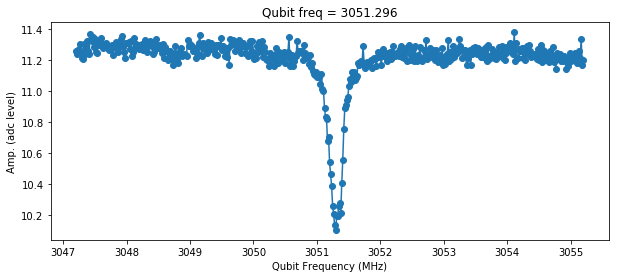

In [22]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(10,4))
ax.set_xlabel("Qubit Frequency (MHz)"); ax.set_ylabel("Amp. (adc level)")
amp = np.abs(avgi[0][0]+1j*avgq[0][0])
x_pts = qubit_LO/1e6 - expt_pts; y_pts = amp;
max_freq = qubit_LO/1e6 - expt_pts[np.argmin(y_pts)]

ax.set_title("Qubit freq = " + str(max_freq))
ax.plot(x_pts, y_pts, '-o')

# dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_quarterFlux_thruCav/'
# x_pts.tofile(dataFolder + 'qubitSpecStark_x_'+ dt_string + '.csv', sep=',', format='%10.3f')
# y_pts.tofile(dataFolder + 'qubitSpecStark_y_'+ dt_string + '.csv', sep=',', format='%10.3f')
# plt.savefig(dataFolder + "qubitSpecStark_"   + dt_string + '.pdf', dpi=350)

### sweep over Stark power

In [100]:
hw_cfg={"res_ch":cavity_ch, "qubit_ch":qubit_ch, "stark_ch":squeezing_ch}
atten_cfg={"cavity_atten": cavity_atten, "qubit_atten": qubit_atten, "stark_atten": stark_atten,}

pump_length = us2cycles(40)
stark2pump_wait = us2cycles(1)
stark_length = stark2pump_wait + pump_length + stark2pump_wait

readout_cfg={
    "readout_length":us2cycles(4.6), # [Clock ticks]
    "f_res": cavity_IF,              # MHz
    "res_phase": 0,
    "adc_trig_offset": adc_offset,   # [Clock ticks]
    "res_gain":32000,
    "cavity_RF": cavity_RF/1e6,
    }
qubit_cfg={
    "relax_delay":75,
    "qubit_RF": qubit_RF,
    "f_ge": qubit_IF,                # MHz
    "qubit_start": qubit_RF-10,
    "qubit_stop": qubit_RF+10,
    "qubit_gain": 3000,
    "pump_length": pump_length,
    }
stark_cfg={
    "f_stark": stark_IF,             # MHz
    "stark_RF": stark_RF,            # MHz
    "stark_length": stark_length,
    "stark_gain": 0*32000,
    "stark2pump_wait": stark2pump_wait,
    }

expt_cfg={"reps": 5000, "rounds":1,}
expt_cfg["center"] = qubit_IF; expt_cfg["span"] = 4; expt_cfg["expts"] = 501;
expt_cfg["step"] = 2*expt_cfg["span"] / (expt_cfg["expts"]-1)
expt_cfg["start"] = expt_cfg["center"] - expt_cfg["span"]
fpts=expt_cfg["start"] + expt_cfg["step"]*np.arange(expt_cfg["expts"])
qubit_cfg["qubit_start"] = qubit_LO/1e6-fpts[-1:][0] 
qubit_cfg["qubit_stop"] = qubit_LO/1e6-fpts[:1][0]

starkgain_expt_cfg={"starkgain_start":0, "starkgain_step":1000, "starkgain_expts":33}
starkgain_expt_pts=[starkgain_expt_cfg["starkgain_start"] + ii*starkgain_expt_cfg["starkgain_step"] for ii in range(starkgain_expt_cfg["starkgain_expts"])]

config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg,**atten_cfg, **stark_cfg, **starkgain_expt_cfg} #combine configs
config

{'adc_trig_offset': 230,
 'cavity_RF': 11048.4,
 'cavity_atten': 0,
 'center': 700,
 'expts': 501,
 'f_ge': 700,
 'f_res': 1051.6,
 'f_stark': 2351.2,
 'pump_length': 15360,
 'qubit_RF': 3051.2,
 'qubit_atten': 40,
 'qubit_ch': 6,
 'qubit_gain': 3000,
 'qubit_start': 3047.2,
 'qubit_stop': 3055.2,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 5000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'rounds': 1,
 'span': 4,
 'stark2pump_wait': 384,
 'stark_RF': 6102.4,
 'stark_atten': 0,
 'stark_ch': 5,
 'stark_gain': 0,
 'stark_length': 16128,
 'starkgain_expts': 33,
 'starkgain_start': 0,
 'starkgain_step': 1000,
 'start': 696,
 'step': 0.016}

In [101]:
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
results = np.zeros((len(starkgain_expt_pts), expt_cfg["expts"]))
min_freqs = np.zeros(len(starkgain_expt_pts))

for jjj, stark_gain in enumerate(starkgain_expt_pts):
    print(jjj)
    config["stark_gain"] = stark_gain
    
    qspec=PulseProbeSpectroscopyStarkProgram(cfg=config)
    expt_pts, avgi, avgq = qspec.acquire(soc, load_pulses=True,progress=True, debug=False)
    amp = np.abs(avgi[0][0]+1j*avgq[0][0])
    min_freq = qubit_LO/1e6 - expt_pts[np.argmin(amp)]
    
    results[jjj,:] = amp
    min_freqs[jjj] = min_freq

0



1



2



3



4


...


28



29



30



31



32


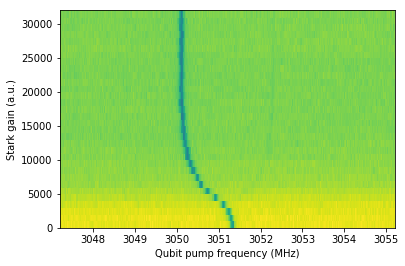

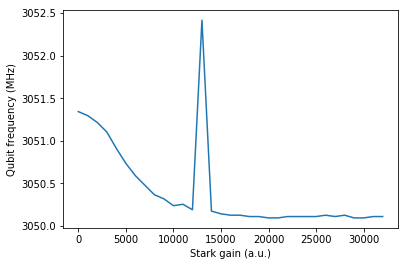

In [104]:
% matplotlib inline
starkgain_expt_pts = np.array(starkgain_expt_pts)
x_pts = qubit_LO/1e6 - expt_pts; y_pts = starkgain_expt_pts

fig, ax = plt.subplots(figsize=(6,4))
ax.pcolormesh(x_pts, y_pts, results)
ax.set_xlabel("Qubit pump frequency (MHz)")
ax.set_ylabel("Stark gain (a.u.)")

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(y_pts, min_freqs)
ax.set_ylabel("Qubit frequency (MHz)")
ax.set_xlabel("Stark gain (a.u.)")

dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_quarterFlux_thruCav/'
# plt.savefig(dataFolder + "qubitSpecStark_sweepStarkGain_" + dt_string + ".pdf", dpi=350)
y_pts.tofile(dataFolder + 'qubitSpecStark_sweepStarkGain_Qubit3k_starkgain_' + dt_string + '.csv', sep=',', format='%10.3f')
x_pts.tofile(dataFolder + 'qubitSpecStark_sweepStarkGain_Qubit3k_freq_' + dt_string + '.csv', sep=',', format='%10.3f')
results.tofile(dataFolder + 'qubitSpecStark_sweepStarkGain_Qubit3k_results_' + dt_string + '.csv', sep=',', format='%10.3f')

Text(0.5,0,'Amp. (adc units)')

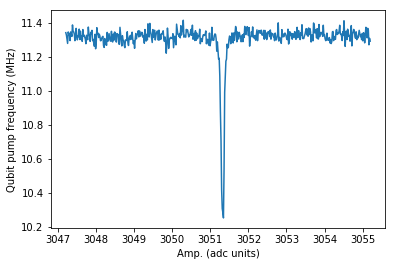

In [105]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(x_pts, results[0,:])
ax.set_ylabel("Qubit pump frequency (MHz)")
ax.set_xlabel("Amp. (adc units)")

### sweep over Stark frequency

In [27]:
hw_cfg={"res_ch":cavity_ch, "qubit_ch":qubit_ch, "stark_ch":squeezing_ch}
atten_cfg={"cavity_atten": cavity_atten, "qubit_atten": qubit_atten, "stark_atten": stark_atten,}

pump_length = us2cycles(40)
stark2pump_wait = us2cycles(1)
stark_length = stark2pump_wait + pump_length + stark2pump_wait

readout_cfg={
    "readout_length":us2cycles(4.6), # [Clock ticks]
    "f_res": cavity_IF,              # MHz
    "res_phase": 0,
    "adc_trig_offset": adc_offset,   # [Clock ticks]
    "res_gain":32000,
    "cavity_RF": cavity_RF/1e6,
    }
qubit_cfg={
    "relax_delay":75,
    "qubit_RF": qubit_RF,
    "f_ge": qubit_IF,                # MHz
    "qubit_start": qubit_RF-10,
    "qubit_stop": qubit_RF+10,
    "qubit_gain": 10000,
    "pump_length": pump_length,
    }
stark_cfg={
    "f_stark": stark_IF,             # MHz
    "stark_RF": stark_RF,            # MHz
    "stark_length": stark_length,
    "stark_gain": 32000,
    "stark2pump_wait": stark2pump_wait,
    }

expt_cfg={"reps": 3000, "rounds":1,}
expt_cfg["center"] = qubit_IF; expt_cfg["span"] = 15; expt_cfg["expts"] = 1001;
expt_cfg["step"] = 2*expt_cfg["span"] / (expt_cfg["expts"]-1)
expt_cfg["start"] = expt_cfg["center"] - expt_cfg["span"]
fpts=expt_cfg["start"] + expt_cfg["step"]*np.arange(expt_cfg["expts"])
qubit_cfg["qubit_start"] = qubit_LO/1e6-fpts[-1:][0] 
qubit_cfg["qubit_stop"] = qubit_LO/1e6-fpts[:1][0]

starkfreq_expt_cfg={"starkfreq_start":-5, "starkfreq_step":0.25, "starkfreq_expts":29}
starkfreq_expt_pts=[starkfreq_expt_cfg["starkfreq_start"] + ii*starkfreq_expt_cfg["starkfreq_step"] for ii in range(starkfreq_expt_cfg["starkfreq_expts"])]

config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg,**atten_cfg, **stark_cfg, **starkfreq_expt_cfg} #combine configs
config

{'adc_trig_offset': 230,
 'cavity_RF': 11048.4,
 'cavity_atten': 0,
 'center': 700,
 'expts': 1001,
 'f_ge': 700,
 'f_res': 1051.6,
 'f_stark': 2351.2,
 'pump_length': 15360,
 'qubit_RF': 3051.2,
 'qubit_atten': 40,
 'qubit_ch': 6,
 'qubit_gain': 10000,
 'qubit_start': 3036.2,
 'qubit_stop': 3066.2,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 3000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'rounds': 1,
 'span': 15,
 'stark2pump_wait': 384,
 'stark_RF': 6102.4,
 'stark_atten': 0,
 'stark_ch': 5,
 'stark_gain': 32000,
 'stark_length': 16128,
 'starkfreq_expts': 29,
 'starkfreq_start': -5,
 'starkfreq_step': 0.25,
 'start': 685,
 'step': 0.03}

In [28]:
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
results = np.zeros((len(starkfreq_expt_pts), expt_cfg["expts"]))
min_freqs = np.zeros(len(starkfreq_expt_pts))

for jjj, stark_freq in enumerate(starkfreq_expt_pts):
    print(jjj)
    config["f_stark"] = stark_IF + stark_freq
    
    qspec=PulseProbeSpectroscopyStarkProgram(cfg=config)
    expt_pts, avgi, avgq = qspec.acquire(soc, load_pulses=True,progress=True, debug=False)
    amp = np.abs(avgi[0][0]+1j*avgq[0][0])
    min_freq = qubit_LO/1e6 - expt_pts[np.argmin(amp)]
    
    results[jjj,:] = amp
    min_freqs[jjj] = min_freq

0



1



2



3



4


...


24



25



26



27



28


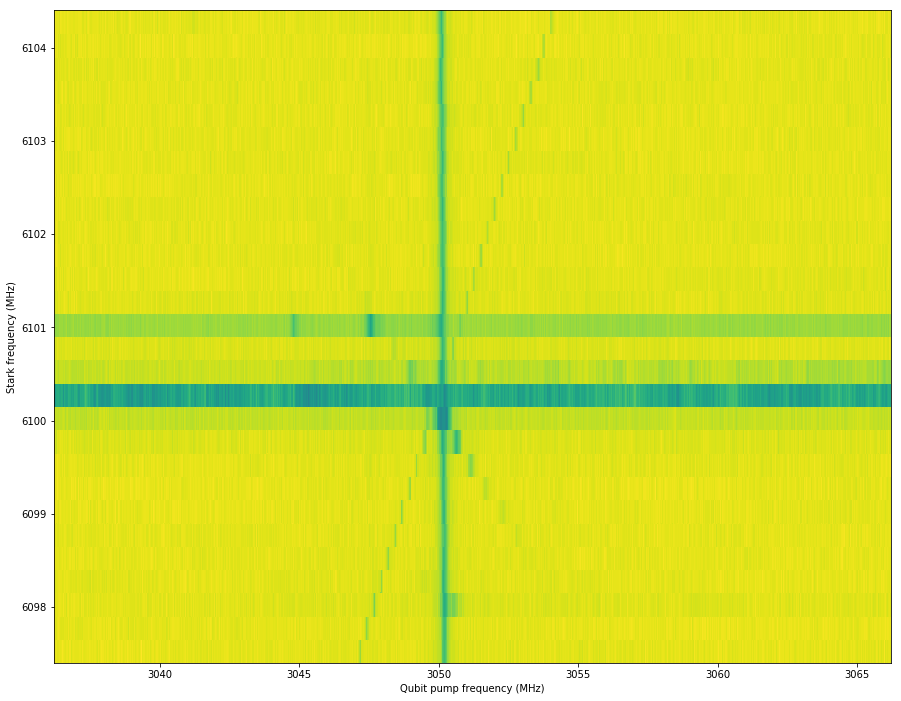

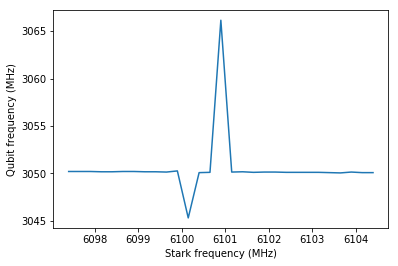

In [29]:
% matplotlib inline
starkfreq_expt_pts = np.array(starkfreq_expt_pts)
x_pts = qubit_LO/1e6 - expt_pts; y_pts = stark_RF + starkfreq_expt_pts

fig, ax = plt.subplots(figsize=(15,12))
ax.pcolormesh(x_pts, y_pts, results)
ax.set_xlabel("Qubit pump frequency (MHz)")
ax.set_ylabel("Stark frequency (MHz)")

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(y_pts, min_freqs)
ax.set_ylabel("Qubit frequency (MHz)")
ax.set_xlabel("Stark frequency (MHz)")

# dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_quarterFlux_thruCav/'
# # plt.savefig(dataFolder + "qubitSpecStark_sweepStarkFreq_" + dt_string + ".pdf", dpi=350)
# y_pts.tofile(dataFolder + 'qubitSpecStark_sweepStarkFreq_starkfreq_' + dt_string + '.csv', sep=',', format='%10.3f')
# x_pts.tofile(dataFolder + 'qubitSpecStark_sweepStarkFreq_freq_' + dt_string + '.csv', sep=',', format='%10.3f')
# results.tofile(dataFolder + 'qubitSpecStark_sweepStarkFreq_results_' + dt_string + '.csv', sep=',', format='%10.3f')

In [30]:
hw_cfg={"res_ch":cavity_ch, "qubit_ch":qubit_ch, "stark_ch":squeezing_ch}
atten_cfg={"cavity_atten": cavity_atten, "qubit_atten": qubit_atten, "stark_atten": stark_atten,}

pump_length = us2cycles(40)
stark2pump_wait = us2cycles(1)
stark_length = stark2pump_wait + pump_length + stark2pump_wait

readout_cfg={
    "readout_length":us2cycles(4.6), # [Clock ticks]
    "f_res": cavity_IF,              # MHz
    "res_phase": 0,
    "adc_trig_offset": adc_offset,   # [Clock ticks]
    "res_gain":32000,
    "cavity_RF": cavity_RF/1e6,
    }
qubit_cfg={
    "relax_delay":75,
    "qubit_RF": qubit_RF,
    "f_ge": qubit_IF,                # MHz
    "qubit_start": qubit_RF-10,
    "qubit_stop": qubit_RF+10,
    "qubit_gain": 10000,
    "pump_length": pump_length,
    }
stark_cfg={
    "f_stark": stark_IF,             # MHz
    "stark_RF": stark_RF,            # MHz
    "stark_length": stark_length,
    "stark_gain": 32000,
    "stark2pump_wait": stark2pump_wait,
    }

expt_cfg={"reps": 3000, "rounds":1,}
expt_cfg["center"] = qubit_IF; expt_cfg["span"] = 15; expt_cfg["expts"] = 1001;
expt_cfg["step"] = 2*expt_cfg["span"] / (expt_cfg["expts"]-1)
expt_cfg["start"] = expt_cfg["center"] - expt_cfg["span"]
fpts=expt_cfg["start"] + expt_cfg["step"]*np.arange(expt_cfg["expts"])
qubit_cfg["qubit_start"] = qubit_LO/1e6-fpts[-1:][0] 
qubit_cfg["qubit_stop"] = qubit_LO/1e6-fpts[:1][0]

starkfreq_expt_cfg={"starkfreq_start":-30, "starkfreq_step":1, "starkfreq_expts":51}
starkfreq_expt_pts=[starkfreq_expt_cfg["starkfreq_start"] + ii*starkfreq_expt_cfg["starkfreq_step"] for ii in range(starkfreq_expt_cfg["starkfreq_expts"])]

config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg,**atten_cfg, **stark_cfg, **starkfreq_expt_cfg} #combine configs
config

{'adc_trig_offset': 230,
 'cavity_RF': 11048.4,
 'cavity_atten': 0,
 'center': 700,
 'expts': 1001,
 'f_ge': 700,
 'f_res': 1051.6,
 'f_stark': 2351.2,
 'pump_length': 15360,
 'qubit_RF': 3051.2,
 'qubit_atten': 40,
 'qubit_ch': 6,
 'qubit_gain': 10000,
 'qubit_start': 3036.2,
 'qubit_stop': 3066.2,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 3000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'rounds': 1,
 'span': 15,
 'stark2pump_wait': 384,
 'stark_RF': 6102.4,
 'stark_atten': 0,
 'stark_ch': 5,
 'stark_gain': 32000,
 'stark_length': 16128,
 'starkfreq_expts': 51,
 'starkfreq_start': -30,
 'starkfreq_step': 1,
 'start': 685,
 'step': 0.03}

In [31]:
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
results = np.zeros((len(starkfreq_expt_pts), expt_cfg["expts"]))
min_freqs = np.zeros(len(starkfreq_expt_pts))

for jjj, stark_freq in enumerate(starkfreq_expt_pts):
    print(jjj)
    config["f_stark"] = stark_IF + stark_freq
    
    qspec=PulseProbeSpectroscopyStarkProgram(cfg=config)
    expt_pts, avgi, avgq = qspec.acquire(soc, load_pulses=True,progress=True, debug=False)
    amp = np.abs(avgi[0][0]+1j*avgq[0][0])
    min_freq = qubit_LO/1e6 - expt_pts[np.argmin(amp)]
    
    results[jjj,:] = amp
    min_freqs[jjj] = min_freq

0



1



2



3



4


...


46



47



48



49



50


(3049, 3051)

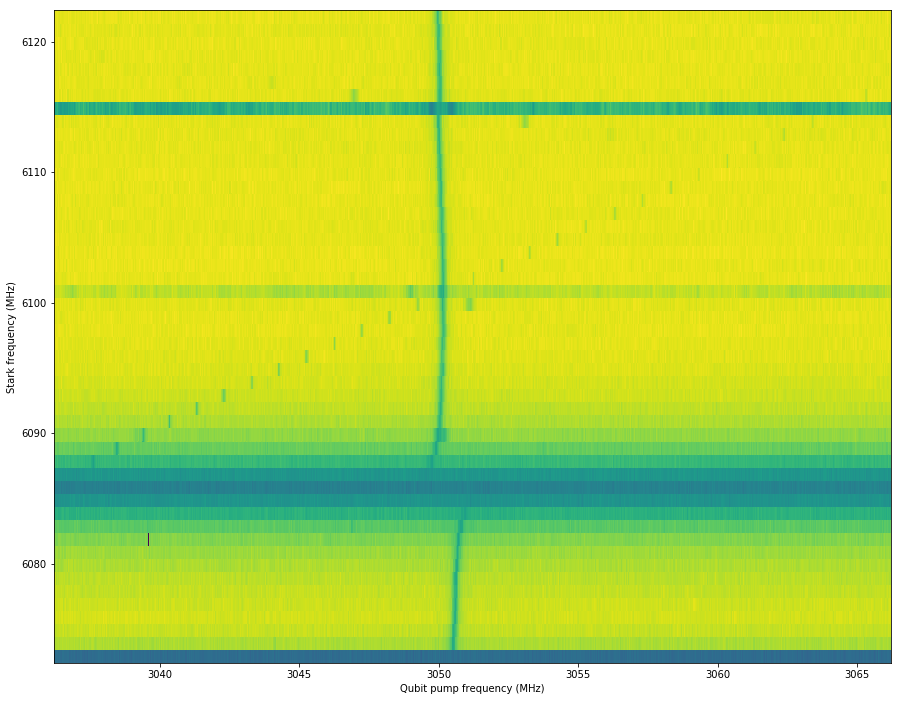

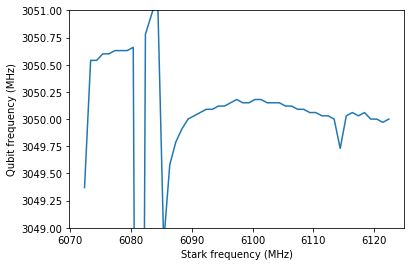

In [34]:
% matplotlib inline
starkfreq_expt_pts = np.array(starkfreq_expt_pts)
x_pts = qubit_LO/1e6 - expt_pts; y_pts = stark_RF + starkfreq_expt_pts

fig, ax = plt.subplots(figsize=(15,12))
ax.pcolormesh(x_pts, y_pts, results)
ax.set_xlabel("Qubit pump frequency (MHz)")
ax.set_ylabel("Stark frequency (MHz)")

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(y_pts, min_freqs)
ax.set_ylabel("Qubit frequency (MHz)")
ax.set_xlabel("Stark frequency (MHz)")
ax.set_ylim([3049,3051])

# dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_quarterFlux_thruCav/'
# # plt.savefig(dataFolder + "qubitSpecStark_sweepStarkFreq_" + dt_string + ".pdf", dpi=350)
# y_pts.tofile(dataFolder + 'qubitSpecStark_sweepStarkFreq_starkfreq_' + dt_string + '.csv', sep=',', format='%10.3f')
# x_pts.tofile(dataFolder + 'qubitSpecStark_sweepStarkFreq_freq_' + dt_string + '.csv', sep=',', format='%10.3f')
# results.tofile(dataFolder + 'qubitSpecStark_sweepStarkFreq_results_' + dt_string + '.csv', sep=',', format='%10.3f')

# CAT-CHEVRON EXPERIMENT

In [43]:
class CatChevronProgram(AveragerProgram):
    def initialize(self):
        cfg=self.cfg
        
        f_res=freq2reg(adcfreq(cfg["f_res"]))            # conver f_res to dac register value
        f_ge=freq2reg(cfg["f_ge"])
        f_sqz=freq2reg(cfg["f_squeezing"])

        cfg["adc_lengths"]=[cfg["readout_length"]]*2     # add length of adc acquisition to config
        cfg["adc_freqs"]=[adcfreq(cfg["f_res"])]*2       # add frequency of adc ddc to config
        
        # add pulses to respective channels
        self.add_pulse(ch=cfg["qubit_ch"], name="qubit",style="flat_top", length=cfg["qubit_length"],
                       idata=gauss(mu=cfg["qubit_sigma"]*16*4/2,si=cfg["qubit_sigma"]*16,length=4*cfg["qubit_sigma"]*16,maxv=2**15-1))
        self.add_pulse(ch=cfg["res_ch"], name="measure",style="const", length=cfg["readout_length"])
        self.add_pulse(ch=cfg["squeezing_ch"], name="squeezing", style="flat_top", length=cfg["squeezing_length"], 
                       idata=gauss(mu=cfg["squeezing_sigma"]*16*4/2,si=cfg["squeezing_sigma"]*16,length=4*cfg["squeezing_sigma"]*16,maxv=2**15-1))               
        
        # pre-initialize pulses
        self.pulse(ch=cfg["qubit_ch"], name="qubit", phase=cfg["qubit_phase"], freq=f_ge, gain=cfg["qubit_gain"], play=False)
        self.pulse(ch=cfg["res_ch"], name="measure", freq=f_res, phase=cfg['res_phase'], gain=cfg["res_gain"], play=False)
        self.pulse(ch=cfg["squeezing_ch"], name="squeezing", phase=cfg['squeezing_phase'],
                   freq=f_sqz, gain=cfg["squeezing_gain"], play=False)
               
        self.synci(200)
        
    def body(self):
        cfg=self.cfg
        self.pulse(ch=cfg["squeezing_ch"], name="squeezing", play=True)                # play squeezing pulse
        self.wait_ch(ch=cfg["qubit_ch"], wait_t=cfg["squeezing2Rabi_wait"])            # wait before Rabi 
        self.pulse(ch=cfg["qubit_ch"], name="qubit", play=True)                        # play Rabi pulse

        self.sync_all(us2cycles(0))
        self.trigger_adc(adc1=1, adc2=1, adc_trig_offset=self.cfg["adc_trig_offset"])  # trigger measurement
        self.pulse(ch=cfg["res_ch"], play=True)                                        # play measurement pulse
        self.sync_all(us2cycles(self.cfg["relax_delay"]))                              # wait for qubit to relax

In [44]:
adc_offset = 230
cavity_RF = 11.0484e9 
cavity_LO = 12.1e9
cavity_IF = (cavity_LO-cavity_RF)/1e6
cavity_atten = 0

qubit_LO = 3.7512e9               # Hz
qubit_IF = 700                     # MHz
qubit_RF = qubit_LO/1e6 - qubit_IF # MHz
qubit_atten = 0

squeezing_RF = 2*qubit_RF
squeezing_LO = qubit_LO # use the same LO for phase coherence
squeezing_IF = squeezing_RF - squeezing_LO/1e6
squeezing_atten = 0

setatten(atten=qubit_atten, serial=qubit_SN) # Qubit
setatten(atten=cavity_atten, serial=cavity_SN) # Cavity
setatten(atten=squeezing_atten, serial=squeezing_SN) # Squeezing
setsignalcore(module=cavity_LOmod,output=1,power=13,freq=cavity_LO) # Cavity LO = 12.1 GHz fixed
setsignalcore(module=qubit_LOmod,output=1,power=7,freq=qubit_LO) # Qubit LO is varied

Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27783
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device 1 Serial number: 27783
Device was found to be device 1
Get attenuation: 0.0
Set attenuation: 0.0
Device 2 Serial number: 27712
Device 3 Serial number: 0
Device 4 Serial number: 0

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>Microsoft Windows [Version 10.0.19042.1466]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27782
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device was found to be devi

In [84]:
hw_cfg={"res_ch":cavity_ch, "qubit_ch":qubit_ch, "squeezing_ch":squeezing_ch,}
atten_cfg={"cavity_atten": cavity_atten, "qubit_atten": qubit_atten, "squeezing_atten": squeezing_atten,}
expt_cfg={"start":4, "step":20, "expts":120, "reps": 3000}
expt_pts=[expt_cfg["start"] + ii*expt_cfg["step"] for ii in range(expt_cfg["expts"])]

squeezing2Rabi_wait =  us2cycles(0.02)                                           # from finishing ramping up squeezing to starting Rabi
squeezing_sigma =  us2cycles(0.16)                                               # 2sigma should be >> 1/2K
qubit_length = us2cycles(0.1)                                                    # dummy value, to be varied in the loop
qubit_sigma = us2cycles(0.04)   #0.04                                            # 80 ns ramp in Grimm
squeezing_length = squeezing2Rabi_wait + qubit_length + 4*qubit_sigma            # sqz is longer than qubit bc it starts before qubit
res_wait = squeezing_length + 4*squeezing_sigma

readout_cfg={
    "res_wait": res_wait,
    "readout_length": us2cycles(4.6),
    "res_phase": 0,
    "res_gain": 32000,
    "cavity_RF": cavity_RF/1e6, # just for displaying
    "f_res": cavity_IF, # [MHz], played by ADC
    "adc_trig_offset": adc_offset,
    "threshold": np.int(threshold),
    }
qubit_cfg={
    "qubit_sigma": qubit_sigma,
    "qubit_length": qubit_length,
    "qubit_phase": deg2reg(0),
    "qubit_gain": 1000,
    "qubit_RF": qubit_RF, # just for displaying
    "f_ge": qubit_IF, # [MHz], played by ADC
    "relax_delay":75,
    }
sqz_cfg={
    "squeezing_sigma": squeezing_sigma,
    "squeezing2Rabi_wait": 2*squeezing_sigma + squeezing2Rabi_wait,
    "squeezing_length": squeezing_length,  
    "squeezing_phase": deg2reg(0),
    "squeezing_gain": 0*32000,
    "squeezing_RF": squeezing_RF, # just for displaying
    "f_squeezing": squeezing_IF, # [MHz], played by ADC
    }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg, **sqz_cfg, **atten_cfg} # combine configs
config

{'adc_trig_offset': 230,
 'cavity_RF': 11048.4,
 'cavity_atten': 0,
 'expts': 120,
 'f_ge': 700,
 'f_res': 1051.6,
 'f_squeezing': 2351.2,
 'qubit_RF': 3051.2,
 'qubit_atten': 0,
 'qubit_ch': 6,
 'qubit_gain': 1000,
 'qubit_length': 38,
 'qubit_phase': 0,
 'qubit_sigma': 15,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 3000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'res_wait': 349,
 'squeezing2Rabi_wait': 129,
 'squeezing_RF': 6102.4,
 'squeezing_atten': 0,
 'squeezing_ch': 5,
 'squeezing_gain': 0,
 'squeezing_length': 105,
 'squeezing_phase': 0,
 'squeezing_sigma': 61,
 'start': 4,
 'step': 20,
 'threshold': 0}

In [85]:
# single Rabi length
results=[]
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
for length in tqdm(expt_pts): # already in cycles
    qubit_length=length
    squeezing_length = qubit_length + squeezing2Rabi_wait + 4*qubit_sigma
    res_wait = squeezing_length + 4*squeezing_sigma
    config["res_wait"] = res_wait
    config["qubit_length"] = qubit_length
    config["squeezing_length"] = squeezing_length

    catChevron = CatChevronProgram(config)
    avgi,avgq = catChevron.acquire(soc, threshold=None, load_pulses=True, progress=False,debug=False)
    results.append(avgi[0][0])

100%|██████████| 120/120 [01:02<00:00,  1.88it/s]


Omega_x = 0.65 MHz


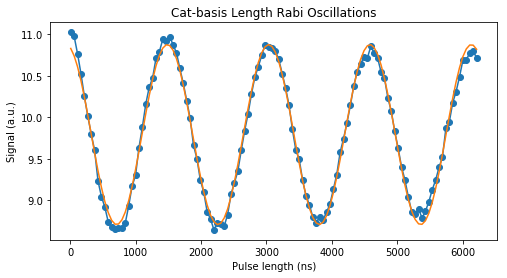

In [88]:
fig, ax = plt.subplots(figsize=(8,4))
ax.set_title("Cat-basis Length Rabi Oscillations")
ax.set_xlabel("Pulse length (ns)")
ax.set_ylabel("Signal (a.u.)")
x_pts = cycles2us(np.array(expt_pts))*1000
y_pts = np.array(results)
ax.plot(x_pts, y_pts, 'o-');

def sinRabi(x, a, T, phi, c):
    return a*np.sin(2*np.pi/T*x + phi) + c

guess = (1.2, 1500, 0, 5.5)
popt,pcov = curve_fit(sinRabi, x_pts, y_pts, p0=guess)
ax.plot(x_pts, sinRabi(x_pts, *popt))
print("Omega_x = %.2f MHz" % (1/popt[1]*1e3))

# dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_halfFlux_thruCav/'
# x_pts.tofile(dataFolder + 'lenRabi_sqz32k_qphase90_x_'+ dt_string + '.csv', sep=',', format='%10.3f')
# y_pts.tofile(dataFolder + 'lenRabi_sqz32k_qphase90_y_'+ dt_string + '.csv', sep=',', format='%10.3f')
# plt.savefig(dataFolder + 'lenRabi_sqz32k_qphase90_'   + dt_string + '.pdf', dpi=350)

### loop through phases, high rabi power

In [89]:
hw_cfg={"res_ch":cavity_ch, "qubit_ch":qubit_ch, "squeezing_ch":squeezing_ch,}
atten_cfg={"cavity_atten": cavity_atten, "qubit_atten": qubit_atten, "squeezing_atten": squeezing_atten,}

expt_cfg={"start":4, "step":3, "expts":120, "reps": 3000}
expt_pts=[expt_cfg["start"] + ii*expt_cfg["step"] for ii in range(expt_cfg["expts"])]

phase_expt_cfg={"phase_start":deg2reg(0), "phase_step":deg2reg(2), "phase_expts":91}
phase_expt_pts=[phase_expt_cfg["phase_start"] + ii*phase_expt_cfg["phase_step"] for ii in range(phase_expt_cfg["phase_expts"])]

squeezing2Rabi_wait = us2cycles(0.02)                                           # from finishing ramping up squeezing to starting Rabi
squeezing_sigma = us2cycles(0.16)                                               # 2sigma should be >> 1/2K
qubit_length = us2cycles(0.1)                                                   # dummy value, to be varied in the loop
qubit_sigma = us2cycles(0.04)                                                   # 80 ns ramp in Grimm
squeezing_length = qubit_length + squeezing2Rabi_wait + 4*qubit_sigma           # sqz is longer than qubit bc it starts before qubit
res_wait = squeezing_length + 4*squeezing_sigma

readout_cfg={
    "res_wait": res_wait,
    "readout_length": us2cycles(4.6),
    "res_phase": 0,
    "res_gain": 32000,
    "cavity_RF": cavity_RF/1e6, # just for displaying
    "f_res": cavity_IF, # [MHz], played by ADC
    "adc_trig_offset": adc_offset,
    "threshold": np.int(threshold),
    }
qubit_cfg={
    "qubit_sigma": qubit_sigma,
    "qubit_length": qubit_length,
    "qubit_phase": 0,
    "pi_gain": np.int(pi_gain), "pi2_gain":np.int(pi_gain/2),
    "qubit_gain": 10000,
    "qubit_RF": qubit_RF, # just for displaying
    "f_ge": qubit_IF, # [MHz], played by ADC
    "relax_delay":75,
    }
sqz_cfg={
    "squeezing_sigma": squeezing_sigma,
    "squeezing2Rabi_wait": 2*squeezing_sigma + squeezing2Rabi_wait,
    "squeezing_length": squeezing_length,  
    "squeezing_phase": deg2reg(0),
    "squeezing_gain": 32000,
    "squeezing_RF": squeezing_RF, # just for displaying
    "f_squeezing": squeezing_IF, # [MHz], played by ADC
    }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg, **sqz_cfg, **atten_cfg, **phase_expt_cfg} # combine configs
config

{'adc_trig_offset': 230,
 'cavity_RF': 11048.4,
 'cavity_atten': 0,
 'expts': 120,
 'f_ge': 700,
 'f_res': 1051.6,
 'f_squeezing': 2351.2,
 'phase_expts': 91,
 'phase_start': 0,
 'phase_step': 23860929,
 'pi2_gain': 1268,
 'pi_gain': 2536,
 'qubit_RF': 3051.2,
 'qubit_atten': 0,
 'qubit_ch': 6,
 'qubit_gain': 10000,
 'qubit_length': 38,
 'qubit_phase': 0,
 'qubit_sigma': 15,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 3000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'res_wait': 349,
 'squeezing2Rabi_wait': 129,
 'squeezing_RF': 6102.4,
 'squeezing_atten': 0,
 'squeezing_ch': 5,
 'squeezing_gain': 32000,
 'squeezing_length': 105,
 'squeezing_phase': 0,
 'squeezing_sigma': 61,
 'start': 4,
 'step': 3,
 'threshold': 0}

In [90]:
# loop through phases. CHECK TO SEE IF IT'S QUBIT PHASE OR SQUEEZING PHASE IN THE LOOP
results = np.zeros((len(phase_expt_pts), len(expt_pts)))

for jjj, qubit_phase in enumerate(phase_expt_pts):
    config["qubit_phase"] = qubit_phase
    print(jjj)
    
    for iii, length in enumerate(expt_pts): # already in cycles
        qubit_length=length
        squeezing_length = qubit_length + squeezing2Rabi_wait + 4*qubit_sigma
        res_wait = squeezing_length + 4*squeezing_sigma
        config["res_wait"] = res_wait
        config["qubit_length"] = qubit_length
        config["squeezing_length"] = squeezing_length

        catChevron = CatChevronProgram(config)
        avgi,avgq = catChevron.acquire(soc, threshold=None, load_pulses=True, progress=False,debug=False)
        results[jjj][iii]=avgi[0][0]
        
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90


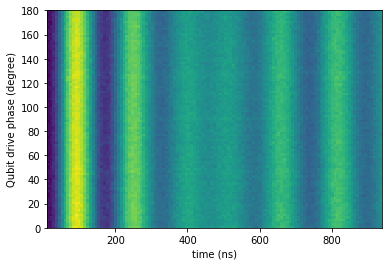

In [91]:
phase_deg = np.zeros(len(phase_expt_pts))
for i in range(len(phase_expt_pts)):
    phase_deg[i] = reg2deg(phase_expt_pts[i])
times = cycles2us(np.array(expt_pts))*1000

fig, ax = plt.subplots(figsize=(6,4))
ax.pcolormesh(times, phase_deg, results)
ax.set_xlabel("time (ns)")
ax.set_ylabel("Qubit drive phase (degree)")

dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_quarterFlux_thruCav/'
# plt.savefig(dataFolder + "lenRabi_sweepQubitPhase_Sqz5k_" + dt_string + ".pdf", dpi=350)
phase_deg.tofile(dataFolder + 'lenRabi_sweepQubitPhase_Sqz32k_Qubit10k_phase_' + dt_string + '.csv', sep=',', format='%10.3f')
times.tofile(dataFolder + 'lenRabi_sweepQubitPhase_Sqz32k_Qubit10k_time_' + dt_string + '.csv', sep=',', format='%10.3f')
results.tofile(dataFolder + 'lenRabi_sweepQubitPhase_Sqz32k_Qubit10k_results_' + dt_string + '.csv', sep=',', format='%10.3f')

### loop through phases, low rabi power

In [92]:
hw_cfg={"res_ch":cavity_ch, "qubit_ch":qubit_ch, "squeezing_ch":squeezing_ch,}
atten_cfg={"cavity_atten": cavity_atten, "qubit_atten": qubit_atten, "squeezing_atten": squeezing_atten,}

expt_cfg={"start":4, "step":20, "expts":120, "reps": 3000}
expt_pts=[expt_cfg["start"] + ii*expt_cfg["step"] for ii in range(expt_cfg["expts"])]

phase_expt_cfg={"phase_start":deg2reg(0), "phase_step":deg2reg(2), "phase_expts":91}
phase_expt_pts=[phase_expt_cfg["phase_start"] + ii*phase_expt_cfg["phase_step"] for ii in range(phase_expt_cfg["phase_expts"])]

squeezing2Rabi_wait = us2cycles(0.02)                                           # from finishing ramping up squeezing to starting Rabi
squeezing_sigma = us2cycles(0.16)                                               # 2sigma should be >> 1/2K
qubit_length = us2cycles(0.1)                                                   # dummy value, to be varied in the loop
qubit_sigma = us2cycles(0.04)                                                   # 80 ns ramp in Grimm
squeezing_length = qubit_length + squeezing2Rabi_wait + 4*qubit_sigma           # sqz is longer than qubit bc it starts before qubit
res_wait = squeezing_length + 4*squeezing_sigma

readout_cfg={
    "res_wait": res_wait,
    "readout_length": us2cycles(4.6),
    "res_phase": 0,
    "res_gain": 32000,
    "cavity_RF": cavity_RF/1e6, # just for displaying
    "f_res": cavity_IF, # [MHz], played by ADC
    "adc_trig_offset": adc_offset,
    "threshold": np.int(threshold),
    }
qubit_cfg={
    "qubit_sigma": qubit_sigma,
    "qubit_length": qubit_length,
    "qubit_phase": 0,
    "pi_gain": np.int(pi_gain), "pi2_gain":np.int(pi_gain/2),
    "qubit_gain": 1000,
    "qubit_RF": qubit_RF, # just for displaying
    "f_ge": qubit_IF, # [MHz], played by ADC
    "relax_delay":75,
    }
sqz_cfg={
    "squeezing_sigma": squeezing_sigma,
    "squeezing2Rabi_wait": 2*squeezing_sigma + squeezing2Rabi_wait,
    "squeezing_length": squeezing_length,  
    "squeezing_phase": deg2reg(0),
    "squeezing_gain": 32000,
    "squeezing_RF": squeezing_RF, # just for displaying
    "f_squeezing": squeezing_IF, # [MHz], played by ADC
    }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg, **sqz_cfg, **atten_cfg, **phase_expt_cfg} # combine configs
config

{'adc_trig_offset': 230,
 'cavity_RF': 11048.4,
 'cavity_atten': 0,
 'expts': 120,
 'f_ge': 700,
 'f_res': 1051.6,
 'f_squeezing': 2351.2,
 'phase_expts': 91,
 'phase_start': 0,
 'phase_step': 23860929,
 'pi2_gain': 1268,
 'pi_gain': 2536,
 'qubit_RF': 3051.2,
 'qubit_atten': 0,
 'qubit_ch': 6,
 'qubit_gain': 1000,
 'qubit_length': 38,
 'qubit_phase': 0,
 'qubit_sigma': 15,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 3000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'res_wait': 349,
 'squeezing2Rabi_wait': 129,
 'squeezing_RF': 6102.4,
 'squeezing_atten': 0,
 'squeezing_ch': 5,
 'squeezing_gain': 32000,
 'squeezing_length': 105,
 'squeezing_phase': 0,
 'squeezing_sigma': 61,
 'start': 4,
 'step': 20,
 'threshold': 0}

In [93]:
# loop through phases. CHECK TO SEE IF IT'S QUBIT PHASE OR SQUEEZING PHASE IN THE LOOP
results = np.zeros((len(phase_expt_pts), len(expt_pts)))

for jjj, qubit_phase in enumerate(phase_expt_pts):
    config["qubit_phase"] = qubit_phase
    print(jjj)
    
    for iii, length in enumerate(expt_pts): # already in cycles
        qubit_length=length
        squeezing_length = qubit_length + squeezing2Rabi_wait + 4*qubit_sigma
        res_wait = squeezing_length + 4*squeezing_sigma
        config["res_wait"] = res_wait
        config["qubit_length"] = qubit_length
        config["squeezing_length"] = squeezing_length

        catChevron = CatChevronProgram(config)
        avgi,avgq = catChevron.acquire(soc, threshold=None, load_pulses=True, progress=False,debug=False)
        results[jjj][iii]=avgi[0][0]
        
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90


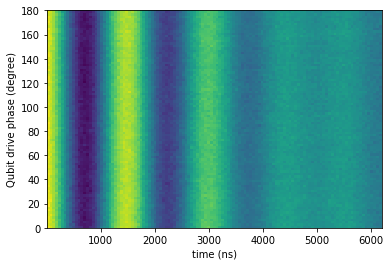

In [94]:
phase_deg = np.zeros(len(phase_expt_pts))
for i in range(len(phase_expt_pts)):
    phase_deg[i] = reg2deg(phase_expt_pts[i])
times = cycles2us(np.array(expt_pts))*1000

fig, ax = plt.subplots(figsize=(6,4))
ax.pcolormesh(times, phase_deg, results)
ax.set_xlabel("time (ns)")
ax.set_ylabel("Qubit drive phase (degree)")

dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_quarterFlux_thruCav/'
# plt.savefig(dataFolder + "lenRabi_sweepQubitPhase_Sqz5k_" + dt_string + ".pdf", dpi=350)
phase_deg.tofile(dataFolder + 'lenRabi_sweepQubitPhase_Sqz32k_Qubit1k_phase_' + dt_string + '.csv', sep=',', format='%10.3f')
times.tofile(dataFolder + 'lenRabi_sweepQubitPhase_Sqz32k_Qubit1k_time_' + dt_string + '.csv', sep=',', format='%10.3f')
results.tofile(dataFolder + 'lenRabi_sweepQubitPhase_Sqz32k_Qubit1k_results_' + dt_string + '.csv', sep=',', format='%10.3f')

### loop through squeezing gain

In [95]:
hw_cfg={"res_ch":cavity_ch, "qubit_ch":qubit_ch, "squeezing_ch":squeezing_ch,}
atten_cfg={"cavity_atten": cavity_atten, "qubit_atten": qubit_atten, "squeezing_atten": squeezing_atten,}

expt_cfg={"start":4, "step":20, "expts":120, "reps": 3000}
expt_pts=[expt_cfg["start"] + ii*expt_cfg["step"] for ii in range(expt_cfg["expts"])]

sqzgain_expt_cfg={"sqzgain_start":0, "sqzgain_step":1000, "sqzgain_expts":65}
sqzgain_expt_pts=[sqzgain_expt_cfg["sqzgain_start"] + ii*sqzgain_expt_cfg["sqzgain_step"] for ii in range(sqzgain_expt_cfg["sqzgain_expts"])]

squeezing2Rabi_wait = us2cycles(0.02)                                           # from finishing ramping up squeezing to starting Rabi
squeezing_sigma = us2cycles(0.16)                                               # 2sigma should be >> 1/2K
qubit_length = us2cycles(0.1)                                                   # dummy value, to be varied in the loop
qubit_sigma = us2cycles(0.04)                                                   # 80 ns ramp in Grimm
squeezing_length = qubit_length + squeezing2Rabi_wait + 4*qubit_sigma           # sqz is longer than qubit bc it starts before qubit
res_wait = squeezing_length + 4*squeezing_sigma

readout_cfg={
    "res_wait": res_wait,
    "readout_length": us2cycles(4.6),
    "res_phase": 0,
    "res_gain": 32000,
    "cavity_RF": cavity_RF/1e6, # just for displaying
    "f_res": cavity_IF, # [MHz], played by ADC
    "adc_trig_offset": adc_offset,
    "threshold": np.int(threshold),
    }
qubit_cfg={
    "qubit_sigma": qubit_sigma,
    "qubit_length": qubit_length,
    "qubit_phase": 0,
    "pi_gain": np.int(pi_gain), "pi2_gain":np.int(pi_gain/2),
    "qubit_gain": 1000,
    "qubit_RF": qubit_RF, # just for displaying
    "f_ge": qubit_IF, # [MHz], played by ADC
    "relax_delay":75,
    }
sqz_cfg={
    "squeezing_sigma": squeezing_sigma,
    "squeezing2Rabi_wait": 2*squeezing_sigma + squeezing2Rabi_wait,
    "squeezing_length": squeezing_length,  
    "squeezing_phase": 0,
    "squeezing_gain": 0*32000,
    "squeezing_RF": squeezing_RF, # just for displaying
    "f_squeezing": squeezing_IF, # [MHz], played by ADC
    }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg, **sqz_cfg, **atten_cfg, **sqzgain_expt_cfg} # combine configs
config

{'adc_trig_offset': 230,
 'cavity_RF': 11048.4,
 'cavity_atten': 0,
 'expts': 120,
 'f_ge': 700,
 'f_res': 1051.6,
 'f_squeezing': 2351.2,
 'pi2_gain': 1268,
 'pi_gain': 2536,
 'qubit_RF': 3051.2,
 'qubit_atten': 0,
 'qubit_ch': 6,
 'qubit_gain': 1000,
 'qubit_length': 38,
 'qubit_phase': 0,
 'qubit_sigma': 15,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 3000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'res_wait': 349,
 'squeezing2Rabi_wait': 129,
 'squeezing_RF': 6102.4,
 'squeezing_atten': 0,
 'squeezing_ch': 5,
 'squeezing_gain': 0,
 'squeezing_length': 105,
 'squeezing_phase': 0,
 'squeezing_sigma': 61,
 'sqzgain_expts': 65,
 'sqzgain_start': 0,
 'sqzgain_step': 1000,
 'start': 4,
 'step': 20,
 'threshold': 0}

In [96]:
# loop through sqz gain
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
results = np.zeros((len(sqzgain_expt_pts), len(expt_pts)))

for jjj, squeezing_gain in enumerate(sqzgain_expt_pts):
    config["squeezing_gain"] = squeezing_gain
    print(jjj)
    
    for iii, length in enumerate(expt_pts): # already in cycles
        qubit_length=length
        squeezing_length = qubit_length + squeezing2Rabi_wait + 4*qubit_sigma
        res_wait = squeezing_length + 4*squeezing_sigma
        config["res_wait"] = res_wait
        config["qubit_length"] = qubit_length
        config["squeezing_length"] = squeezing_length

        catChevron = CatChevronProgram(config)
        avgi,avgq = catChevron.acquire(soc, threshold=None, load_pulses=True, progress=False,debug=False)
        results[jjj][iii]=avgi[0][0]

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64


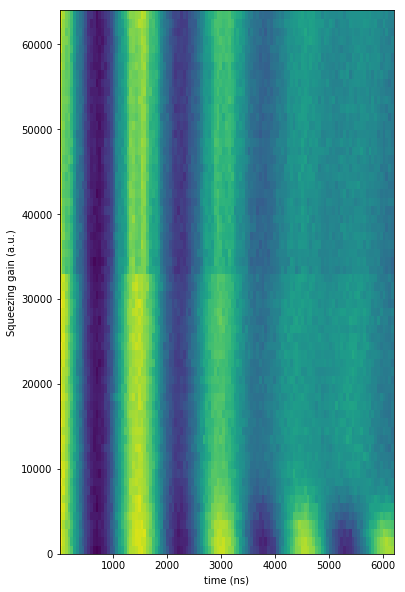

In [97]:
times = cycles2us(np.array(expt_pts))*1000

fig, ax = plt.subplots(figsize=(6,10))
ax.pcolormesh(times, sqzgain_expt_pts, results)
ax.set_xlabel("time (ns)")
ax.set_ylabel("Squeezing gain (a.u.)")
sqzgain_expt_pts = np.array(sqzgain_expt_pts)

dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_quarterFlux_thruCav/'
# plt.savefig(dataFolder + "lenRabi_sweepSqzGain_" + dt_string + ".pdf", dpi=350)
sqzgain_expt_pts.tofile(dataFolder + 'lenRabi_sweepSqzGain_sqzgain_Qubit1k_' + dt_string + '.csv', sep=',', format='%10.3f')
times.tofile(dataFolder + 'lenRabi_sweepSqzGain_Qubit1k_time_' + dt_string + '.csv', sep=',', format='%10.3f')
results.tofile(dataFolder + 'lenRabi_sweepSqzGain_Qubit1k_results_' + dt_string + '.csv', sep=',', format='%10.3f')

# T2 RAMSEY WITH SQUEEZING

In [122]:
class RamseySqueezingProgram(AveragerProgram):     
    def initialize(self):
        cfg=self.cfg
        
        f_res=freq2reg(adcfreq(cfg["f_res"]))            # conver f_res to dac register value
        f_ge=freq2reg(cfg["f_ge"])
        f_sqz=freq2reg(cfg["f_squeezing"])
        
        cfg["adc_lengths"]=[cfg["readout_length"]]*2   #copy over adc acquisition parameters
        cfg["adc_freqs"]=[adcfreq(cfg["f_res"])]*2
        
        # add qubit and readout pulses to respective channels
        self.add_pulse(ch=cfg["qubit_ch"], name="qubit", style="arb", idata=gauss(mu=cfg["sigma"]*16*4/2,si=cfg["sigma"]*16, length=4*cfg["sigma"]*16, maxv=2**15-1))
        self.add_pulse(ch=cfg["res_ch"], name="measure", style="const", length=cfg["readout_length"])
        self.add_pulse(ch=cfg["squeezing_ch"], name="squeezing", style="flat_top", length=cfg["wait"], 
                       idata=gauss(mu=cfg["squeezing_sigma"]*16*4/2,si=cfg["squeezing_sigma"]*16,length=4*cfg["squeezing_sigma"]*16,maxv=2**15-1))               
        
        # pre-initialize pulses
        self.pulse(ch=cfg["qubit_ch"], name="qubit", phase=0, freq=f_ge, gain=cfg["pi2_gain"], play=False)
        self.pulse(ch=cfg["res_ch"], name="measure", freq=f_res, phase=cfg['res_phase'], gain=cfg["res_gain"], play=False)
        self.pulse(ch=cfg["squeezing_ch"], name="squeezing", phase=cfg['squeezing_phase'], 
                   freq=f_sqz, gain=cfg["squeezing_gain"], play=False)
        
        self.sync_all(us2cycles(0.2))
    
    def body(self):
        cfg=self.cfg
        self.pulse(ch=cfg["qubit_ch"], phase=0, play=True)                              # play pi/2 pulse
        self.sync_all()
        self.pulse(ch=cfg["squeezing_ch"], name="squeezing", play=True)                 # play squeezing pulse
        self.sync_all()
        self.pulse(ch=cfg["qubit_ch"], phase=cfg["qubit_phase"], play=True)             # play pi/2 pulse
        self.sync_all(us2cycles(0.05))
        self.trigger_adc(adc1=1, adc2=1, adc_trig_offset=cfg["adc_trig_offset"])        # trigger measurement
        self.pulse(ch=cfg["res_ch"], name="measure", play=True)                         # play measurement pulse
        self.sync_all(us2cycles(cfg["relax_delay"]))                                    # wait for qubit to relax

In [123]:
adc_offset = 230
cavity_RF = 11.0472e9
cavity_LO = 12.1e9
cavity_IF = (cavity_LO-cavity_RF)/1e6
cavity_atten = 5

detuning = 0.5e6
qubit_LO = 3.76615e9 + detuning    # Hz
qubit_IF = 700       # MHz
qubit_RF = qubit_LO/1e6 - qubit_IF # MHz
qubit_atten = 0

squeezing_RF = 2*(qubit_RF - detuning/1e6)
squeezing_LO = qubit_LO # use the same LO for phase coherence
squeezing_IF = squeezing_RF - squeezing_LO/1e6
squeezing_atten = 0

setatten(atten=qubit_atten, serial=qubit_SN) # Qubit
setatten(atten=cavity_atten, serial=cavity_SN) # Cavity
setatten(atten=squeezing_atten, serial=squeezing_SN) # Squeezing
setsignalcore(module=cavity_LOmod,output=1,power=13,freq=cavity_LO) # Cavity LO = 12.1 GHz fixed
setsignalcore(module=qubit_LOmod,output=1,power=7,freq=qubit_LO) # Qubit LO is varied

print()
print(squeezing_IF)
print(squeezing_LO)
print(squeezing_RF)

Microsoft Windows [Version 10.0.19042.1415]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27783
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device 1 Serial number: 27783
Device was found to be device 1
Get attenuation: 0.0
Set attenuation: 0.0
Device 2 Serial number: 27712
Device 3 Serial number: 0
Device 4 Serial number: 0

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>Microsoft Windows [Version 10.0.19042.1415]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 5 27782
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device was found to be devi

In [129]:
hw_cfg={"res_ch":cavity_ch, "qubit_ch":qubit_ch, "squeezing_ch":squeezing_ch,}
atten_cfg={"cavity_atten": cavity_atten, "qubit_atten": qubit_atten, "squeezing_atten": squeezing_atten,}

squeezing_sigma =  us2cycles(0.16)     # 2sigma should be >> 1/2K

readout_cfg={
    "res_wait": res_wait,
    "readout_length": us2cycles(4.6),
    "res_phase": 0,
    "res_gain": 32000,
    "cavity_RF": cavity_RF/1e6, # just for displaying
    "f_res": cavity_IF, # [MHz], played by ADC
    "adc_trig_offset": adc_offset,
    "threshold": np.int(threshold),
    }
qubit_cfg={
    "relax_delay":75,
    "qubit_RF": qubit_RF,
    "f_ge": qubit_IF, # [MHz]
    "sigma":us2cycles(0.180),
    "pi_gain":np.int(pi_gain),
    "pi2_gain":np.int(pi_gain/2),
    "qubit_phase": deg2reg(0),
    }
sqz_cfg={
    "squeezing_sigma": squeezing_sigma, 
    "squeezing_phase": deg2reg(0),
    "squeezing_gain": 32000,
    "squeezing_RF": squeezing_RF, # just for displaying
    "f_squeezing": squeezing_IF, # [MHz], played by ADC
    }
timestep = 50; estDetun = 0.12
expt_cfg={"start":us2cycles(0), "step": timestep, 
          "phase_step": 360*cycles2us(timestep)*estDetun, "expts":160,
          "reps": 5000, "rounds": 1
       }
expt_pts = [expt_cfg["start"] + ii*expt_cfg["step"] for ii in range(expt_cfg["expts"])]
expt_pts = np.array(expt_pts)

phase_pts_deg =np.mod([0 + ii*expt_cfg["phase_step"] for ii in range(expt_cfg["expts"])], 360)
phase_pts = [deg2reg(phase_iii) for phase_iii in phase_pts_deg]
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg,**atten_cfg, **sqz_cfg} #combine configs
config

{'adc_trig_offset': 230,
 'cavity_RF': 11047.2,
 'cavity_atten': 5,
 'expts': 160,
 'f_ge': 700,
 'f_res': 1052.8,
 'f_squeezing': 2365.65,
 'phase_step': 5.625,
 'pi2_gain': 3140,
 'pi_gain': 6280,
 'qubit_RF': 3066.65,
 'qubit_atten': 0,
 'qubit_ch': 6,
 'qubit_phase': 0,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 5000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'res_wait': 672,
 'rounds': 1,
 'sigma': 69,
 'squeezing_RF': 6132.3,
 'squeezing_atten': 0,
 'squeezing_ch': 5,
 'squeezing_gain': 32000,
 'squeezing_phase': 0,
 'squeezing_sigma': 61,
 'start': 0,
 'step': 50,
 'threshold': -14}

In [130]:
# single Rabi length
results=[]
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
jjj = 0
for wait in tqdm(expt_pts): # already in cycles
    config["wait"] = np.int(wait)
    config["qubit_phase"] = phase_pts[jjj]
    T2R = RamseySqueezingProgram(config)
    avgi,avgq = T2R.acquire(soc, threshold=None, load_pulses=True, progress=False,debug=False)
    results.append(avgi[0][0])
    jjj = jjj+1

100%|██████████| 160/160 [02:26<00:00,  1.03it/s]


Delta_f = 0.39 MHz
[ 1.65784124  2.7749877   2.53873903  0.99496056 27.1390071 ]


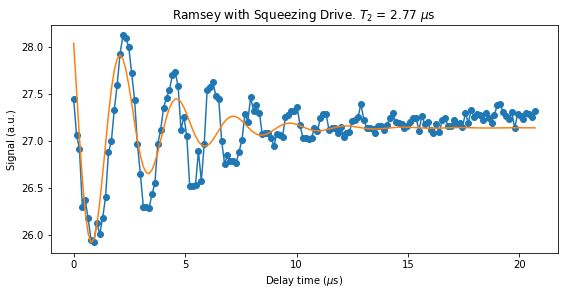

In [132]:
x = cycles2us(expt_pts); y = results

fig = plt.subplots(figsize=(8,4))
ax = plt.subplot(111, xlabel="Delay time ($\mu$s)", ylabel="Signal (a.u.)")
ax.plot(x,y,'o-')

def T2Ramsey(x, a, T2, T, phi, c):
    return a*np.exp(-x/T2)*np.cos(2*np.pi*x/T + phi) + c

guess = (1, 5, 3, 0, -10.5)
popt,pcov = curve_fit(T2Ramsey, x, y, p0=guess)
ax.plot(x, T2Ramsey(x, *popt))
plt.tight_layout()
ax.set_title("Ramsey with Squeezing Drive. $T_2$ = %.2f $\mu$s" % popt[1])

print("Delta_f = %.2f MHz" % (1/popt[2]))
print(popt)

x = np.array(x); y = np.array(y)

dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_quarterFlux_thruCav/'
x.tofile(dataFolder + 'T2R_sqz_32k_x_'+ dt_string + '_sqz.csv', sep=',', format='%10.3f')
y.tofile(dataFolder + 'T2R_sqz_32k_y_'+ dt_string + '_sqz.csv', sep=',', format='%10.3f')
plt.savefig(dataFolder + "T2R_sqz_32k_"   + dt_string + '_sqz.pdf', dpi=350)

# Test T2 Ramsey with software loop, no squeezing (not frequently used)

In [111]:
class RamseyProgramAvg(AveragerProgram):     
    def initialize(self):
        cfg=self.cfg
        
        f_res=freq2reg(adcfreq(cfg["f_res"]))            # conver f_res to dac register value
        f_ge=freq2reg(cfg["f_ge"])
        
        self.cfg["adc_lengths"]=[self.cfg["readout_length"]]*2   #copy over adc acquisition parameters
        self.cfg["adc_freqs"]=[adcfreq(cfg["f_res"])]*2
        
        # add qubit and readout pulses to respective channels
        self.add_pulse(ch=self.cfg["qubit_ch"], name="qubit", style="arb", idata=gauss(mu=cfg["sigma"]*16*4/2,si=cfg["sigma"]*16, length=4*cfg["sigma"]*16, maxv=2**15-1))
        self.add_pulse(ch=self.cfg["res_ch"], name="measure", style="const", length=self.cfg["readout_length"])
               
        # pre-initialize pulses
        self.pulse(ch=cfg["qubit_ch"], name="qubit", phase=0, freq=f_ge, gain=cfg["pi2_gain"], play=False)
        self.pulse(ch=cfg["res_ch"], name="measure", freq=f_res, phase=cfg['res_phase'], gain=cfg["res_gain"], play=False)
    
        self.sync_all(us2cycles(0.2))
    
    def body(self):
        cfg=self.cfg
        self.pulse(ch=self.cfg["qubit_ch"], phase=0, play=True)                              # play pi/2 pulse
        self.sync_all()
        self.wait_ch(ch=cfg["qubit_ch"], wait_t=cfg["wait"])                                # wait before next pi/2 pulse 
        self.pulse(ch=self.cfg["qubit_ch"], phase=cfg["qubit_phase"], play=True)               # play pi/2 pulse
        self.sync_all(us2cycles(0.05))
        self.trigger_adc(adc1=1, adc2=1, adc_trig_offset=self.cfg["adc_trig_offset"])       # trigger measurement
        self.pulse(ch=self.cfg["res_ch"], name="measure", play=True)                        # play measurement pulse
        self.sync_all(us2cycles(self.cfg["relax_delay"]))                                   # wait for qubit to relax

In [112]:
hw_cfg={"res_ch":cavity_ch,
        "qubit_ch":qubit_ch,
       }
readout_cfg={
    "readout_length":us2cycles(4.6), # [Clock ticks]
    "f_res": cavity_IF, # [MHz]
    "res_phase": 0,
    "adc_trig_offset": adc_offset, # [Clock ticks]
    "res_gain":32000,
    "cavity_RF": cavity_RF/1e6,
    "threshold": np.int(threshold),
    }
qubit_cfg={
    "relax_delay":75,
    "qubit_RF": qubit_RF,
    "f_ge": qubit_IF, # [MHz]
    "sigma":us2cycles(0.180),
    "pi_gain":np.int(pi_gain),
    "pi2_gain":np.int(pi_gain/2)
    }

atten_cfg={
    "cavity_atten": cavity_atten,
    "qubit_atten": qubit_atten,
    "squeezing_atten": squeezing_atten,
    "squeezing_RF": squeezing_RF,
    }
timestep = 30; estDetun = 0.12
expt_cfg={"start":us2cycles(0), "step": timestep, 
          "phase_step": 360*cycles2us(timestep)*estDetun, "expts":250,
          "reps": 2000, "rounds": 1
       }
expt_pts = [expt_cfg["start"] + ii*expt_cfg["step"] for ii in range(expt_cfg["expts"])]
phase_pts_deg =np.mod([0 + ii*expt_cfg["phase_step"] for ii in range(expt_cfg["expts"])], 360)
phase_pts = [deg2reg(phase_iii) for phase_iii in phase_pts_deg]

config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg,**atten_cfg} #combine configs
config

{'adc_trig_offset': 230,
 'cavity_RF': 11077.0,
 'cavity_atten': 15,
 'expts': 250,
 'f_ge': 700,
 'f_res': 1023.0,
 'phase_step': 3.375,
 'pi2_gain': 2461,
 'pi_gain': 4923,
 'qubit_RF': 3046.5,
 'qubit_atten': 0,
 'qubit_ch': 6,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 2000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'rounds': 1,
 'sigma': 69,
 'squeezing_RF': 6093.0,
 'squeezing_atten': 10,
 'start': 0,
 'step': 30,
 'threshold': -13}

In [113]:
# single Rabi length
results=[]
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
jjj = 0
for wait in tqdm(expt_pts): # already in cycles
    config["wait"] = wait
    config["qubit_phase"] = phase_pts[jjj]

    T2R_Avg = RamseyProgramAvg(config)
    avgi,avgq = T2R_Avg.acquire(soc, threshold=None, load_pulses=True, progress=False,debug=False)
    results.append(avgi[0][0])
    jjj = jjj+1

100%|██████████| 250/250 [01:46<00:00,  2.24it/s]


Delta_f = 0.23 MHz
[-0.25367023  5.75007041  4.39388862  6.67167392 -8.91035268]


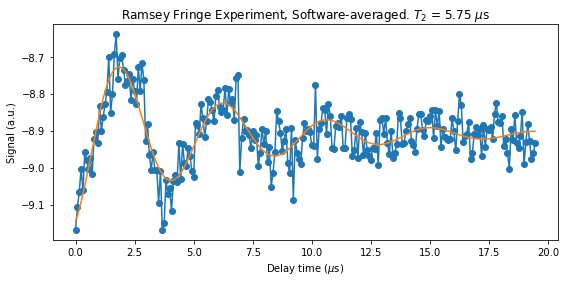

In [114]:
x = cycles2us(np.array(expt_pts)); y = results

fig = plt.subplots(figsize=(8,4))
ax = plt.subplot(111, title="Ramsey Fringe Experiment, Software-averaged", xlabel="Delay time ($\mu$s)", ylabel="Signal (a.u.)")
ax.plot(x,y,'o-')

def T2Ramsey(x, a, T2, T, phi, c):
    return a*np.exp(-x/T2)*np.cos(2*np.pi*x/T + phi) + c
def T2RamseyExpo(x, a, T2, c):
    return a*np.exp(-x/T2) + c

guess = (0.5, 5, 2, 0, -4.2)
popt,pcov = curve_fit(T2Ramsey, x, y, p0=guess)
ax.plot(x, T2Ramsey(x, *popt))

# guess = (0.5, 0.25, -4.2)
# popt,pcov = curve_fit(T2RamseyExpo, x, y, p0=guess)
# ax.plot(x, T2RamseyExpo(x, *popt))

plt.tight_layout()
ax.set_title("Ramsey Fringe Experiment, Software-averaged. $T_2$ = %.2f $\mu$s" % popt[1])

print("Delta_f = %.2f MHz" % (1/popt[2]))
print(popt)

x = np.array(x); y = np.array(y)
# x.tofile('T2R_x_'+str(countIdx)+dt_string+'0p33V_softAvg.csv', sep=',', format='%10.3f')
# y.tofile('T2R_y_'+str(countIdx)+dt_string+'0p33V_softAvg.csv', sep=',', format='%10.3f')
# plt.savefig("T2R_"+str(countIdx)+dt_string+"0p33V_softAvg.pdf", dpi=350)

# T2R fully under squeezing

In [133]:
class T2RFullSqueezingProgram(AveragerProgram):
    def initialize(self):
        cfg=self.cfg
        
        f_res=freq2reg(adcfreq(cfg["f_res"]))            # conver f_res to dac register value
        f_ge=freq2reg(cfg["f_ge"])
        f_sqz=freq2reg(cfg["f_squeezing"])

        cfg["adc_lengths"]=[cfg["readout_length"]]*2     # add length of adc acquisition to config
        cfg["adc_freqs"]=[adcfreq(cfg["f_res"])]*2       # add frequency of adc ddc to config
        
        # add pulses to respective channels
        self.add_pulse(ch=self.cfg["qubit_ch"], name="qubit", style="arb", 
                       idata=gauss(mu=cfg["qubit_sigma"]*16*4/2,si=cfg["qubit_sigma"]*16, length=4*cfg["qubit_sigma"]*16, maxv=2**15-1))
        self.add_pulse(ch=cfg["res_ch"], name="measure",style="const", length=cfg["readout_length"])
        self.add_pulse(ch=cfg["squeezing_ch"], name="squeezing", style="flat_top", length=cfg["squeezing_length"], 
                       idata=gauss(mu=cfg["squeezing_sigma"]*16*4/2,si=cfg["squeezing_sigma"]*16,length=4*cfg["squeezing_sigma"]*16,maxv=2**15-1))               
        
        # pre-initialize pulses
        self.pulse(ch=cfg["qubit_ch"], name="qubit", phase=0, freq=f_ge, gain=cfg["pi2_gain"], play=False)
        self.pulse(ch=cfg["res_ch"], name="measure", freq=f_res, phase=cfg['res_phase'], gain=cfg["res_gain"], play=False)
        self.pulse(ch=cfg["squeezing_ch"], name="squeezing", phase=cfg['squeezing_phase'],
                   freq=f_sqz, gain=cfg["squeezing_gain"], play=False)
               
        self.synci(200)
        
    def body(self):
        cfg=self.cfg
        self.pulse(ch=cfg["squeezing_ch"], name="squeezing", play=True)                # play squeezing pulse
        self.wait_ch(ch=cfg["qubit_ch"], wait_t=cfg["squeezing2Rabi_wait"])            # wait before Ramsey 
        self.pulse(ch=cfg["qubit_ch"], phase=0, play=True)                             # play pi/2 pulse
        self.wait_ch(ch=cfg["qubit_ch"], wait_t=cfg["wait"])                           # wait before next pi/2 pulse 
        self.pulse(ch=self.cfg["qubit_ch"], phase=cfg["qubit_phase"], play=True)       # play pi/2 pulse
        
        self.sync_all(us2cycles(0))
        self.trigger_adc(adc1=1, adc2=1, adc_trig_offset=self.cfg["adc_trig_offset"])  # trigger measurement
        self.pulse(ch=cfg["res_ch"], play=True)                                        # play measurement pulse
        self.sync_all(us2cycles(self.cfg["relax_delay"]))                              # wait for qubit to relax

In [138]:
adc_offset = 230
cavity_RF = 11.0472e9
cavity_LO = 12.1e9
cavity_IF = (cavity_LO-cavity_RF)/1e6
cavity_atten = 5

detuning = 1e6
qubit_LO = 3.76615e9 + detuning    # Hz
qubit_IF = 700                     # MHz
qubit_RF = qubit_LO/1e6 - qubit_IF # MHz
qubit_atten = 0

squeezing_RF = 2*(qubit_RF - detuning/1e6)
squeezing_LO = qubit_LO # use the same LO for phase coherence
squeezing_IF = squeezing_RF - squeezing_LO/1e6
squeezing_atten = 0

setatten(atten=qubit_atten, serial=qubit_SN) # Qubit
setatten(atten=cavity_atten, serial=cavity_SN) # Cavity
setatten(atten=squeezing_atten, serial=squeezing_SN) # Squeezing
setsignalcore(module=cavity_LOmod,output=1,power=13,freq=cavity_LO) # Cavity LO = 12.1 GHz fixed
setsignalcore(module=qubit_LOmod,output=1,power=7,freq=qubit_LO) # Qubit LO is varied

print()
print(squeezing_IF)
print(squeezing_LO)
print(squeezing_RF)

Microsoft Windows [Version 10.0.19042.1415]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27783
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device 1 Serial number: 27783
Device was found to be device 1
Get attenuation: 0.0
Set attenuation: 0.0
Device 2 Serial number: 27712
Device 3 Serial number: 0
Device 4 Serial number: 0

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>Microsoft Windows [Version 10.0.19042.1415]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 5 27782
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device was found to be devi

In [143]:
hw_cfg={"res_ch":cavity_ch, "qubit_ch":qubit_ch, "squeezing_ch":squeezing_ch,}
atten_cfg={"cavity_atten": cavity_atten, "qubit_atten": qubit_atten, "squeezing_atten": squeezing_atten,}

squeezing2Rabi_wait =  us2cycles(0.02)                                           # from finishing ramping up squeezing to starting Rabi
squeezing_sigma =  us2cycles(0.16)                                               # 2sigma should be >> 1/2K
qubit_sigma = us2cycles(0.18)                                                    # same value for T2 experiments

readout_cfg={
    "res_wait": res_wait,
    "readout_length": us2cycles(4.6),
    "res_phase": 0,
    "res_gain": 32000,
    "cavity_RF": cavity_RF/1e6, # just for displaying
    "f_res": cavity_IF, # [MHz], played by ADC
    "adc_trig_offset": adc_offset,
    "threshold": np.int(threshold),
    }
qubit_cfg={
    "qubit_sigma": qubit_sigma,
    "qubit_length": qubit_length,
    "qubit_phase": deg2reg(0),
    "pi_gain": np.int(pi_gain), "pi2_gain":np.int(pi_gain/2),
    "qubit_RF": qubit_RF, # just for displaying
    "f_ge": qubit_IF, # [MHz], played by ADC
    "relax_delay":75,
    }
sqz_cfg={
    "squeezing_sigma": squeezing_sigma,
    "squeezing2Rabi_wait": 2*squeezing_sigma + squeezing2Rabi_wait,
    "squeezing_length": squeezing_length,  
    "squeezing_phase": deg2reg(0),
    "squeezing_gain": 32000,
    "squeezing_RF": squeezing_RF, # just for displaying
    "f_squeezing": squeezing_IF, # [MHz], played by ADC
    }

timestep = 60; estDetun = 0.5
expt_cfg={"start":us2cycles(0), "step": timestep, 
          "phase_step": 360*cycles2us(timestep)*estDetun, "expts":140,
          "reps": 5000, "rounds": 1
       }
expt_pts = [expt_cfg["start"] + ii*expt_cfg["step"] for ii in range(expt_cfg["expts"])]

phase_pts_deg =np.mod([0 + ii*expt_cfg["phase_step"] for ii in range(expt_cfg["expts"])], 360)
phase_pts = [deg2reg(phase_iii) for phase_iii in phase_pts_deg]

config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg,**atten_cfg, **sqz_cfg} #combine configs
config

{'adc_trig_offset': 230,
 'cavity_RF': 11047.2,
 'cavity_atten': 5,
 'expts': 140,
 'f_ge': 700,
 'f_res': 1052.8,
 'f_squeezing': 2365.15,
 'phase_step': 28.125,
 'pi2_gain': 3140,
 'pi_gain': 6280,
 'qubit_RF': 3067.15,
 'qubit_atten': 0,
 'qubit_ch': 6,
 'qubit_length': 361,
 'qubit_phase': 0,
 'qubit_sigma': 69,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 5000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'res_wait': 672,
 'rounds': 1,
 'squeezing2Rabi_wait': 129,
 'squeezing_RF': 6132.3,
 'squeezing_atten': 0,
 'squeezing_ch': 5,
 'squeezing_gain': 32000,
 'squeezing_length': 428,
 'squeezing_phase': 0,
 'squeezing_sigma': 61,
 'start': 0,
 'step': 60,
 'threshold': -14}

In [144]:
results=[]
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
jjj = 0
for wait in tqdm(expt_pts): # already in cycles
    config["wait"] = wait
    config["squeezing_length"] = squeezing2Rabi_wait + 8*qubit_sigma + wait
    config["qubit_phase"] = phase_pts[jjj]

    T2R_Avg = T2RFullSqueezingProgram(config)
    avgi,avgq = T2R_Avg.acquire(soc, threshold=None, load_pulses=True, progress=False,debug=False)
    results.append(avgi[0][0])
    jjj = jjj+1

100%|██████████| 140/140 [02:08<00:00,  1.03it/s]


Delta_f = 0.57 MHz
[-1.40481254  4.92111505  1.76949089 11.69182832 27.52695623]


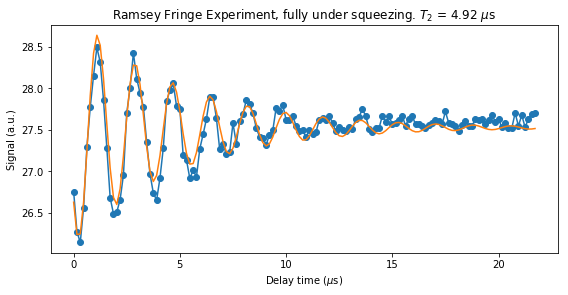

In [146]:
x = cycles2us(np.array(expt_pts)); y = results

fig = plt.subplots(figsize=(8,4))
ax = plt.subplot(111, xlabel="Delay time ($\mu$s)", ylabel="Signal (a.u.)")
ax.plot(x,y,'o-')

def T2Ramsey(x, a, T2, T, phi, c):
    return a*np.exp(-x/T2)*np.cos(2*np.pi*x/T + phi) + c
def T2RamseyExpo(x, a, T2, c):
    return a*np.exp(-x/T2) + c

guess = (0.5, 0.25, 0.5, 0, -4.2)
popt,pcov = curve_fit(T2Ramsey, x, y, p0=guess)
ax.plot(x, T2Ramsey(x, *popt))

# guess = (0.5, 0.25, -4.2)
# popt,pcov = curve_fit(T2RamseyExpo, x, y, p0=guess)
# ax.plot(x, T2RamseyExpo(x, *popt))

plt.tight_layout()
ax.set_title("Ramsey Fringe Experiment, fully under squeezing. $T_2$ = %.2f $\mu$s" % popt[1])

print("Delta_f = %.2f MHz" % (1/popt[2]))
print(popt)

x = np.array(x); y = np.array(y)

dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_halfFlux_thruCL/'
x.tofile(dataFolder + 'T2R_fullySqz_32k_x_'+ dt_string + '.csv', sep=',', format='%10.3f')
y.tofile(dataFolder + 'T2R_fullySqz_32k_y_'+ dt_string + '.csv', sep=',', format='%10.3f')
plt.savefig(dataFolder + "T2R_fullySqz_32k_"   + dt_string + '.pdf', dpi=350)

### test scheduling by loopback

In [8]:
class T2RFullSqueezingLoopbackProgram(AveragerProgram):
    def __init__(self,cfg):
        AveragerProgram.__init__(self,cfg)
        
    def initialize(self):
        cfg=self.cfg
        
        f_ge=freq2reg(cfg["f_ge"])
        f_sqz=freq2reg(cfg["f_squeezing"])

        cfg["adc_lengths"]=[cfg["readout_length"]]*2     # add length of adc acquisition to config
        cfg["adc_freqs"]=[adcfreq(cfg["f_ge"])]*2       # add frequency of adc ddc to config
        
        # add pulses to respective channels
        self.add_pulse(ch=self.cfg["qubit_ch"], name="qubit", style="arb", 
                       idata=gauss(mu=cfg["qubit_sigma"]*16*4/2,si=cfg["qubit_sigma"]*16, length=4*cfg["qubit_sigma"]*16, maxv=2**15-1))
        self.add_pulse(ch=cfg["squeezing_ch"], name="squeezing", style="flat_top", length=cfg["squeezing_length"], 
                       idata=gauss(mu=cfg["squeezing_sigma"]*16*4/2,si=cfg["squeezing_sigma"]*16,length=4*cfg["squeezing_sigma"]*16,maxv=2**15-1))               
        
        # pre-initialize pulses
        self.pulse(ch=cfg["qubit_ch"], name="qubit", phase=0, freq=f_ge, gain=cfg["pi2_gain"], play=False)
        self.pulse(ch=cfg["squeezing_ch"], name="squeezing", phase=cfg['squeezing_phase'],
                   freq=f_sqz, gain=cfg["squeezing_gain"], play=False)
               
        self.synci(200)
        
    def body(self):
        cfg=self.cfg
        self.trigger_adc(adc1=1, adc2=1, adc_trig_offset=self.cfg["adc_trig_offset"])  # trigger measurement
        self.pulse(ch=cfg["squeezing_ch"], name="squeezing", play=True)                # play squeezing pulse
        self.wait_ch(ch=cfg["qubit_ch"], wait_t=cfg["squeezing2Rabi_wait"])            # wait before Ramsey 
        self.pulse(ch=cfg["qubit_ch"], phase=0, play=True)                             # play pi/2 pulse
        self.wait_ch(ch=cfg["qubit_ch"], wait_t=cfg["wait"])                           # wait before next pi/2 pulse 
        self.pulse(ch=self.cfg["qubit_ch"], phase=cfg["qubit_phase"], play=True)       # play pi/2 pulse
        self.sync_all(us2cycles(self.cfg["relax_delay"]))                              # wait for qubit to relax

In [20]:
squeezing2Rabi_wait = us2cycles(0.02) # delay from finishing ramping up squeezing to starting Rabi
squeezing_sigma = us2cycles(0.16)
qubit_sigma = us2cycles(0.04)
wait = us2cycles(0.5)

config={"adc_trig_offset": 150,
        "relax_delay":0,
        "reps":1,
        "soft_avgs":100,
        "readout_length":1000, 
        
        "f_ge":1000, # IF in MHz
        "qubit_ch":4,
        "qubit_sigma": qubit_sigma,
        "qubit_phase":0, #np.mod(360*cycles2us(20)*0.47*200,360),
        "qubit_gain":3000,
        "pi2_gain":20000,
        "wait":wait,
        
        "f_squeezing":1000, # IF in MHz
        "squeezing_ch":5,
        "squeezing_sigma": squeezing_sigma,
        "squeezing2Rabi_wait": 2*squeezing_sigma + squeezing2Rabi_wait,
        "squeezing_length": squeezing2Rabi_wait + 8*qubit_sigma + wait,
        "squeezing_phase": 0,
        "squeezing_gain": 30000,
       }
config

{'adc_trig_offset': 150,
 'f_ge': 1000,
 'f_squeezing': 1000,
 'pi2_gain': 20000,
 'qubit_ch': 4,
 'qubit_gain': 3000,
 'qubit_phase': 0,
 'qubit_sigma': 15,
 'readout_length': 1000,
 'relax_delay': 0,
 'reps': 1,
 'soft_avgs': 100,
 'squeezing2Rabi_wait': 129,
 'squeezing_ch': 5,
 'squeezing_gain': 30000,
 'squeezing_length': 319,
 'squeezing_phase': 0,
 'squeezing_sigma': 61,
 'wait': 192}

In [21]:
prog = T2RFullSqueezingLoopbackProgram(config)
iq0, iq1 = prog.acquire_decimated(soc, load_pulses=True, progress=True, debug=False)

<IPython.core.display.Javascript object>


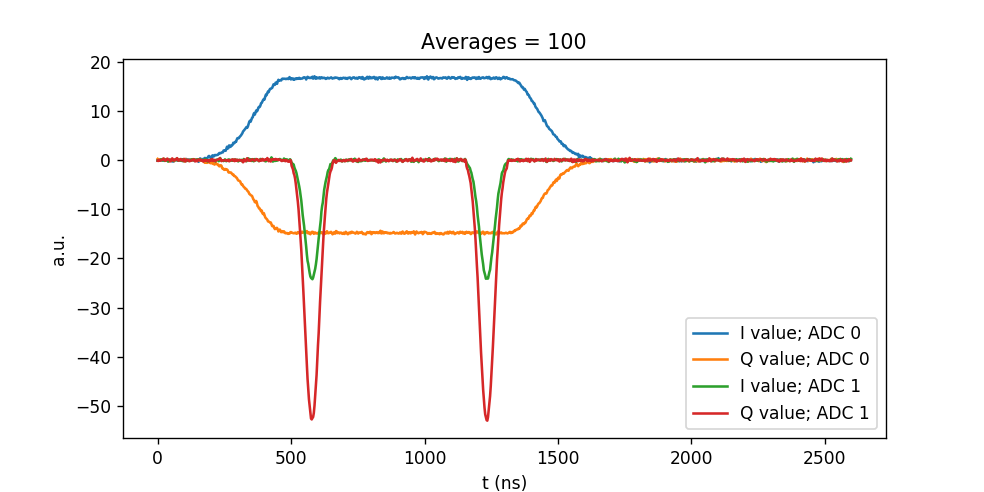

In [22]:
# Plot results.
plt.figure(figsize=(8,4))
t = np.linspace(0,999,1000)*2.6
plt.plot(t, iq0[0], label="I value; ADC 0")
plt.plot(t, iq0[1], label="Q value; ADC 0")
plt.plot(t, iq1[0], label="I value; ADC 1")
plt.plot(t, iq1[1], label="Q value; ADC 1")
plt.ylabel("a.u.")
plt.xlabel("t (ns)")
plt.title("Averages = " + str(config["soft_avgs"]))
plt.legend()
# plt.savefig("images_early/Send_recieve_pulse_Rabi_sqz_5.pdf", dpi=350)

# TUNEUP EXPERIMENT

In [207]:
class TuneupProgram(AveragerProgram):
    def initialize(self):
        cfg=self.cfg
        
        f_res=freq2reg(adcfreq(cfg["f_res"]))            # conver f_res to dac register value
        f_ge=freq2reg(cfg["f_ge"])
        f_sqz=freq2reg(cfg["f_squeezing"])

        cfg["adc_lengths"]=[cfg["readout_length"]]*2     # add length of adc acquisition to config
        cfg["adc_freqs"]=[adcfreq(cfg["f_res"])]*2       # add frequency of adc ddc to config
        
        # add pulses to respective channels
        self.add_pulse(ch=cfg["qubit_ch"], name="qubit_Rabi",style="flat_top", length=cfg["qubit_length"],
                       idata=gauss(mu=cfg["qubit_sigma"]*16*4/2,si=cfg["qubit_sigma"]*16,length=4*cfg["qubit_sigma"]*16,maxv=2**15-1))
        self.add_pulse(ch=self.cfg["qubit_ch"], name="qubit_pi2", style="arb", 
                       idata=gauss(mu=cfg["qubit_sigma"]*16*4/2,si=cfg["qubit_sigma"]*16, length=4*cfg["qubit_sigma"]*16, maxv=2**15-1))
        self.add_pulse(ch=cfg["res_ch"], name="measure",style="const", length=cfg["readout_length"])
        self.add_pulse(ch=cfg["squeezing_ch"], name="squeezing", style="flat_top", length=cfg["squeezing_length"], 
                       idata=gauss(mu=cfg["squeezing_sigma"]*16*4/2,si=cfg["squeezing_sigma"]*16,length=4*cfg["squeezing_sigma"]*16,maxv=2**15-1))               
        
        # pre-initialize pulses
        self.pulse(ch=cfg["qubit_ch"], name="qubit_pi2", phase=0, freq=f_ge, gain=cfg["pi2_gain"], play=False)
        self.pulse(ch=cfg["qubit_ch"], name="qubit_Rabi", phase=cfg["qubit_phase"], freq=f_ge, gain=cfg["qubit_gain"], play=False)
        self.pulse(ch=cfg["res_ch"], name="measure", freq=f_res, phase=cfg['res_phase'], gain=cfg["res_gain"], play=False)
        self.pulse(ch=cfg["squeezing_ch"], name="squeezing", phase=cfg['squeezing_phase'],
                   freq=f_sqz, gain=cfg["squeezing_gain"], play=False)
               
        self.synci(200)
        
    def body(self):
        cfg=self.cfg
        self.pulse(ch=cfg["qubit_ch"], name="qubit_pi2", play=True)                    # play pi/2 pulse
        self.sync_all(us2cycles(0.03))                                                 # wait 30 ns
        self.pulse(ch=cfg["squeezing_ch"], name="squeezing", play=True)                # play squeezing pulse
        self.wait_ch(ch=cfg["qubit_ch"], wait_t=cfg["squeezing2Rabi_wait"])            # wait before Rabi 
        self.pulse(ch=cfg["qubit_ch"], name="qubit_Rabi", play=True)                   # play Rabi pulse

        self.sync_all(us2cycles(0))
        self.trigger_adc(adc1=1, adc2=1, adc_trig_offset=self.cfg["adc_trig_offset"])  # trigger measurement
        self.pulse(ch=cfg["res_ch"], play=True)                                        # play measurement pulse
        self.sync_all(us2cycles(self.cfg["relax_delay"]))                              # wait for qubit to relax

In [208]:
adc_offset = 230
cavity_RF = 11.0472e9 
cavity_LO = 12.1e9
cavity_IF = (cavity_LO-cavity_RF)/1e6
cavity_atten = 5

qubit_LO = 3.76615e9               # Hz
qubit_IF = 700                     # MHz
qubit_RF = qubit_LO/1e6 - qubit_IF # MHz
qubit_atten = 0

squeezing_RF = 2*qubit_RF
squeezing_LO = qubit_LO # use the same LO for phase coherence
squeezing_IF = squeezing_RF - squeezing_LO/1e6
squeezing_atten = 0

setatten(atten=qubit_atten, serial=qubit_SN) # Qubit
setatten(atten=cavity_atten, serial=cavity_SN) # Cavity
setatten(atten=squeezing_atten, serial=squeezing_SN) # Squeezing
setsignalcore(module=cavity_LOmod,output=1,power=13,freq=cavity_LO) # Cavity LO = 12.1 GHz fixed
setsignalcore(module=qubit_LOmod,output=1,power=7,freq=qubit_LO) # Qubit LO is varied

Microsoft Windows [Version 10.0.19042.1415]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 0 27783
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device 1 Serial number: 27783
Device was found to be device 1
Get attenuation: 0.0
Set attenuation: 0.0
Device 2 Serial number: 27712
Device 3 Serial number: 0
Device 4 Serial number: 0

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>Microsoft Windows [Version 10.0.19042.1415]
(c) Microsoft Corporation. All rights reserved.

escher@ESCHER-PC C:\Users\escher>cd Documents\GitHub\pythonsandbox\PythonDrivers

escher@ESCHER-PC C:\Users\escher\Documents\GitHub\pythonsandbox\PythonDrivers>python control_atten.py 5 27782
Setting attenuation
3  device(s) found
Device 0 Serial number: 27782
Device was found to be devi

In [226]:
hw_cfg={"res_ch":cavity_ch, "qubit_ch":qubit_ch, "squeezing_ch":squeezing_ch,}
atten_cfg={"cavity_atten": cavity_atten, "qubit_atten": qubit_atten, "squeezing_atten": squeezing_atten,}
expt_cfg={"start":4, "step":3, "expts":120, "reps": 3000}
expt_pts=[expt_cfg["start"] + ii*expt_cfg["step"] for ii in range(expt_cfg["expts"])]

squeezing2Rabi_wait =  us2cycles(0.02)                                           # from finishing ramping up squeezing to starting Rabi
squeezing_sigma =  us2cycles(0.16)                                               # 2sigma should be >> 1/2K
qubit_length = us2cycles(0.1)                                                    # dummy value, to be varied in the loop
qubit_sigma = us2cycles(0.04)   #0.04                                            # 80 ns ramp in Grimm
squeezing_length = squeezing2Rabi_wait + qubit_length + 4*qubit_sigma            # sqz is longer than qubit bc it starts before qubit
res_wait = squeezing_length + 4*squeezing_sigma

readout_cfg={
    "res_wait": res_wait,
    "readout_length": us2cycles(4.6),
    "res_phase": 0,
    "res_gain": 32000,
    "cavity_RF": cavity_RF/1e6, # just for displaying
    "f_res": cavity_IF, # [MHz], played by ADC
    "adc_trig_offset": adc_offset,
    "threshold": np.int(threshold),
    }
qubit_cfg={
    "qubit_sigma": qubit_sigma,
    "qubit_length": qubit_length,
    "qubit_phase": deg2reg(45),
    "qubit_gain": 16000,
    "pi_gain": np.int(pi_gain), "pi2_gain":np.int(pi_gain/2),
    "qubit_RF": qubit_RF, # just for displaying
    "f_ge": qubit_IF, # [MHz], played by ADC
    "relax_delay":75,
    }
sqz_cfg={
    "squeezing_sigma": squeezing_sigma,
    "squeezing2Rabi_wait": 2*squeezing_sigma + squeezing2Rabi_wait,
    "squeezing_length": squeezing_length,  
    "squeezing_phase": deg2reg(90),
    "squeezing_gain": 32000,
    "squeezing_RF": squeezing_RF, # just for displaying
    "f_squeezing": squeezing_IF, # [MHz], played by ADC
    }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg, **sqz_cfg, **atten_cfg} # combine configs
config

{'adc_trig_offset': 230,
 'cavity_RF': 11047.2,
 'cavity_atten': 5,
 'expts': 120,
 'f_ge': 700,
 'f_res': 1052.8,
 'f_squeezing': 2366.15,
 'pi2_gain': 3140,
 'pi_gain': 6280,
 'qubit_RF': 3066.15,
 'qubit_atten': 0,
 'qubit_ch': 6,
 'qubit_gain': 16000,
 'qubit_length': 38,
 'qubit_phase': 536870912,
 'qubit_sigma': 15,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 3000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'res_wait': 349,
 'squeezing2Rabi_wait': 129,
 'squeezing_RF': 6132.3,
 'squeezing_atten': 0,
 'squeezing_ch': 5,
 'squeezing_gain': 32000,
 'squeezing_length': 105,
 'squeezing_phase': 1073741824,
 'squeezing_sigma': 61,
 'start': 4,
 'step': 3,
 'threshold': -14}

In [227]:
# single Rabi length
results=[]
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")
for length in tqdm(expt_pts): # already in cycles
    qubit_length=length
    squeezing_length = qubit_length + squeezing2Rabi_wait + 4*qubit_sigma
    res_wait = squeezing_length + 4*squeezing_sigma
    config["res_wait"] = res_wait
    config["qubit_length"] = qubit_length
    config["squeezing_length"] = squeezing_length

    tuneup = TuneupProgram(config)
    avgi,avgq = tuneup.acquire(soc, threshold=None, load_pulses=True, progress=False,debug=False)
    results.append(avgi[0][0])

100%|██████████| 120/120 [01:08<00:00,  1.74it/s]


Omega_x = 5.08 MHz


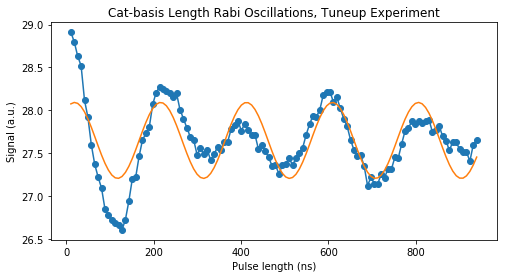

In [228]:
fig, ax = plt.subplots(figsize=(8,4))
ax.set_title("Cat-basis Length Rabi Oscillations, Tuneup Experiment")
ax.set_xlabel("Pulse length (ns)")
ax.set_ylabel("Signal (a.u.)")
x_pts = cycles2us(np.array(expt_pts))*1000
y_pts = np.array(results)
ax.plot(x_pts, y_pts, 'o-');

def sinRabi(x, a, T, phi, c):
    return a*np.sin(2*np.pi/T*x + phi) + c

guess = (1.2, 200, 0, 5.5)
popt,pcov = curve_fit(sinRabi, x_pts, y_pts, p0=guess)
ax.plot(x_pts, sinRabi(x_pts, *popt))
print("Omega_x = %.2f MHz" % (1/popt[1]*1e3))

dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_halfFlux_thruCL/'
x_pts.tofile(dataFolder + 'tuneup_sqz32k_qphase45_sqzphase90_x_'+ dt_string + '.csv', sep=',', format='%10.3f')
y_pts.tofile(dataFolder + 'tuneup_sqz32k_qphase45_sqzphase90_y_'+ dt_string + '.csv', sep=',', format='%10.3f')
plt.savefig(dataFolder + 'tuneup_sqz32k_qphase45_sqzphase90_'   + dt_string + '.pdf', dpi=350)

### loop through phases

In [229]:
hw_cfg={"res_ch":cavity_ch, "qubit_ch":qubit_ch, "squeezing_ch":squeezing_ch,}
atten_cfg={"cavity_atten": cavity_atten, "qubit_atten": qubit_atten, "squeezing_atten": squeezing_atten,}

expt_cfg={"start":4, "step":3, "expts":120, "reps": 3000}
expt_pts=[expt_cfg["start"] + ii*expt_cfg["step"] for ii in range(expt_cfg["expts"])]

phase_expt_cfg={"phase_start":deg2reg(0), "phase_step":deg2reg(3), "phase_expts":61}
phase_expt_pts=[phase_expt_cfg["phase_start"] + ii*phase_expt_cfg["phase_step"] for ii in range(phase_expt_cfg["phase_expts"])]

squeezing2Rabi_wait = us2cycles(0.02)                                           # from finishing ramping up squeezing to starting Rabi
squeezing_sigma = us2cycles(0.16)                                               # 2sigma should be >> 1/2K
qubit_length = us2cycles(0.1)                                                   # dummy value, to be varied in the loop
qubit_sigma = us2cycles(0.04)                                                   # 80 ns ramp in Grimm
squeezing_length = qubit_length + squeezing2Rabi_wait + 4*qubit_sigma           # sqz is longer than qubit bc it starts before qubit
res_wait = squeezing_length + 4*squeezing_sigma

readout_cfg={
    "res_wait": res_wait,
    "readout_length": us2cycles(4.6),
    "res_phase": 0,
    "res_gain": 32000,
    "cavity_RF": cavity_RF/1e6, # just for displaying
    "f_res": cavity_IF, # [MHz], played by ADC
    "adc_trig_offset": adc_offset,
    "threshold": np.int(threshold),
    }
qubit_cfg={
    "qubit_sigma": qubit_sigma,
    "qubit_length": qubit_length,
    "qubit_phase": 0,
    "pi_gain": np.int(pi_gain), "pi2_gain":np.int(pi_gain/2),
    "qubit_gain": 16000,
    "qubit_RF": qubit_RF, # just for displaying
    "f_ge": qubit_IF, # [MHz], played by ADC
    "relax_delay":75,
    }
sqz_cfg={
    "squeezing_sigma": squeezing_sigma,
    "squeezing2Rabi_wait": 2*squeezing_sigma + squeezing2Rabi_wait,
    "squeezing_length": squeezing_length,  
    "squeezing_phase": deg2reg(0),
    "squeezing_gain": 32000,
    "squeezing_RF": squeezing_RF, # just for displaying
    "f_squeezing": squeezing_IF, # [MHz], played by ADC
    }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg, **sqz_cfg, **atten_cfg, **phase_expt_cfg} # combine configs
config

{'adc_trig_offset': 230,
 'cavity_RF': 11047.2,
 'cavity_atten': 5,
 'expts': 120,
 'f_ge': 700,
 'f_res': 1052.8,
 'f_squeezing': 2366.15,
 'phase_expts': 61,
 'phase_start': 0,
 'phase_step': 35791394,
 'pi2_gain': 3140,
 'pi_gain': 6280,
 'qubit_RF': 3066.15,
 'qubit_atten': 0,
 'qubit_ch': 6,
 'qubit_gain': 16000,
 'qubit_length': 38,
 'qubit_phase': 0,
 'qubit_sigma': 15,
 'readout_length': 1766,
 'relax_delay': 75,
 'reps': 3000,
 'res_ch': 7,
 'res_gain': 32000,
 'res_phase': 0,
 'res_wait': 349,
 'squeezing2Rabi_wait': 129,
 'squeezing_RF': 6132.3,
 'squeezing_atten': 0,
 'squeezing_ch': 5,
 'squeezing_gain': 32000,
 'squeezing_length': 105,
 'squeezing_phase': 0,
 'squeezing_sigma': 61,
 'start': 4,
 'step': 3,
 'threshold': -14}

In [230]:
# loop through phases. CHECK TO SEE IF IT'S QUBIT PHASE OR SQUEEZING PHASE IN THE LOOP
# keep sqz phase = 2* qubit phase
results = np.zeros((len(phase_expt_pts), len(expt_pts)))

for jjj, squeezing_phase in enumerate(phase_expt_pts):
    config["squeezing_phase"] = squeezing_phase
    config["qubit_phase"] = np.int(squeezing_phase/2)
    
    for iii, length in enumerate(expt_pts): # already in cycles
        qubit_length=length
        squeezing_length = qubit_length + squeezing2Rabi_wait + 4*qubit_sigma
        res_wait = squeezing_length + 4*squeezing_sigma
        config["res_wait"] = res_wait
        config["qubit_length"] = qubit_length
        config["squeezing_length"] = squeezing_length

        catChevron = CatChevronProgram(config)
        avgi,avgq = catChevron.acquire(soc, threshold=None, load_pulses=True, progress=False,debug=False)
        results[jjj][iii]=avgi[0][0]
        
now = datetime.now(); dt_string = now.strftime("%Y_%m_%d_%H_%M_%S")

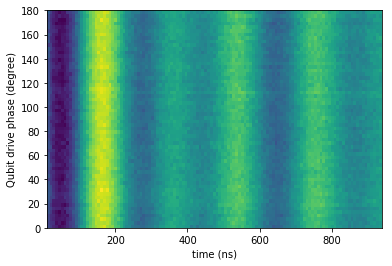

In [231]:
phase_deg = np.zeros(len(phase_expt_pts))
for i in range(len(phase_expt_pts)):
    phase_deg[i] = reg2deg(phase_expt_pts[i])
times = cycles2us(np.array(expt_pts))*1000

fig, ax = plt.subplots(figsize=(6,4))
ax.pcolormesh(times, phase_deg, results)
ax.set_xlabel("time (ns)")
ax.set_ylabel("Qubit drive phase (degree)")

dataFolder = '/home/xilinx/jupyter_notebooks/KerrCat/qick_demos/TAFC1_B3_halfFlux_thruCL/'
plt.savefig(dataFolder + "tuneup_sweepSqzPhase2QubitPhase_" + dt_string + ".pdf", dpi=350)
phase_deg.tofile(dataFolder + 'tuneup_sweepSqzPhase2QubitPhase_phase_' + dt_string + '.csv', sep=',', format='%10.3f')
times.tofile(dataFolder + 'tuneup_sweepSqzPhase2QubitPhase_time_' + dt_string + '.csv', sep=',', format='%10.3f')
results.tofile(dataFolder + 'tuneup_sweepSqzPhase2QubitPhase_results_' + dt_string + '.csv', sep=',', format='%10.3f')